In [1]:
from astroquery.sdss import SDSS

# SQL query to retrieve stellar data
# Select identifiers, field location, physical labels, and SNR in the allStar catalog
# Apply conditions to filter out missing data, low SNR, dwarf stars, and low metallicity
# I used the IN operator to limit the results to the four specified fields
# The != -9999 argument filters out the APOGEE filler value to ensure only valid labels are kept
# I had to separately query %060+00 since the % sign was messing up the query, making me unable to access the data set!
query = """
SELECT TOP 3000
    s.apogee_id, s.field, s.telescope, s.snr, a.teff, a.logg, a.fe_h, a.mg_fe, a.si_fe 
FROM 
    apogeeStar s
JOIN 
    aspcapStar a ON s.apstar_id = a.apstar_id
WHERE 
    (s.field IN ('M15', 'N6791', 'K2_C4_168-21') OR s.field LIKE '%060+00')
    AND a.teff != -9999 
    AND a.logg != -9999 
    AND a.fe_h != -9999 
    AND a.mg_fe != -9999 
    AND a.si_fe != -9999 
    AND s.snr >= 50 
    AND a.logg <= 4 
    AND a.teff <= 5700 
    AND a.fe_h >= -1
"""

# Execute the query and convert to a pandas DataFrame.
data = SDSS.query_sql(query, data_release=17, cache=False)
df = data.to_pandas()

# Display the number of rows retrieved
print(f"stars retrieved: {len(data)}")

stars retrieved: 1886


### log(g) Cut


   The nomenclature of the lab is a bit confusing, because technically all dwarf stars are also main sequence stars. The log(g) cut helps remove most main sequence/dwarf stars with the exception of some O-type and B-type stars. The equation for surface gravity is proportional to stellar mass divided by radius squared (GM/R^2). Dwarf stars have smaller radii, and since the radius term dominates, they have higher surface gravity. Giant stars have radii that are disproportionate compared to their mass (relative to dwarf stars). This causes their measured surface gravity to plummet. A priori, a log(g) < 4 cut helps to remove stars with high surface gravity, i.e. dwarf stars.

In [2]:
import math

def calculate_logg(mass_solar, radius_solar):
    """
    Calculates the log (base 10) of stellar surface gravity.
    Accepts mass and radius in solar units and performs calculations in cgs units.
    """
    g = 6.6743e-8
    m_sun = 1.9884e33    
    r_sun = 6.957e10
    mass_g = mass_solar * m_sun
    radius_cm = radius_solar * r_sun
    
    # Calculate surface gravity using the formula g = GM/R^2.
    surface_gravity = (g * mass_g) / (radius_cm ** 2)
    
    # Calculate the base-10 logarithm of the surface gravity.
    logg = math.log10(surface_gravity)
    
    return logg

# Determines the log(g) value on the main sequence.
main_sequence_logg = calculate_logg(1.0, 1.0)

# Determines the log(g) value just before the helium flash.
helium_flash_logg = calculate_logg(1.0, 100.0)

# Determines the log(g) value during core helium burning.
core_burning_logg = calculate_logg(1.0, 15.0)

o_type_logg = calculate_logg(25.0, 11.0)

print(f"Main Sequence log(g): {main_sequence_logg:.2f}")
print(f"Helium Flash log(g): {helium_flash_logg:.2f}")
print(f"Core Helium Burning log(g): {core_burning_logg:.2f}")
print(f"O-type Main sequence log(g): {o_type_logg: .2f}")

Main Sequence log(g): 4.44
Helium Flash log(g): 0.44
Core Helium Burning log(g): 2.09
O-type Main sequence log(g):  3.75


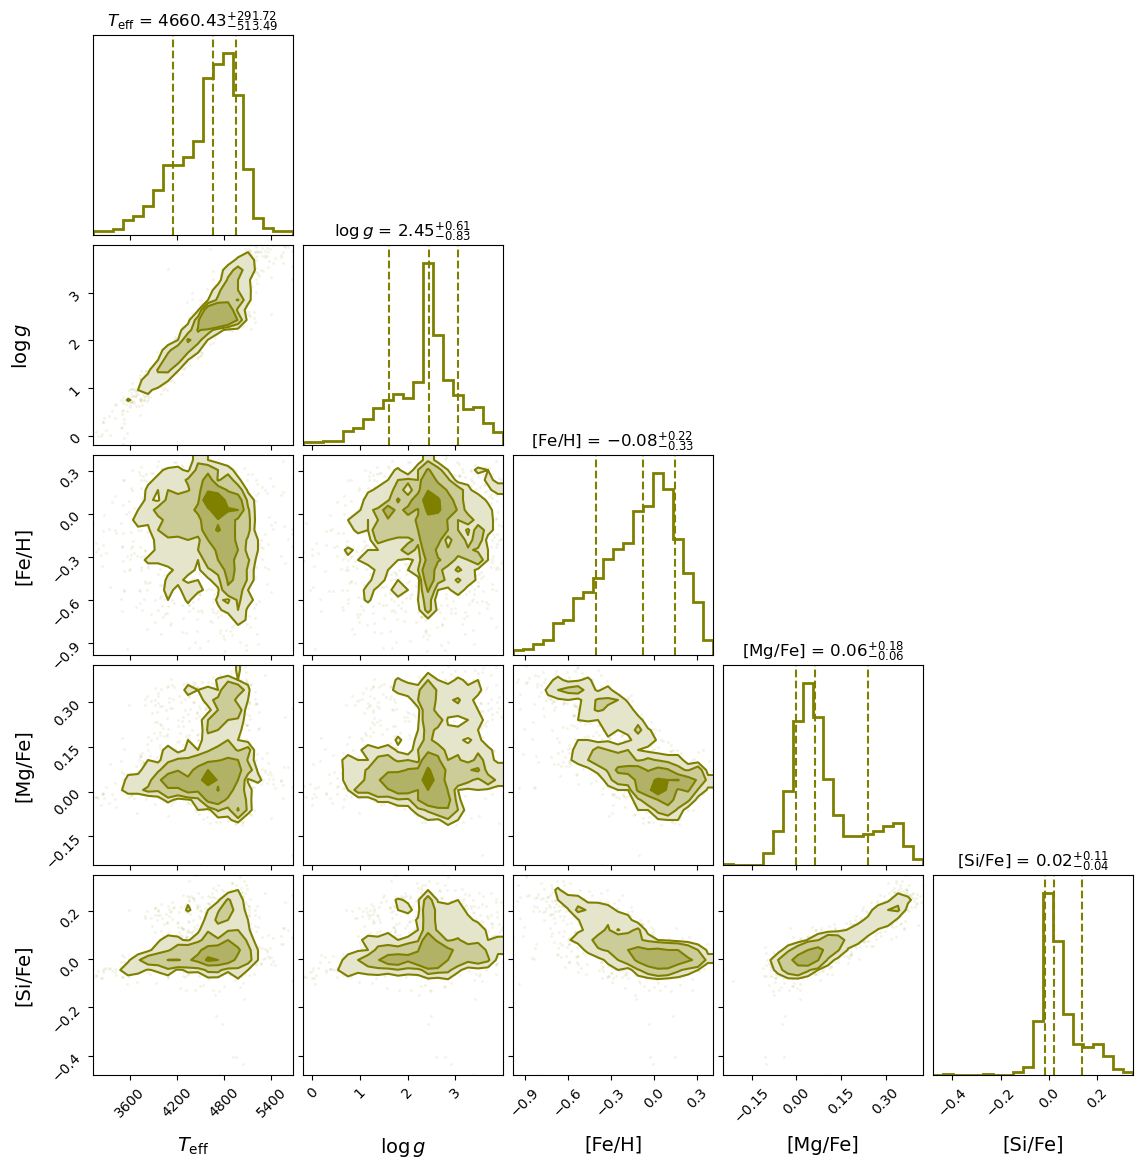

In [4]:
import numpy as np
import corner
import matplotlib.pyplot as plt

#Bug fix for corner & numpy
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

# Extract the specific columns containing the five required stellar labels and convert the data subset directly into a pandas df
labels_df = data[['teff', 'logg', 'fe_h', 'mg_fe', 'si_fe']].to_pandas()

# Convert the df to a NumPy array.
# Required because the corner library expects a standard N-dimensional array as input.
labels_array = np.array(labels_df)

# Using latex to make the formatting pretty
plot_labels = [r"$T_{\text{eff}}$", r"$\log g$", r"[Fe/H]", r"[Mg/Fe]", r"[Si/Fe]"]

# Generate the corner plot using the converted array and corresponding labels.
# The 'quantiles' parameter draws vertical lines on the histograms at the 16th, 50th, and 84th percentiles.
# The 'plot_contours' parameter draws density rings on the 2D scatter plots to highlight concentrated data.
figure = corner.corner(
    labels_array, 
    labels=plot_labels, 
    show_titles=True, 
    title_kwargs={"fontsize": 12}, 
    label_kwargs={"fontsize": 14}, 
    quantiles=[0.16, 0.5, 0.84], 
    plot_contours=True,
    fill_contours=True,
    color="olive",
    hist_kwargs={"linewidth": 2}
)

# Save the generated figure locally to a file so that I can get it high res
figure.savefig("stellar_labels_corner_plot.png", dpi=300)

plt.show()

### Doppler Shifts & the Barycentric frame

When measuring a star's spectrum the Earth's orbit around the sun can cause inconsistencies in the observation. Our planet moves ~30km/s around the sun, which means that we observe a doppler shift upon making observations (blue shifting if we are moving toward the star, and red shifting if we're moving away). This effect causes a shifted spectra, however, we can fix this by accounting for the earth's motion when making an observation. If we set the barycenter of the solar system (basically the sun) to be the point of observation, we remove the doppler shifting from the earth. There is still some noise, because the sun and the observed star are still moving through space, however the results are still more accurate. 

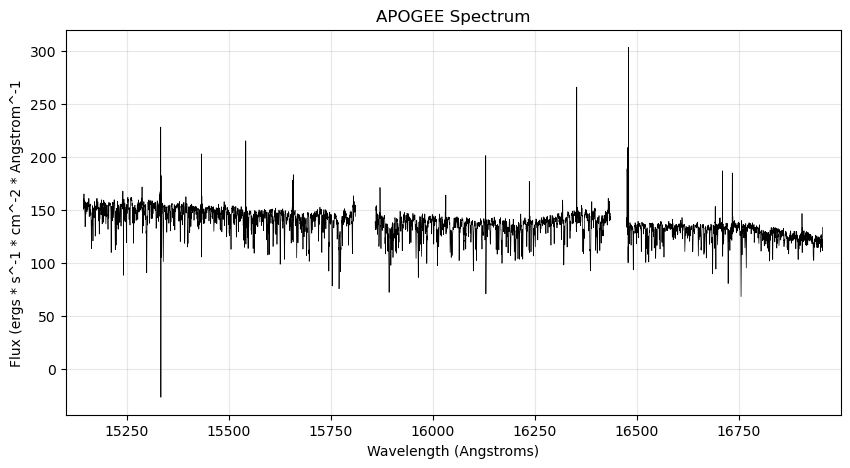

In [5]:
import os
import urllib.request
from astropy.io import fits

# Extract the first row of the queried dataset to test a real star. this helps check that the requested file exists on the SDSS server.
test_star = df.iloc[0]

# Isolate the routing variables required to build the download URL.
# Decodes byte strings if astroquery returned them in a binary format.
apogee_id = test_star['apogee_id'].decode('utf-8') if isinstance(test_star['apogee_id'], bytes) else test_star['apogee_id']
field = test_star['field'].decode('utf-8') if isinstance(test_star['field'], bytes) else test_star['field']
telescope = test_star['telescope'].decode('utf-8') if isinstance(test_star['telescope'], bytes) else test_star['telescope']

# Determine the correct file prefix based on the telescope.
# Southern hemisphere observations (lco25m) use 'asStar' while Northern use 'apStar'.
file_prefix = "asStar" if telescope == "lco25m" else "apStar"

# Construct the SDSS Data Release 17 download URL
# Inserts the real variables into the exact directory structure required by the SAS.
url = f"https://data.sdss.org/sas/dr17/apogee/spectro/redux/dr17/stars/{telescope}/{field}/{file_prefix}-dr17-{apogee_id}.fits"
file_name = f"{file_prefix}-dr17-{apogee_id}.fits"

# Download the FITS file if it is absent locally toi prevent redownloading the same massive file during multiple script runs.
if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)

# Open the downloaded FITS file to access the data and headers.
with fits.open(file_name) as hdul:
    header = hdul[1].header
    flux = hdul[1].data[0] 

# Extract scaling constants from the header. (The constants are in log space)
# tgis identifies the grid parameters necessary to map the spectrum
crval1 = header['CRVAL1']
cdelt1 = header['CDELT1']
naxis1 = header['NAXIS1']

# generate an array of pixel indices.
pixel_indices = np.arange(naxis1)

# Calculate the wavelength array via exponential transformation.
# Reverses the base-10 logarithmic scaling to yield standard Angstroms.
wavelengths = 10 ** (crval1 + cdelt1 * pixel_indices)

# spectrum plot
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, flux, color='black', linewidth=0.5)
plt.title(f"APOGEE Spectrum")
plt.xlabel(r"Wavelength (Angstroms)")
plt.ylabel(r"Flux (ergs * s^-1 * cm^-2 * Angstrom^-1")
plt.xlim(wavelengths[0], wavelengths[-1])
plt.grid(True, alpha=0.3)
plt.show()

### Flux vs Wavelength & Units

   * Wavelength is a property of the light that is being measured. It describes the color of the light, and as a result the energy that it carries as well.

   * Flux is a measurement of how much light is produced by the source, per second, through an area, at a specific wavelength. It's a mouthful but its a very useful quantity to measure. Since we know how much energy a specific wavelength of light has intrinsically, we can measure the energy output of the star! This is because flux measures all the light being outputted at that specific wavelength. The area quantity is inversely proportional to the flux, and as a result you will measure a lower value of flux the farther you are from the star upon observing it.

   * The units of flux are ergs per second per cm^2 per Angstrom. What this means is that flux is basically a measurement of the density of energy output. The units of flux are saying: "At a specific wavelength (Angstrom), how much energy per second (erg/s) is being passed through a surface (cm^2)?".

In [6]:
 def clean_spectrum(file_name):

    # Open FITS file
    with fits.open(file_name) as hdul:
        flux = hdul[1].data[0] # extract flux array.
        error = hdul[2].data[0] # Extract error array.
        bitmask = hdul[3].data[0]# extract the bitmask array.

    bits_0_to_7 = 255 # since im filtering for bits 0-7 i set the bit value to 255 (8 1's in binary)

    # integer value for bit 12
    # Uses a bitwise left-shift to calculate 2^12.
    bit_12 = 1 << 12

    

    # Combine the targeted bits using a bitwise OR operator.
    # Creates a single integer that I can use to filter through the bits

    critical_flags = bits_0_to_7 | bit_12

    

    # AND operator to see if a pixel has a corresponding flag
    bad_pixels_index = (bitmask & critical_flags) != 0

    

    # Inflate the uncertainty of the flagged pixels
    # Assigning a massive error value so the pixels weight will be basically zero when we use it

    error[bad_pixels_index] = 1e10

    return flux, error



clean_flux, clean_error = clean_spectrum(file_name)


print(f"Total pixels: {len(clean_flux)}")

print(f"Pixels filtered out: {np.sum(clean_error == 1e10)}") 

Total pixels: 8575
Pixels filtered out: 133


### Psudo Continuum vs True Continuum

When we speak of a continuum we are referring to a star's Flux vs Wavelength plot. How much energy is it outputting at a particular wavelength. A star's "true continuum" is characterized by its blackbody curve. It's the curve we would expect to see in a theoretical setting where the star is a perfect blackbody with no observational noise or interference. This is NOT AT ALL what we see when we observe stars, especially giant stars which have very complex atmospheres. A large source of noise happens because the elements in the atmosphere absorb a lot of the light emitted by the star, and re-emit it at lower wavelengths. This dampens the observed flux at particular wavelengths giving us inaccurate measurements. In order to reconcile with this, we construct "Pseudo continuums" to approximate the stars actual lightcurve. The process is as follows: some wavelenghts have very low absorption and are almost true to what we'd expect to observe. We use these data points to generate a polynomial fit of the lightcurve. We can then use this pseudo lightcurve to normalize the flux by dividing the raw flux data by the pseudo continuum. Places with good data (training points) should become equal to 1 since you're essentially dividing the data point by itself. Wavelenghts with high absorption will become < 1. This creates the absorption lines for the atmosphere of the star!!!! Super cool stuff

In [7]:
def plot_normalization(wavelengths, raw_flux, continuum_line, norm_flux, target_id):

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # raw flux plot
    ax1.plot(wavelengths, raw_flux, color='olive', linewidth=0.5, label='Observed Spectrum')
    
    # pseudo-continuum overlayed
    ax1.plot(wavelengths, continuum_line, color='red', linewidth=1.5, label='Pseudo-Continuum Fit')

    ax1.set_ylabel(r"Flux")
    ax1.set_title(f"Continuum Normalization")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # normalized flux 
    ax2.plot(wavelengths, norm_flux, color='blue', linewidth=0.5, label='Normalized Spectrum')
    
    ax2.axhline(1.0, color='red', linestyle='dashdot', linewidth=1.0)
    
    # Configure labels and limits for the bottom subplot.
    ax2.set_xlabel(r"Wavelength")
    ax2.set_ylabel("Normalized Flux")
    ax2.set_ylim(0.0, 1.2)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Adjust spacing and save the figure.
    plt.tight_layout()
    plt.savefig(f"{target_id}_normalization.png", dpi=300)
    plt.show()



#  Load the continuum pixel mask.
mask_archive = np.load("continuum_wavelengths.npz")
raw_mask = mask_archive[mask_archive.files[0]]

# Format the mask correctly depending on its length.
if len(raw_mask) == 8575:
    continuum_mask_formatted = raw_mask.astype(bool)
else:
    index_list = raw_mask.astype(int)
    continuum_mask_formatted = np.zeros(8575, dtype=bool)
    continuum_mask_formatted[index_list] = True

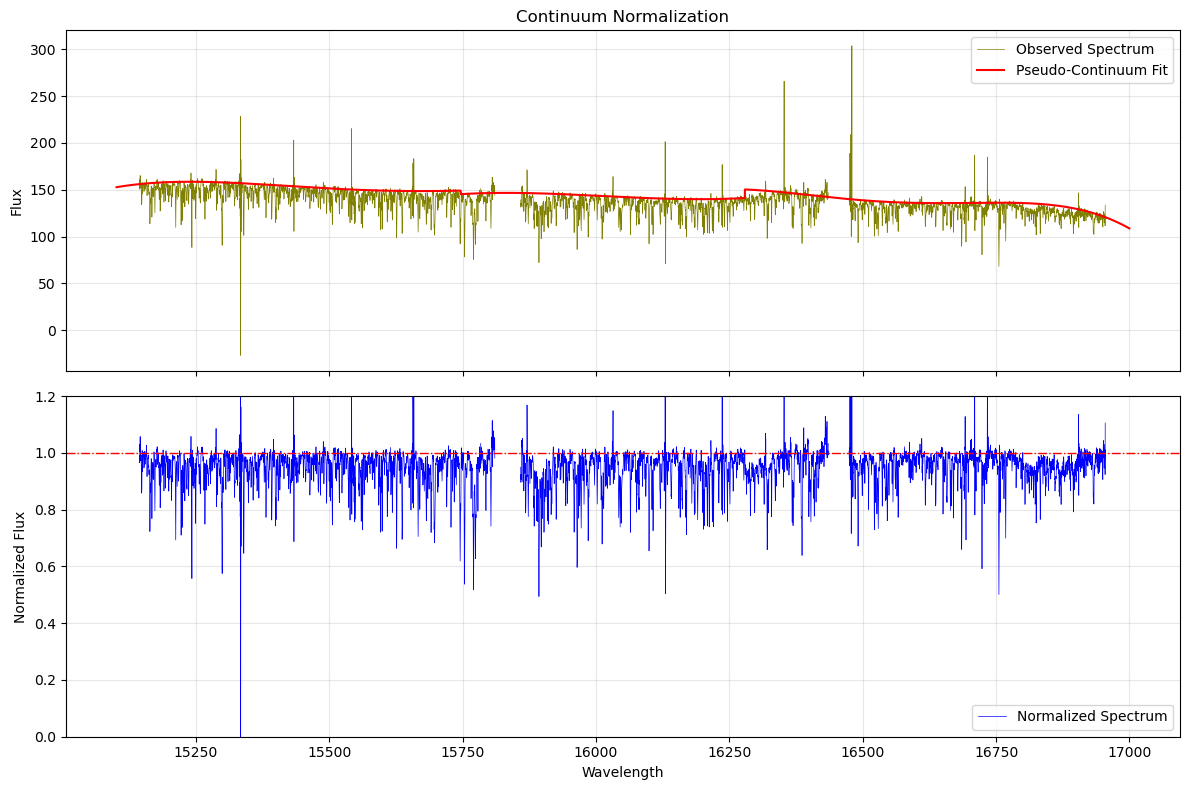

In [8]:
from numpy.polynomial import Chebyshev

def normalize_spectrum(wavelengths, flux, error, continuum_mask,
                       deg=4, n_iter=5, sigma_lower=0.5, sigma_upper=3.0):
    """
    Pseudo-continuum normalize an APOGEE spectrum chip-by-chip using an iterative
    Chebyshev polynomial fit to the continuum pixels (Ness et al. 2015, Sec. 2.3).

    Parameters
    ----------
    wavelengths    : (N,) wavelength array in Angstroms
    flux           : (N,) raw flux array
    error          : (N,) error array (bad pixels already inflated to 1e10)
    continuum_mask : (N,) boolean array; True = continuum pixel
    deg            : degree of Chebyshev polynomial per chip (6 is a good default)
    n_iter         : number of sigma-clipping iterations
    sigma_lower    : clip pixels this many sigma BELOW the fit (catches absorption dips)
    sigma_upper    : clip pixels this many sigma ABOVE the fit (catches cosmic rays)
    """

    chip_boundaries = [(0, 3028), (3028, 5438), (5438, 8575)]

    continuum_array  = np.zeros(len(flux),  dtype=float)
    normalized_flux  = np.zeros(len(flux),  dtype=float)
    normalized_error = np.zeros(len(error), dtype=float)

    for start, end in chip_boundaries:
        wave_chip  = wavelengths[start:end]
        flux_chip  = flux[start:end]
        error_chip = error[start:end]
        mask_chip  = continuum_mask[start:end]

        # --- Select valid seed pixels: in the continuum mask, finite, not flagged ---
        valid = (mask_chip
                 & np.isfinite(flux_chip)
                 & (error_chip < 1e9)
                 & (flux_chip > 0))

        # Fallback if the mask yields too few points (shouldn't normally happen)
        if valid.sum() < deg + 2:
            valid = np.isfinite(flux_chip) & (error_chip < 1e9) & (flux_chip > 0)

        wave_fit  = wave_chip[valid]
        flux_fit  = flux_chip[valid]
        error_fit = error_chip[valid]

        # Inverse-variance weights: downweight noisier pixels in the fit
        weights = 1.0 / np.clip(error_fit, 1e-10, None)

        # --- Iterative sigma-clipping loop ---
        # Each iteration rejects pixels that fall too far below the current fit
        # (i.e. pixels with residual absorption) so they don't bias the continuum
        # estimate downward. This is the core idea from Ness et al. 2015 Sec. 2.3.
        keep = np.ones(len(wave_fit), dtype=bool)

        for iteration in range(n_iter):
            if keep.sum() < deg + 2:
                keep = np.ones(len(wave_fit), dtype=bool)  # safety reset
                break

            poly = Chebyshev.fit(wave_fit[keep], flux_fit[keep],
                                 deg=deg, w=weights[keep])
            residuals = flux_fit[keep] - poly(wave_fit[keep])
            rms = np.std(residuals)

            # Identify which of the currently-kept pixels to reject
            reject = (residuals < -sigma_lower * rms) | (residuals > sigma_upper * rms)
            kept_indices = np.where(keep)[0]
            keep[kept_indices[reject]] = False

        # --- Final fit on the cleaned set of continuum pixels ---
        poly_final = Chebyshev.fit(wave_fit[keep], flux_fit[keep],
                                   deg=deg, w=weights[keep])

        continuum_chip = poly_final(wave_chip)

        # Guard against near-zero or negative continuum values (prevents blow-up at edges)
        median_cont = np.median(continuum_chip[continuum_chip > 0]) if (continuum_chip > 0).any() else 1.0
        continuum_chip = np.where(continuum_chip > 0.01 * median_cont,
                                  continuum_chip, median_cont)

        continuum_array[start:end]  = continuum_chip
        normalized_flux[start:end]  = flux_chip  / continuum_chip
        normalized_error[start:end] = error_chip / continuum_chip

    return normalized_flux, normalized_error, continuum_array


# --- Run and plot (same calls as before) ---
final_normalized_flux, final_normalized_error, final_continuum = normalize_spectrum(
    wavelengths,
    clean_flux,
    clean_error,
    continuum_mask_formatted
)

plot_normalization(
    wavelengths,
    clean_flux,
    final_continuum,
    final_normalized_flux,
    "2M21235315+1244123"
)

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split


REQUIRED_TRAIN_IDS = [
    "2M03533659+2512012",   # making sure this star is in my training set for part 7
]

def decode_id(x):
    """normalize apogee_id regardless of whether it is bytes or str."""
    return x.decode('utf-8') if isinstance(x, bytes) else x

# Build a boolean mask for every required star
required_mask = df['apogee_id'].apply(decode_id).isin(REQUIRED_TRAIN_IDS)

missing = set(REQUIRED_TRAIN_IDS) - set(df['apogee_id'].apply(decode_id)[required_mask])
if missing:
    print(f"WARNING: these required stars were not found in the catalog "
          f"(failed quality cuts?): {missing}")

# Partition: guaranteed training stars vs the remainder to be split
required_df  = df[required_mask].reset_index(drop=True)
remainder_df = df[~required_mask].reset_index(drop=True)

# 50/50 split of the remainder only
train_remainder, val_df = train_test_split(
    remainder_df, test_size=0.5, random_state=89
)

# Combine required stars with the random training half
train_df = pd.concat([required_df, train_remainder], ignore_index=True)
val_df   = val_df.reset_index(drop=True)

print(f"Original dataset size : {len(df)}")
print(f"Required stars pinned : {required_mask.sum()}")
print(f"Training set size     : {len(train_df)}")
print(f"Cross-validation size : {len(val_df)}")

# Verify the required stars are present
found = train_df['apogee_id'].apply(decode_id).isin(REQUIRED_TRAIN_IDS)
print(f"\nRequired stars confirmed in train_df: {found.sum()} / {len(REQUIRED_TRAIN_IDS)}")

Original dataset size : 1886
Required stars pinned : 1
Training set size     : 943
Cross-validation size : 943

Required stars confirmed in train_df: 1 / 1


In [10]:
import urllib.request
from astropy.io import fits
from tqdm.notebook import tqdm  

SPECTRA_DIR = "apStar_cache"
os.makedirs(SPECTRA_DIR, exist_ok=True)

def get_fits_path(row):
    """Return (url, local_path) for a catalog row."""
    apogee_id = row['apogee_id'].decode('utf-8') if isinstance(row['apogee_id'], bytes) else row['apogee_id']
    field     = row['field'].decode('utf-8')     if isinstance(row['field'],     bytes) else row['field']
    telescope = row['telescope'].decode('utf-8') if isinstance(row['telescope'], bytes) else row['telescope']
    prefix    = "asStar" if telescope == "lco25m" else "apStar"
    url  = (f"https://data.sdss.org/sas/dr17/apogee/spectro/redux/dr17/stars/"
            f"{telescope}/{field}/{prefix}-dr17-{apogee_id}.fits")
    path = os.path.join(SPECTRA_DIR, f"{prefix}-dr17-{apogee_id}.fits")
    return url, path

def load_spectra_set(star_df, wavelengths, continuum_mask, desc="Loading"):
    """
    Download (if absent), clean, and pseudo-continuum normalize every star
    in star_df.  Returns:
        norm_flux   : (N, N_pix)  float32
        norm_error  : (N, N_pix)  float32
        valid       : (N,)        bool  – False if download or normalisation failed
    """
    N     = len(star_df)
    N_pix = len(wavelengths)
    norm_flux  = np.zeros((N, N_pix), dtype=np.float32)
    norm_error = np.zeros((N, N_pix), dtype=np.float32)
    valid      = np.zeros(N, dtype=bool)

    for i, (_, row) in enumerate(tqdm(star_df.iterrows(), total=N, desc=desc)):
        url, path = get_fits_path(row)
        try:
            if not os.path.exists(path):
                urllib.request.urlretrieve(url, path)
            fl, er       = clean_spectrum(path)
            nfl, ner, _  = normalize_spectrum(wavelengths, fl, er, continuum_mask)
            norm_flux[i]  = nfl.astype(np.float32)
            norm_error[i] = ner.astype(np.float32)
            valid[i]      = True
        except Exception as e:
            print(f"  ⚠  Skipping star {i}: {e}")

    return norm_flux, norm_error, valid

# For training set
print("=== Training set ===")
train_flux_raw, train_error_raw, train_valid = load_spectra_set(
    train_df, wavelengths, continuum_mask_formatted, desc="Training set"
)

# Drop stars that failed to load
train_flux   = train_flux_raw[train_valid].astype(float)
train_error  = train_error_raw[train_valid].astype(float)
train_labels = train_df[train_valid].reset_index(drop=True)

print(f"\nSuccessfully loaded {train_valid.sum()} / {len(train_df)} training stars")
print(f"Flux array shape: {train_flux.shape}   (N_stars × N_pixels)")

=== Training set ===


Training set:   0%|          | 0/943 [00:00<?, ?it/s]


Successfully loaded 943 / 943 training stars
Flux array shape: (943, 8575)   (N_stars × N_pixels)


In [11]:
# Building the design matrix X
#
# For K=5 labels the 2nd-order polynomial label vector l_n is:
#   [1,
#    l1, l2, l3, l4, l5,                       <- 5 linear terms
#    l1^2, l1*l2, l1*l3, l1*l4, l1*l5,
#    l2^2, l2*l3, l2*l4, l2*l5,
#    l3^2, l3*l4, l3*l5,
#    l4^2, l4*l5,
#    l5^2]                                      <- 15 quadratic terms
#   Total = 1 + 5 + 15 = 21 terms  (Ness et al. 2015, Eq. 8 generalised)
#
# X is (N_stars, 21) and is the SAME for every pixel lambda.
# The per-pixel coefficient vector theta_lambda is (21,), so the total number of free parameters in the full model is:
#   21 × N_pixels   (plus one s^2_lambda per pixel for the scatter term)

LABEL_NAMES = ['teff', 'logg', 'fe_h', 'mg_fe', 'si_fe']
K = len(LABEL_NAMES)

# Label Scaling
# Subtract the training-set mean and divide by the training-set std so that every scaled label is O(1).  This is important for two reasons:
#   (1) keeps all 21 basis terms on the same numerical scale, so the matrix inversion in WLS is well-conditioned
#   (2) makes theta_0 (the constant term) equal to the model spectrum evaluated at the mean stellar parameters – a physically interpretable "baseline spectrum"

label_means  = np.array([train_labels[l].mean() for l in LABEL_NAMES])
label_scales = np.array([train_labels[l].std()  for l in LABEL_NAMES])

print("Label means:  ", dict(zip(LABEL_NAMES, np.round(label_means,  3))))
print("Label scales: ", dict(zip(LABEL_NAMES, np.round(label_scales, 3))))


def make_design_matrix(labels_array, label_means, label_scales):
    """
    Construct the quadratic design matrix X.

    Parameters:
    
    labels_array: (N, K)  raw label values  [Teff, logg, FeH, MgFe, SiFe]
    label_means: (K,)    training-set means  (for centering)
    label_scale: (K,)    training-set stds   (for scaling)

    Returns:
    
    X : (N, 1 + K + K*(K+1)//2)  design matrix
        Each row is the quadratic label vector l_n for one star.
    """
    L = (labels_array - label_means) / label_scales   # (N, K)  – scaled labels
    N = L.shape[0]

    # Pre-allocate; n_terms = 1 + K + K*(K+1)/2 = 21 for K=5
    n_terms = 1 + K + K * (K + 1) // 2
    X = np.empty((N, n_terms), dtype=float)

    X[:, 0] = 1.0# constant term
    X[:, 1:K+1] = L# linear terms

    col = K + 1
    for j in range(K):
        for k in range(j, K):# upper-triangular (includes diagonal)
            X[:, col] = L[:, j] * L[:, k] # quadratic cross-terms
            col += 1

    return X


# Extract labels as a (N_train, 5) float array
train_labels_arr = np.column_stack([train_labels[l].values for l in LABEL_NAMES])

# Build the design matrix
X = make_design_matrix(train_labels_arr, label_means, label_scales)

# Results for Lab Report
n_params_per_pixel = X.shape[1]
N_pix              = train_flux.shape[1]
print(f"\nDesign matrix X  shape : {X.shape}  (N_train × n_params)")
print(f"Free parameters per pixel (theta_lambda) : {n_params_per_pixel}")
print(f"Total theta parameters in model          : {n_params_per_pixel} × {N_pix} = {n_params_per_pixel * N_pix:,}")
print(f"Total scatter terms (s²_lambda)          : {N_pix:,}")
print(f"Grand total free parameters              : {(n_params_per_pixel + 1) * N_pix:,}")

Label means:   {'teff': np.float64(4564.043), 'logg': np.float64(2.328), 'fe_h': np.float64(-0.108), 'mg_fe': np.float64(0.093), 'si_fe': np.float64(0.045)}
Label scales:  {'teff': np.float64(409.865), 'logg': np.float64(0.734), 'fe_h': np.float64(0.266), 'mg_fe': np.float64(0.115), 'si_fe': np.float64(0.084)}

Design matrix X  shape : (943, 21)  (N_train × n_params)
Free parameters per pixel (theta_lambda) : 21
Total theta parameters in model          : 21 × 8575 = 180,075
Total scatter terms (s²_lambda)          : 8,575
Grand total free parameters              : 188,650


In [12]:
# Ness et al. 2015, Eq. 4:
#
#   ln p(f_lambda | theta, l_n, s^2_lambda)
#     = -1/2 * sum_n [ (f_n - theta^T l_n)^2 / (s^2 + sigma^2_n)
#                     + ln(s^2 + sigma^2_n) ]
#
# At fixed s^2, the optimal theta is the weighted-least-squares solution. Adding s^2 makes the problem nonlinear,vso we use scipy.optimize.minimize.
#
#Since theta can always be solved analytically given s^2, we only need to do 1-D nonlinear optimisation over the single scalar s^2.
from scipy.optimize import minimize

def wls_solve(X_g, f_g, w_g):
    """
    Weighted least-squares:  theta = (X^T W X)^{-1} X^T W f
    where W = diag(w_g).  Returns theta or None if singular.
    """
    XtW   = X_g.T * w_g          # (21, N_good)
    XtWX  = XtW @ X_g            # (21, 21)
    XtWf  = XtW @ f_g            # (21,)
    try:
        return np.linalg.solve(XtWX, XtWf)
    except np.linalg.LinAlgError:
        return None


def neg_log_likelihood_pixel(f_lambda, sigma2_lambda, X):
    """
    Returns a callable  neg_lnL(log_s2)  for a single pixel lambda.

    We parameterise s^2 = exp(log_s^2) so that the optimiser never
    evaluates negative scatter values.  Given log_s^2 we solve theta
    analytically, then evaluate Eq. 4 of Ness et al. 2015.

    Parameters: 
    f_lambda: (N,)  normalized flux at this pixel for all training stars
    sigma2_lambda: (N,)  error^2 at this pixel for all training stars
    X: (N, 21) design matrix

    Returns:
    objective : callable  f(log_s2_array) -> scalar  (negative log-likelihood)
    """
    # Mask out bad / missing pixels once, outside the optimisation loop
    good    = (sigma2_lambda < 1e18) & np.isfinite(f_lambda)
    X_g     = X[good]
    f_g     = f_lambda[good]
    sig2_g  = sigma2_lambda[good]

    def objective(log_s2_arr):
        s2          = np.exp(log_s2_arr[0])# enforce s^2 > 0
        total_var   = s2 + sig2_g# (N_good,)
        w_g         = 1.0 / total_var# inverse-variance weights

        theta = wls_solve(X_g, f_g, w_g)
        if theta is None:
            return 1e30

        residuals = f_g - X_g @ theta# (N_good,)
        # Eq. 4 of Ness et al. (sum over training stars at this pixel)
        ln_L = -0.5 * np.sum(residuals**2 / total_var + np.log(total_var))
        return -ln_L   # return NEGATIVE for minimisation

    return objective, good, X_g, f_g, sig2_g


def fit_single_pixel(f_lambda, sigma2_lambda, X):
    """
    Find the maximum-likelihood theta_lambda and s^2_lambda for one pixel.

    Returns:
    theta: (21,)  spectral model coefficients
    s2: float  intrinsic scatter variance
    """
    objective, good, X_g, f_g, sig2_g = neg_log_likelihood_pixel(
        f_lambda, sigma2_lambda, X
    )

    if good.sum() < X.shape[1] + 2:
        return np.zeros(X.shape[1]), 0.0

    # Optimise over log(s^2); initial guess: scatter ≈ 1% of typical flux variance
    x0     = [np.log(1e-4)]
    result = minimize(objective, x0, method='Nelder-Mead',
                      options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 300})

    s2_opt    = np.exp(result.x[0])
    w_opt     = 1.0 / (s2_opt + sig2_g)
    theta_opt = wls_solve(X_g, f_g, w_opt)

    if theta_opt is None:
        theta_opt = np.zeros(X.shape[1])

    return theta_opt, s2_opt


# demonstration on one pixel
TEST_PIXEL = 4500   # absorption-rich region

f_test    = train_flux[:, TEST_PIXEL]
sig2_test = train_error[:, TEST_PIXEL] ** 2

theta_test, s2_test = fit_single_pixel(f_test, sig2_test, X)

print(f"Single-pixel fit (pixel {TEST_PIXEL})")
print(f"  Optimal s²        = {s2_test:.6f}")
print(f"  theta[0] (baseline flux) = {theta_test[0]:.4f}")
print(f"  theta[1:6] (linear coeffs Teff,logg,FeH,MgFe,SiFe) = "
      f"{np.round(theta_test[1:6], 5)}")

Single-pixel fit (pixel 4500)
  Optimal s²        = 0.000298
  theta[0] (baseline flux) = 0.9170
  theta[1:6] (linear coeffs Teff,logg,FeH,MgFe,SiFe) = [ 0.0702   0.0175  -0.008   -0.0013  -0.00029]


In [13]:
# Training the spectral model over all N_pix pixels
#
# Calling scipy.minimize for every one of the 8575 pixels would beslow.  A faster way ius to use an iterative weighted-least-squares
# procedure that is mathematically equivalent to maximising the
# log-likelihood in Eq. 4 of Ness et al. 2015:
#
#   Step 1: At fixed s^2_lambda, theta_lambda is the WLS solution
#   Step 2: At fixed theta_lambda, the maximum-likelihood estimate of s^2_lambda is the moment-matching estimate: 
#        s^2_new = max(0,  mean_n[(f_n - theta^T l_n)^2 - sigma^2_n])
#   Repeat until convergence
#
# The per-pixel WLS step is vectorised across all pixels simultaneously,
# so the entire training completes in a few CPU minutes.
#
# Total free parameters:
#   21 theta coefficients × 8575 pixels  =  179,575
#   +  8575 s^2 scatter terms
#   =  188,150  parameters in total

def train_model(X, train_flux, train_error, n_iter=5):
    """
    Train The Cannon spectral model over all wavelength pixels.

    Parameters:
    X: (N_train, 21) design matrix (same for every pixel)
    train_flux: (N_train, N_pix) normalized flux
    train_error: (N_train, N_pix) normalized flux uncertainty
    n_iter: number of IWLS iterations

    Returns:
    thetas: (N_pix, 21)  best-fit spectral coefficients at each pixel
    s2_all: (N_pix,) best-fit intrinsic scatter variance at each pixel
    """
    N_train, N_pix = train_flux.shape
    n_coeff= X.shape[1]# 21

    thetas = np.zeros((N_pix, n_coeff), dtype=float)
    s2_all = np.zeros(N_pix,           dtype=float)

    # Precompute sigma^2 once
    sigma2 = train_error ** 2# (N_train, N_pix)

    # Identify good pixels for every star × pixel combination where the bad pixels are the ones I filtered out with the bitmask
    good_mask = (sigma2 < 1e18) & np.isfinite(train_flux)  # (N_train, N_pix)

    for lam in tqdm(range(N_pix), desc="Training model"):
        good      = good_mask[:, lam]
        n_good    = good.sum()

        if n_good < n_coeff + 2:
            # Too few valid observations at this pixel –> leave at zero
            continue

        X_g= X[good]# (n_good, 21)
        f_g = train_flux[good,  lam]# (n_good,)
        sig2_g  = sigma2[good,      lam]# (n_good,)
        s2_lam  = 0.0# start with zero intrinsic scatter

        for _ in range(n_iter):
            # Solving for theta with WLS
            # Weight each star by the inverse of its total variance at this pixel.
            # Stars with large uncertainties (bad pixels) are automatically down-weighted because their sigma^2 is large.
            w = 1.0 / (s2_lam + sig2_g)   # (n_good,)
            XtW = X_g.T * w# (21, n_good)
            XtWX    = XtW @ X_g# (21, 21)
            XtWf  = XtW @ f_g# (21,)
            try:
                theta_lam = np.linalg.solve(XtWX, XtWf)
            except np.linalg.LinAlgError:
                theta_lam = np.zeros(n_coeff)
                break

            # Updating s^2 w/ moment matching 
            # ML estimate: s^2 = max(0,  E[(f - model)^2] - E[sigma^2]) where the expectation is taken over training stars at this pixel.
            residuals = f_g - X_g @ theta_lam# (n_good,)
            s2_lam    = max(0.0, np.mean(residuals**2) - np.mean(sig2_g))

        thetas[lam] = theta_lam
        s2_all[lam] = s2_lam

    return thetas, s2_all


# run training
thetas, s2_all = train_model(X, train_flux, train_error, n_iter=5)

print(f"\nTraining complete.")
print(f"  thetas shape : {thetas.shape}   (N_pix × 21)")
print(f"  s2_all shape : {s2_all.shape}   (N_pix,)")
print(f"  Median s²    : {np.median(s2_all):.5f}")
print(f"  Max s²       : {s2_all.max():.5f}  at pixel {s2_all.argmax()}")

Training model:   0%|          | 0/8575 [00:00<?, ?it/s]


Training complete.
  thetas shape : (8575, 21)   (N_pix × 21)
  s2_all shape : (8575,)   (N_pix,)
  Median s²    : 0.00000
  Max s²       : 0.00140  at pixel 520


In [14]:
# Predicting the normalized spectrum for an arbitrary star
#
# Given a trained model {theta_lambda} and a label vector for a new star, the predicted flux at each pixel is given by:
#
#   f_lambda_pred = theta_lambda^T · l_star
#
# where l_star is the same quadratic label vector used in training.

def predict_spectrum(label_vector, thetas, label_means, label_scales):
    """
    Parameters:
    label_vector: array-like, length 5 – [Teff, logg, FeH, MgFe, SiFe]
    thetas: (N_pix, 21) trained model coefficients
    label_means: (5,) training-set label means  (for centering)
    label_scales: (5,) training-set label scales (for normalisation)

    Returns:
    flux_pred: (N_pix,)  predicted normalized flux
    """
    labels_arr = np.array(label_vector, dtype=float).reshape(1, -1)
    l_vec = make_design_matrix(labels_arr, label_means, label_scales)  # (1, 21)
    return thetas @ l_vec[0]      # (N_pix, 21) @ (21,) → (N_pix,)


def predict_labels(norm_flux, norm_error, thetas, s2_all,
                   label_means, label_scales,
                   label_bounds=None):
    """

    Parameters:
    
    norm_flux: (N_pix,) observed normalized flux
    norm_error: (N_pix,) associated uncertainty
    thetas: (N_pix, 21) trained model
    s2_all: (N_pix,)  intrinsic scatter per pixel
    label_means: (5,) label means
    label_scales: (5,) label scales
    label_bounds : list of (min, max) tuples for each label, or None

    Returns
    -------
    best_labels : (5,) best-fit [Teff, logg, FeH, MgFe, SiFe]
    """
    # Mask out bad pixels
    good = (norm_error < 1e9) & np.isfinite(norm_flux)
    f_obs = norm_flux[good]
    sig2_obs  = norm_error[good] ** 2
    s2_good = s2_all[good]
    total_var = s2_good + sig2_obs # total variance per pixel

    thetas_good = thetas[good] # (N_good, 21)

    def chi2(label_vector):
        l_vec   = make_design_matrix(
                      np.array(label_vector).reshape(1, -1),
                      label_means, label_scales
                  )[0]                     # (21,)
        f_model = thetas_good @ l_vec      # (N_good,)
        return np.sum((f_obs - f_model)**2 / total_var)

    # Initial guess: use the training-set mean labels
    x0     = label_means.copy()
    bounds = label_bounds  # can be None

    from scipy.optimize import minimize as sp_minimize
    result = sp_minimize(chi2, x0, method='Nelder-Mead',
                         options={'xatol': 1.0, 'fatol': 1.0, 'maxiter': 5000})
    return result.x


# can run a sanity check by predicting the spectrum of fthe star
# The predicted spectrum should nearly match the observed spectrum if the model has been trained correctly

example_idx    = 0
example_labels = train_labels_arr[example_idx]
flux_predicted = predict_spectrum(example_labels, thetas, label_means, label_scales)
flux_observed  = train_flux[example_idx]

# Mask chip gaps and any other non-finite pixels before computing the residual.
# Chip gaps produce NaN/inf in normalized flux, which np.std propagates as NaN.
finite_pix    = np.isfinite(flux_observed) & np.isfinite(flux_predicted)
residuals_rms = np.std(flux_observed[finite_pix] - flux_predicted[finite_pix])

print(f"Example star: Teff={example_labels[0]:.0f}  logg={example_labels[1]:.2f}  "
      f"[Fe/H]={example_labels[2]:.2f}")
print(f"Finite pixels used: {finite_pix.sum()} / {len(flux_observed)}")
print(f"RMS residual (observed - predicted): {residuals_rms:.5f}")
print(f"(Should be ~0.01 or less for a training-set star)")

Example star: Teff=5108  logg=2.93  [Fe/H]=-0.10
Finite pixels used: 7799 / 8575
RMS residual (observed - predicted): 0.01336
(Should be ~0.01 or less for a training-set star)


Star: 2M03533659+2512012
  Teff=5108.5 K   logg=2.930   [Fe/H]=-0.101   [Mg/Fe]=-0.011   [Si/Fe]=0.013


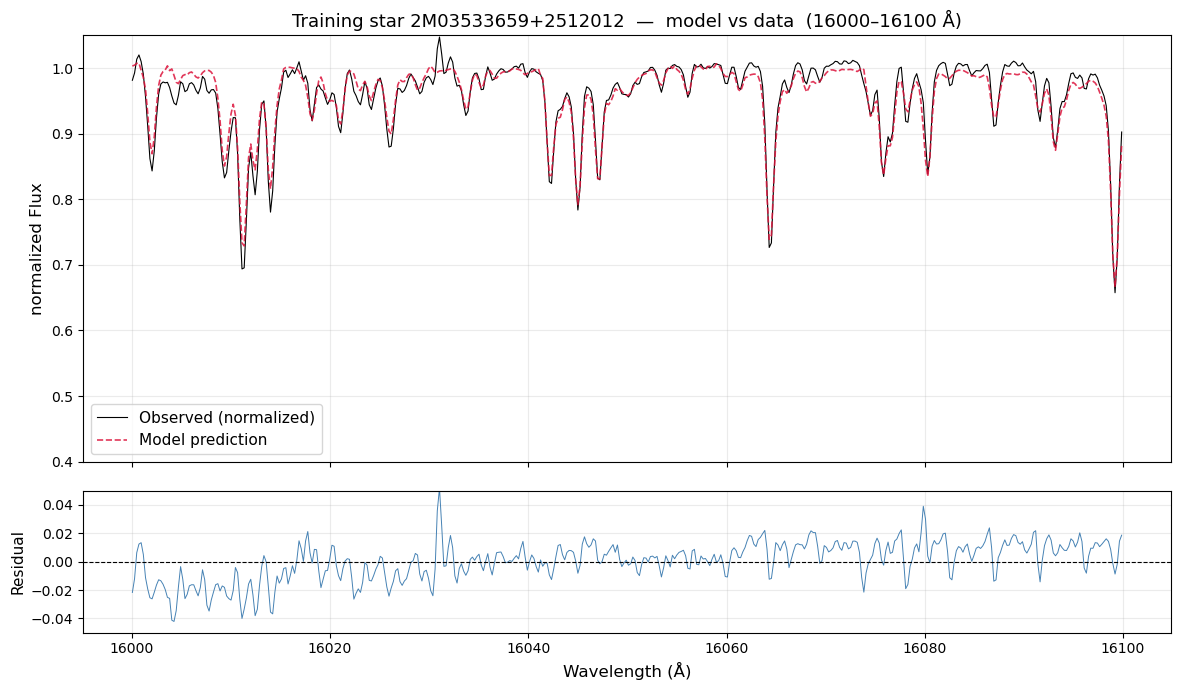


RMS residual in 16000–16100 Å window: 0.01355


In [15]:
#Verifying the trained model on a training-set star
#
# For this part I had to download and normalize star 2M03533659+2512012, look up its ASPCAP labels, predict its spectrum from those labels using ourtrained model, then overplot data and model in 16000-16100 angstroms.
# The two curves should be nearly indistinguishable for a well-trained model.

TARGET_ID = "2M03533659+2512012"

# frind the star in teh catalog
def match_apogee_id(df_col, target):
    """Return boolean mask matching target in a bytes-or-str column."""
    return df_col.apply(
        lambda x: (x.decode('utf-8') if isinstance(x, bytes) else x) == target
    )

row_mask = match_apogee_id(train_labels['apogee_id'], TARGET_ID)
if not row_mask.any():
    raise RuntimeError(
        f"{TARGET_ID} not found in training set. "
        "Check that it passed the quality cuts and ended up in train_df."
    )

star_row  = train_labels[row_mask].iloc[0]
star_idx = train_labels[row_mask].index[0]

# Labels from the ASPCAP catalog
star_labels = np.array([star_row[l] for l in LABEL_NAMES])
print(f"Star: {TARGET_ID}")
print(f"  Teff={star_labels[0]:.1f} K   logg={star_labels[1]:.3f}   "
      f"[Fe/H]={star_labels[2]:.3f}   [Mg/Fe]={star_labels[3]:.3f}   "
      f"[Si/Fe]={star_labels[4]:.3f}")

# observed & normalized spectrum
flux_obs = train_flux[star_idx].copy().astype(float)

# model predicted spectrum from labels
flux_mod = predict_spectrum(star_labels, thetas, label_means, label_scales)

# Select the 16000-16100 angstrom wavelength range 
wave_mask = (wavelengths >= 16000) & (wavelengths <= 16100)
wave_plot = wavelengths[wave_mask]
fobs_plot = flux_obs[wave_mask]
fmod_plot = flux_mod[wave_mask]

# Mask chip gaps / bad pixels in the observed spectrum for a clean plot
finite_plot = np.isfinite(fobs_plot)

# plot
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Top panel: observed vs model
ax = axes[0]
ax.plot(wave_plot[finite_plot], fobs_plot[finite_plot],
        color='black', linewidth=0.8, label='Observed (normalized)')
ax.plot(wave_plot[finite_plot], fmod_plot[finite_plot],
        color='crimson', linewidth=1.2, linestyle='--', alpha=0.85,
        label='Model prediction')
ax.set_ylabel('normalized Flux', fontsize=12)
ax.set_title(f'Training star {TARGET_ID}  —  model vs data  (16000–16100 Å)',
             fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.4, 1.05)
ax.grid(True, alpha=0.25)

# Bottom panel: residual  (data - model)
ax2 = axes[1]
residual = fobs_plot - fmod_plot
ax2.plot(wave_plot[finite_plot], residual[finite_plot],
         color='steelblue', linewidth=0.7)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Wavelength (Å)', fontsize=12)
ax2.set_ylabel('Residual', fontsize=11)
ax2.set_ylim(-0.05, 0.05)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f"{TARGET_ID}_model_vs_data.png", dpi=300)
plt.show()

rms_window = np.nanstd(residual[finite_plot])
print(f"\nRMS residual in 16000–16100 Å window: {rms_window:.5f}")

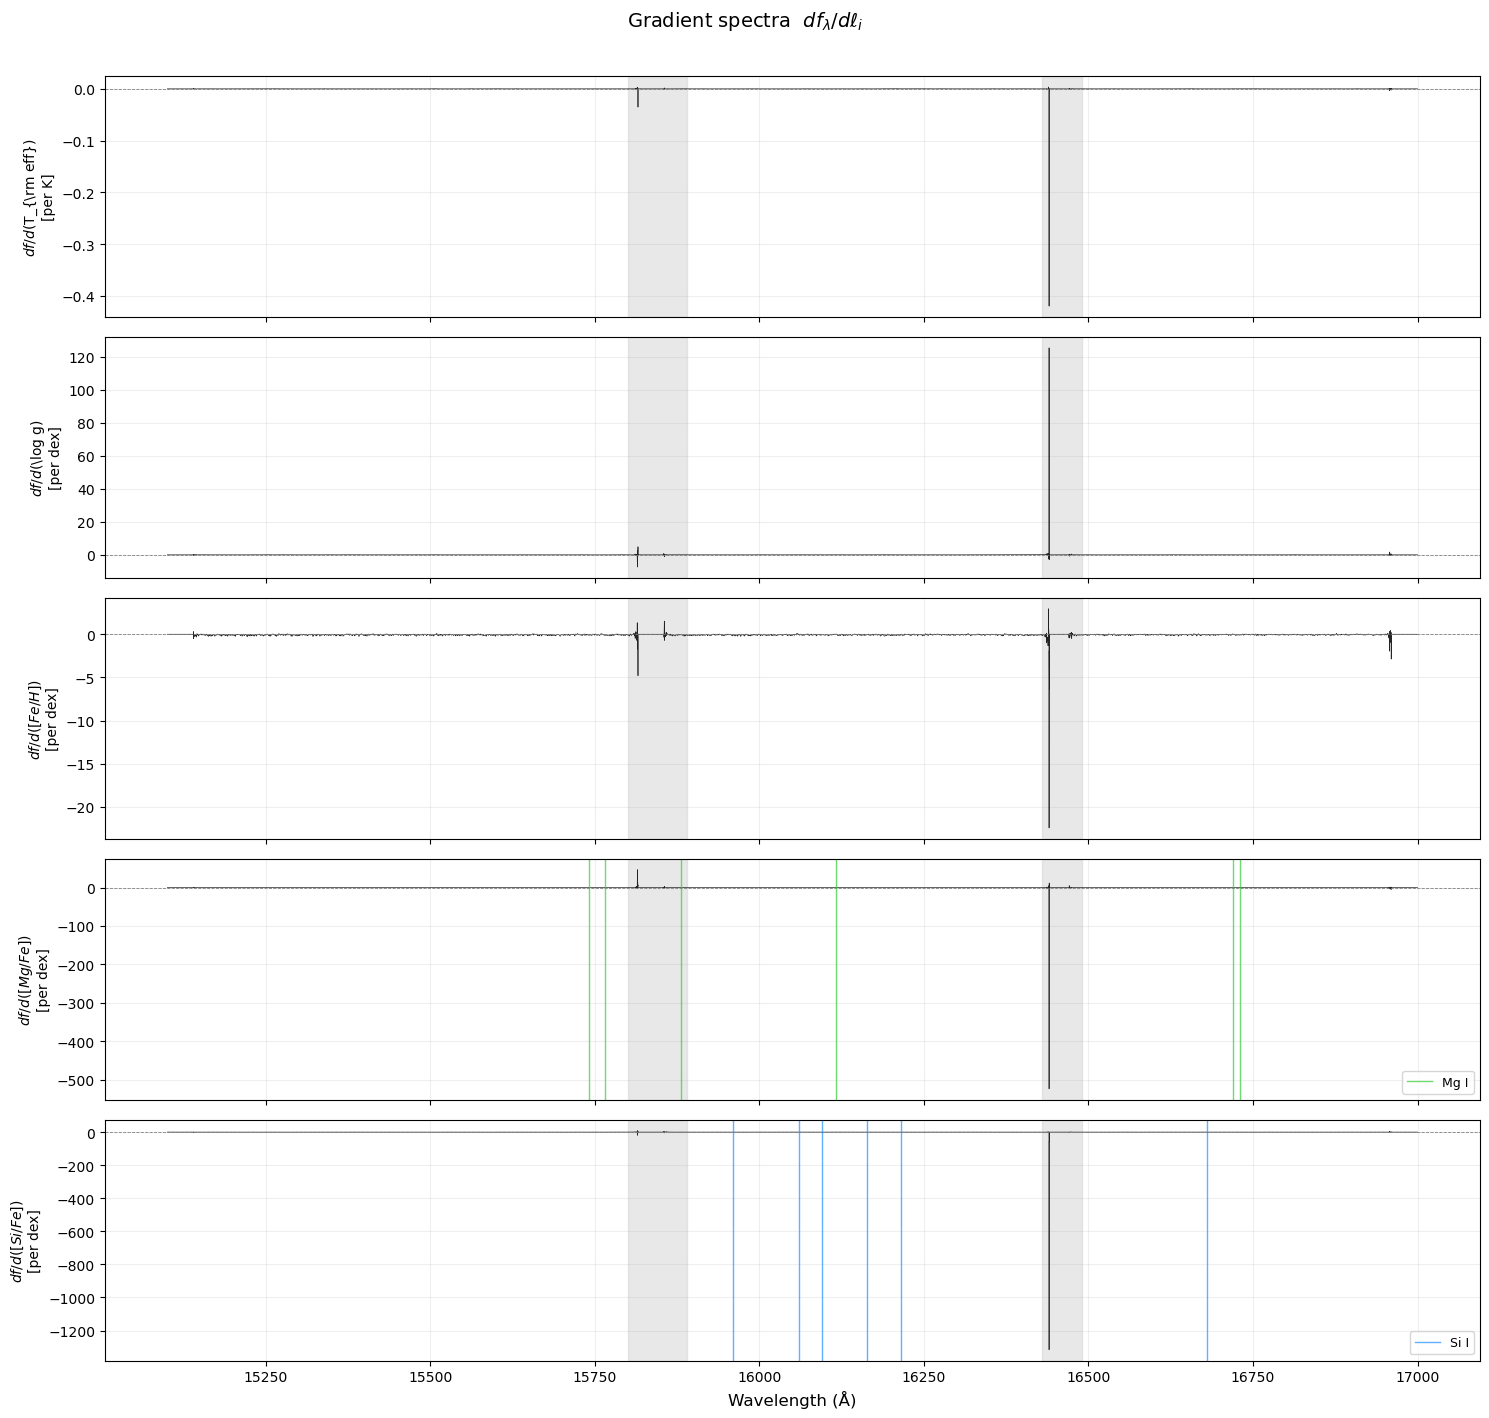

Pixels with largest |gradient| per label (top 3):
  $T_{\rm eff}$: [16440.2 15815.7 16440.4] Å
  $\log g$    : [16440.2 15814.8 15815.7] Å
  [Fe/H]      : [16440.2 16440.6 15815.7] Å
  [Mg/Fe]     : [16440.2 15814.8 15815.2] Å
  [Si/Fe]     : [16440.2 16440.6 16440.4] Å


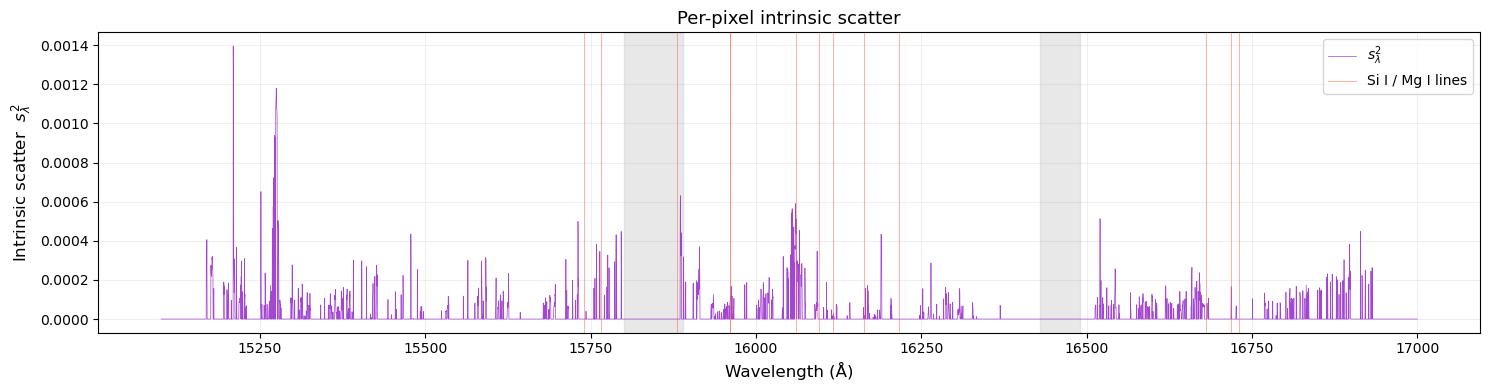


Mean s² near known Si/Mg lines  : 0.00003
Mean s² away from known lines   : 0.00002
Ratio (near/far)                : 1.87x
(A ratio >> 1 confirms scatter peaks at absorption features)


In [16]:
# finding the Gradient spectra df_lambda/dl_i and intrinsic scatter s^2
#
# At the mean labels (scaled l_i = 0), the gradient of the model
# with respect to raw label i simplifies to:
#
#   df_lambda / d(label_i_raw) = theta_lambda[i+1] / label_scales[i]
#
# Because all quadratic cross-terms l_j * l_k have zero gradient w/ respect to l_i when evaluated at l = 0 (the mean).  Only he linear coefficient theta[i+1] survives.
#
# I also made sure to mark known Si I and Mg I absorption lines in the APOGE H-band and plot the per-pixel intrinsic scatter s^2_lambda.

#  Known Si I and Mg I line wavelengths in the APOGEE H-band 
# Source: Smith et al. 2013 / APOGEE line list (DR17)
SI_LINES = [15960.06, 16060.01, 16094.79, 16163.67, 16215.67, 16680.77]
MG_LINES = [15740.72, 15765.84, 15881.36, 16115.92, 16718.96, 16730.78]

# Compute gradient spectra 
#theta indices: 0=constant, 1=Teff, 2=logg, 3=FeH, 4=MgFe, 5=SiFe
# Divide by label_scales to convert from "per scaled unit" to "per physical unit"
gradient_spectra = {}
for i, label in enumerate(LABEL_NAMES):
    gradient_spectra[label] = thetas[:, i + 1] / label_scales[i]

# Plot gradient spectra ----
label_display = [r'$T_{\rm eff}$', r'$\log g$', r'[Fe/H]', r'[Mg/Fe]', r'[Si/Fe]']
label_units= ['K', 'dex', 'dex', 'dex', 'dex']
line_info = {
    'mg_fe': (MG_LINES, 'limegreen',  'Mg I'),
    'si_fe': (SI_LINES, 'dodgerblue', 'Si I'),
}

fig, axes = plt.subplots(5, 1, figsize=(15, 14), sharex=True)
fig.suptitle('Gradient spectra  $df_\\lambda / d\\ell_i$',
             fontsize=14, y=1.01)

for i, (label, disp, unit) in enumerate(zip(LABEL_NAMES, label_display, label_units)):
    ax = axes[i]
    grad = gradient_spectra[label]

    # Mask chip gaps
    finite = np.isfinite(grad) & np.isfinite(wavelengths)
    ax.plot(wavelengths[finite], grad[finite],
            color='black', linewidth=0.5, alpha=0.85)
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')

    # Mark element-specific absorption lines
    if label in line_info:
        line_waves, lcolor, lname = line_info[label]
        for wl in line_waves:
            ax.axvline(wl, color=lcolor, linewidth=1.0, alpha=0.7,
                       linestyle='-', label=lname if wl == line_waves[0] else '')
        ax.legend(fontsize=9, loc='lower right')

    ax.set_ylabel(f'$df/d({disp})$\n[per {unit}]', fontsize=10)
    ax.grid(True, alpha=0.2)

    # Shade the three chip regions lightly so gaps are visible
    for gap_start, gap_end in [(15800, 15890), (16430, 16490)]:
        ax.axvspan(gap_start, gap_end, color='lightgray', alpha=0.5, zorder=0)

axes[-1].set_xlabel('Wavelength (Å)', fontsize=12)
plt.tight_layout()
plt.savefig("gradient_spectra.png", dpi=300, bbox_inches='tight')
plt.show()

#  Print the pixels with the largest gradient for each label 
print("Pixels with largest |gradient| per label (top 3):")
for label, disp in zip(LABEL_NAMES, label_display):
    grad = gradient_spectra[label]
    finite = np.isfinite(grad)
    top_idx = np.argsort(np.abs(grad[finite]))[-3:][::-1]
    top_waves = wavelengths[finite][top_idx]
    print(f"  {disp:12s}: {np.round(top_waves, 1)} Å")

#Plot intrinsic scatter s^2_lambda 
fig, ax = plt.subplots(figsize=(15, 4))

finite_s2 = np.isfinite(s2_all)
ax.plot(wavelengths[finite_s2], s2_all[finite_s2],
        color='darkorchid', linewidth=0.5, alpha=0.9, label='$s^2_\\lambda$')

# Overlay known strong lines from all five elements to check correlation
all_lines = SI_LINES + MG_LINES
for wl in all_lines:
    ax.axvline(wl, color='tomato', linewidth=0.7, alpha=0.5)
# Dummy handle for legend
ax.axvline(all_lines[0], color='tomato', linewidth=0.7, alpha=0.5,
           label='Si I / Mg I lines')

# Shade chip gaps
for gap_start, gap_end in [(15800, 15890), (16430, 16490)]:
    ax.axvspan(gap_start, gap_end, color='lightgray', alpha=0.5, zorder=0)

ax.set_xlabel('Wavelength (Å)', fontsize=12)
ax.set_ylabel('Intrinsic scatter  $s^2_\\lambda$', fontsize=12)
ax.set_title('Per-pixel intrinsic scatter',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("intrinsic_scatter.png", dpi=300)
plt.show()

#  Quantify correlation with absorption lines 
# Pixels near a known line (within 5 Å) should have higher mean s^2
near_line = np.zeros(len(wavelengths), dtype=bool)
for wl in all_lines:
    near_line |= (np.abs(wavelengths - wl) < 5.0)

s2_near = np.nanmean(s2_all[near_line  & finite_s2])
s2_far  = np.nanmean(s2_all[~near_line & finite_s2])
print(f"\nMean s² near known Si/Mg lines  : {s2_near:.5f}")
print(f"Mean s² away from known lines   : {s2_far:.5f}")
print(f"Ratio (near/far)                : {s2_near/s2_far:.2f}x")
print("(A ratio >> 1 confirms scatter peaks at absorption features)")

In [17]:
# Fit labels for every star in the cross-validation set
#
# For each star I minimized the weighted chi^2 between the observed
# normalized flux and the model prediction:
#
#   chi^2 = sum_lambda [ (f_obs - theta^T l)^2 / (s^2_lambda + sigma^2_lambda) ]
#
# Iused scipy.optimize.curve_fit with method='trf' (Trust Region Reflective), which the lab writeup recommends for robustness.
# The total uncertainty per pixel is the quadrature sum of the measurement noise sigma_lambda and the intrinsic model scatter s_lambda.
from scipy.optimize import curve_fit

# Load and normalize all validation spectra 
print("Loading validation spectra...")
val_flux_raw, val_error_raw, val_valid = load_spectra_set(
    val_df, wavelengths, continuum_mask_formatted, desc="Validation set"
)

val_flux   = val_flux_raw[val_valid].astype(float)
val_error  = val_error_raw[val_valid].astype(float)
val_labels = val_df[val_valid].reset_index(drop=True)

print(f"Loaded {val_valid.sum()} / {len(val_df)} validation stars\n")

# Label bounds 
# TRF will stay inside these, preventing the optimizer from wandering into unphysical regions of label space.
BOUNDS_LO = [3500.0, -0.5, -1.05, -0.6, -0.6]
BOUNDS_HI = [5750.0,  4.1,  0.55,  0.9,  0.9]

#Fitting function 
def fit_labels_trf(norm_flux, norm_error, thetas, s2_all,
                   label_means, label_scales, p0=None):
    """
    Find the maximum-likelihood labels for one spectrum using curve_fit / TRF.

    The curve_fit interface requires a function of the form
        model(xdata, param1, param2, ...) -> ydata
    I passed pixel indices as dummy xdata (curve_fit needs *something*).
    The real information is in the closure over thetas_good and the label-vector construction.

    Parameters:
    norm_flux: (N_pix,)  observed normalized flux
    norm_error: (N_pix,)  flux uncertainty  (bad pixels already >> 1e9)
    thetas: (N_pix, 21) trained model coefficients
    s2_all: (N_pix,)  intrinsic scatter variance per pixel
    label_means: (5,)      training-set label means
    label_scales: (5,)      training-set label scales
    p0: (5,)      initial guess; defaults to training-set means

    Returns:
    popt: (5,) best-fit [Teff, logg, FeH, MgFe, SiFe], or None on failure
    perr: (5,) 1-sigma formal uncertainties from the covariance matrix
    """
    # making sure to select good pixels
    good = (
        np.isfinite(norm_flux)
        & np.isfinite(norm_error)
        & (norm_error > 0)
        & (norm_error < 1e9)
    )

    if good.sum() < 50:# too few pixels to constrain 5 labels
        return None, None

    f_obs   = norm_flux[good]

    # Total uncertainty: measurement noise + intrinsic model scatter
    # Using the full variance keeps chi^2 well-calibrated (Ness eq. 4)
    total_sigma = np.sqrt(norm_error[good]**2 + np.clip(s2_all[good], 0, None))
    total_sigma = np.clip(total_sigma, 1e-6, None)

    # Precompute the theta slice for this star's good pixels once,
    # outside the objective, so the inner loop is just a matrix multiply
    thetas_good = thetas[good]# (N_good, 21)
    dummy_x = np.zeros(good.sum())# required by curve_fit API

    def model_func(dummy, teff, logg, feh, mgfe, sife):
        """Predicted flux at good pixels for a given label vector."""
        l_arr = np.array([[teff, logg, feh, mgfe, sife]])
        l_vec = make_design_matrix(l_arr, label_means, label_scales)[0]  # (21,)
        return thetas_good @ l_vec# (N_good,)

    if p0 is None:
        p0 = label_means.copy()

    try:
        popt, pcov = curve_fit(
            model_func,
            dummy_x,
            f_obs,
            p0=p0,
            sigma=total_sigma,
            absolute_sigma=True,
            method='trf',
            bounds=(BOUNDS_LO, BOUNDS_HI),
            ftol=1e-4,
            xtol=1e-4,
            max_nfev=5000
        )
        perr = np.sqrt(np.diag(pcov))
        return popt, perr
    except Exception:
        return None, None


# Loop over all validation stars
N_val= len(val_labels)
fitted= np.full((N_val, 5), np.nan)
fit_errs = np.full((N_val, 5), np.nan)
converged = np.zeros(N_val, dtype=bool)

p0_default = label_means.copy()

for i in tqdm(range(N_val), desc="Fitting validation labels"):
    popt, perr = fit_labels_trf(
        val_flux[i], val_error[i],
        thetas, s2_all,
        label_means, label_scales,
        p0=p0_default
    )
    if popt is not None:
        fitted[i] = popt
        fit_errs[i] = perr
        converged[i]= True

n_ok = converged.sum()
print(f"\nConverged : {n_ok} / {N_val}  ({100*n_ok/N_val:.1f}%)")
print(f"Failed    : {N_val - n_ok}")

Loading validation spectra...


Validation set:   0%|          | 0/943 [00:00<?, ?it/s]

  ⚠  Skipping star 803: buffer is too small for requested array
Loaded 942 / 943 validation stars



Fitting validation labels:   0%|          | 0/942 [00:00<?, ?it/s]


Converged : 942 / 942  (100.0%)
Failed    : 0


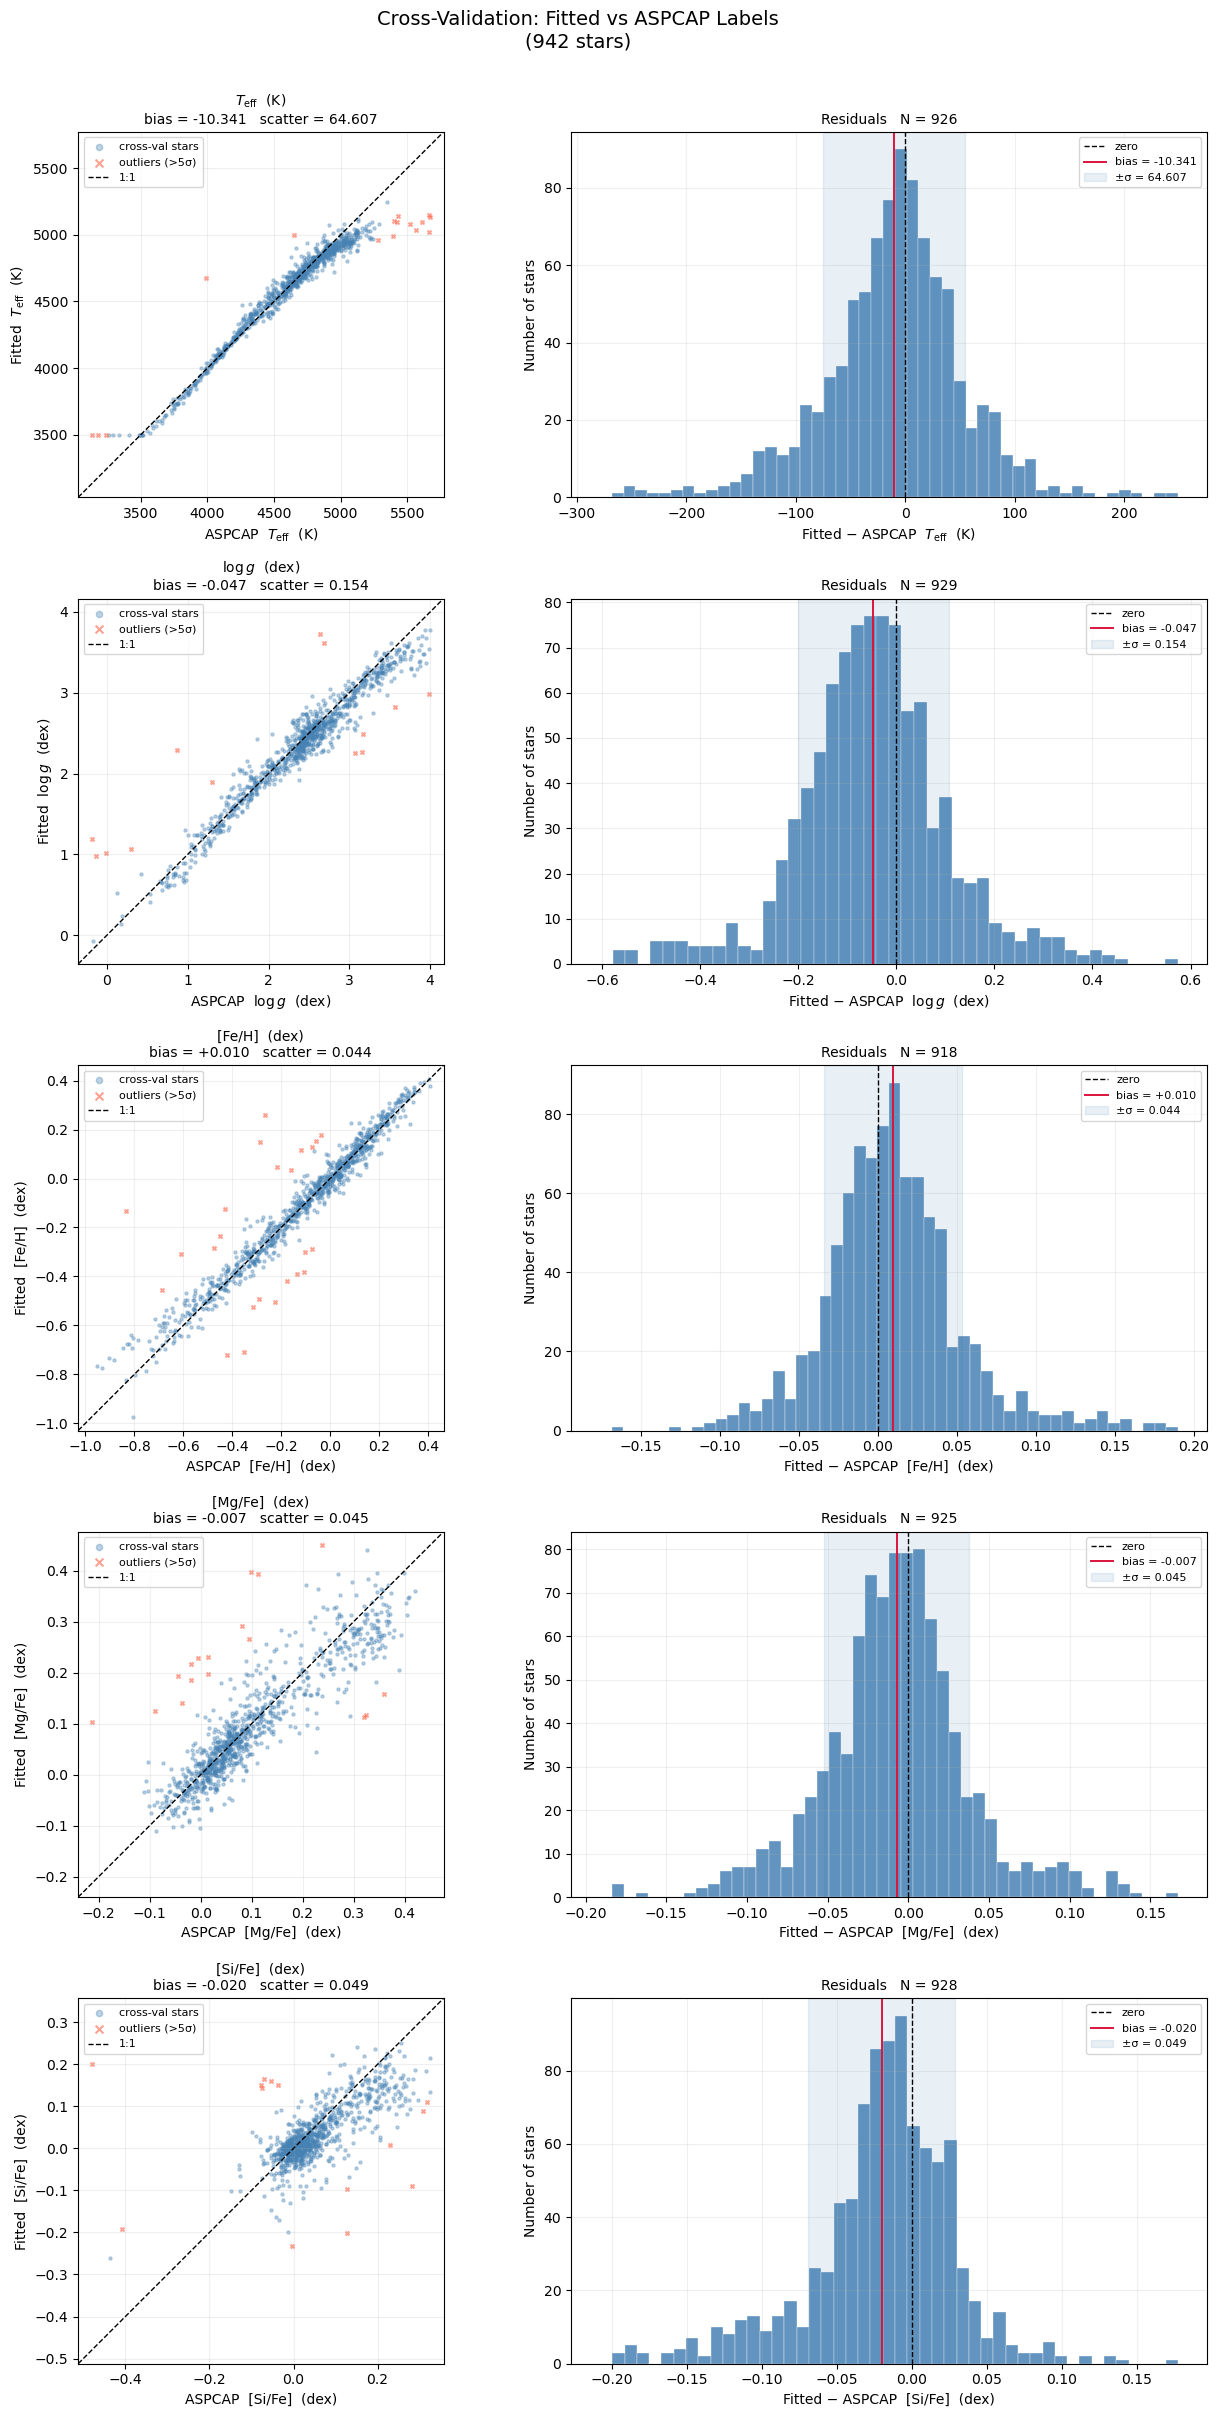


=== Cross-validation summary (5σ-clipped) ===
Label             Bias     Scatter         N
--------------------------------------------
teff           -10.341      64.607       926  ← review model
logg            -0.047       0.154       929  ← review model
fe_h            +0.010       0.044       918  ← review model
mg_fe           -0.007       0.045       925  ← review model
si_fe           -0.020       0.049       928  ← review model

Target performance:
  teff      scatter < 30.0
  logg      scatter < 0.1
  fe_h      scatter < 0.02
  mg_fe     scatter < 0.03
  si_fe     scatter < 0.03


In [18]:
# Compare fitted labels to ASPCAP values
#
#   Left panel: scatter plot (fitted vs ASPCAP) with 1:1 line
#   Right panel: histogram of residuals (fitted - ASPCAP)
# (these are for eafch of the 5 labels)
#
# We report bias (mean residual) and scatter (std of residuals)
# after a single round of 5-sigma outlier rejection.
# Target performance: ~30 K in Teff, ~0.10 in logg, ~0.02 in [Fe/H].

LABEL_DISPLAY = [
    r'$T_{\rm eff}$  (K)',
    r'$\log g$  (dex)',
    r'[Fe/H]  (dex)',
    r'[Mg/Fe]  (dex)',
    r'[Si/Fe]  (dex)',
]

# Use only stars where curve_fit converged
ok = converged
aspcap_all = np.column_stack([val_labels[l].values for l in LABEL_NAMES])[ok]
fitted_all = fitted[ok]
fit_errs_all = fit_errs[ok]

fig, axes = plt.subplots(5, 2, figsize=(13, 24))
fig.suptitle('Cross-Validation: Fitted vs ASPCAP Labels\n'
             f'({ok.sum()} stars)', fontsize=14, y=1.005)

stats_rows = []   # collect for the summary table

for i, (lname, disp) in enumerate(zip(LABEL_NAMES, LABEL_DISPLAY)):

    aspcap_i = aspcap_all[:, i]
    fitted_i = fitted_all[:, i]
    residuals = fitted_i - aspcap_i

    #  5-sigma outlier rejection (one pass, robust using MAD) 
    med = np.nanmedian(residuals)
    mad = np.nanmedian(np.abs(residuals - med)) * 1.4826   # converts MAD → std
    clean = np.abs(residuals - med) < 5.0 * mad

    bias = float(np.nanmean(residuals[clean]))
    scatter = float(np.nanstd(residuals[clean]))
    n_clean = int(clean.sum())
    stats_rows.append((lname, bias, scatter, n_clean))

    #  Left panel: fitted vs ASPCAP 
    ax = axes[i, 0]
    ax.scatter(aspcap_i[clean], fitted_i[clean],
               s=5, alpha=0.35, color='steelblue', rasterized=True,
               label='cross-val stars')
    if (~clean).any():
        ax.scatter(aspcap_i[~clean], fitted_i[~clean],
                   s=8, alpha=0.6, color='tomato', marker='x',
                   label='outliers (>5σ)')

    lo = min(aspcap_i.min(), fitted_i.min())
    hi = max(aspcap_i.max(), fitted_i.max())
    pad = 0.04 * (hi - lo)
    lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, 'k--', linewidth=1.0, label='1:1')
    ax.set_xlim(lims); ax.set_ylim(lims)

    ax.set_xlabel(f'ASPCAP  {disp}', fontsize=10)
    ax.set_ylabel(f'Fitted  {disp}',  fontsize=10)
    ax.set_title(f'{disp}\nbias = {bias:+.3f}   scatter = {scatter:.3f}',
                 fontsize=10)
    ax.legend(fontsize=8, markerscale=2)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)

    #  Right panel: residual histogram 
    ax2 = axes[i, 1]
    bin_width = 2.5 * scatter / max(int(n_clean**0.4), 1)   # Scott-ish rule
    bins = np.arange(residuals[clean].min() - bin_width,
                     residuals[clean].max() + bin_width,
                     bin_width)
    ax2.hist(residuals[clean], bins=bins,
             color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.85)
    ax2.axvline(0,    color='black',   linewidth=1.0, linestyle='--',
                label='zero')
    ax2.axvline(bias, color='crimson', linewidth=1.4, linestyle='-',
                label=f'bias = {bias:+.3f}')
    ax2.axvspan(bias - scatter, bias + scatter,
                color='steelblue', alpha=0.12, label=f'±σ = {scatter:.3f}')

    ax2.set_xlabel(f'Fitted − ASPCAP  {disp}', fontsize=10)
    ax2.set_ylabel('Number of stars',           fontsize=10)
    ax2.set_title(f'Residuals   N = {n_clean}', fontsize=10)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("crossval_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

#  Summary table 
col_w = [10, 10, 10, 8]
header = f"{'Label':<{col_w[0]}}  {'Bias':>{col_w[1]}}  {'Scatter':>{col_w[2]}}  {'N':>{col_w[3]}}"
print("\n=== Cross-validation summary (5σ-clipped) ===")
print(header)
print("-" * (sum(col_w) + 6))
targets = {'teff': 30.0, 'logg': 0.10, 'fe_h': 0.02, 'mg_fe': 0.03, 'si_fe': 0.03}
for lname, bias, scatter, n in stats_rows:
    flag = "  ✓" if scatter <= targets.get(lname, np.inf) else "  ← review model"
    print(f"{lname:<{col_w[0]}}  {bias:>+{col_w[1]}.3f}  {scatter:>{col_w[2]}.3f}  "
          f"{n:>{col_w[3]}}{flag}")

print("\nTarget performance:")
for lname, tgt in targets.items():
    print(f"  {lname:<8}  scatter < {tgt}")

In [19]:
# Identify cross-validation outliers and query flags
#
# define an outlier as any star whose residual in any of the five labels exceeds 5× the label's MAD-based scatter.  For each outlier:
#   Record the signed residual for all five labels
#   Check SNR 
#   Query ASPCAP flags from the catalog for those stars
from astroquery.sdss import SDSS

# rebuilding pre label scatters
# stats_rows = [(lname, bias, scatter, n_clean), ...]
scatter_thresholds = {lname: scatter for lname, _, scatter, _ in stats_rows}

#Compute residuals for all converged validation stars
residuals_all = fitted_all - aspcap_all    # (N_converged, 5)

# A star is an outlier if it exceeds 5 sigmas in any label
sigma_cut = 5.0
is_outlier = np.zeros(fitted_all.shape[0], dtype=bool)
for i, lname in enumerate(LABEL_NAMES):
    thresh = sigma_cut * scatter_thresholds[lname]
    is_outlier |= (np.abs(residuals_all[:, i]) > thresh)

outlier_idx = np.where(is_outlier)[0]   # indices within fitted_all / aspcap_all
print(f"Outliers (>{sigma_cut}σ in ≥1 label): {len(outlier_idx)} / {fitted_all.shape[0]}")
print()

# Build a summary table of outlier residuals
print(f"{'#':<4} {'APOGEE ID':<25} {'SNR':>5}  "
      + "  ".join(f"{l:>10}" for l in LABEL_NAMES))
print("-" * (4 + 25 + 7 + 12 * len(LABEL_NAMES)))

outlier_ids = []
for rank, idx in enumerate(outlier_idx):
    aid = decode_id(val_labels.iloc[idx]['apogee_id'])
    snr = val_labels.iloc[idx]['snr']
    outlier_ids.append(aid)
    resid_str = "  ".join(f"{residuals_all[idx, j]:>+10.3f}" for j in range(5))
    print(f"{rank:<4} {aid:<25} {snr:>5.1f}  {resid_str}")

# Query ASPCAP flags for outlier stars
# Fetching STARFLAG and ASPCAPFLAG — both are bitmasks indicating data-quality issues.  A non-zero ASPCAPFLAG often means the pipeline itself flagged the label as unreliable.
print("\nQuerying ASPCAP flags for outliers...")

# Build a SQL-safe list of IDs
id_list_sql = ", ".join(f"'{aid}'" for aid in outlier_ids)

flag_query = f"""
SELECT s.apogee_id, s.starflag, s.snr, a.aspcapflag,
       a.teff, a.logg, a.fe_h, a.mg_fe, a.si_fe
FROM apogeeStar s
JOIN aspcapStar a ON s.apstar_id = a.apstar_id
WHERE s.apogee_id IN ({id_list_sql})
"""

try:
    flag_data = SDSS.query_sql(flag_query, data_release=17, cache=False)
    flag_df   = flag_data.to_pandas()

    # Decode byte strings
    flag_df['apogee_id'] = flag_df['apogee_id'].apply(decode_id)

    # Interpret the most important ASPCAPFLAG bits
    # DR17 bitmask definitions (Holtzman et al. 2015 / SDSS docs):
    ASPCAPFLAG_BITS = {
        0:  'TEFF_WARN',    1:  'LOGG_WARN',     2:  'VMICRO_WARN',
        3:  'M_H_WARN',     4:  'ALPHA_M_WARN',   5:  'C_M_WARN',
        6:  'N_M_WARN',     7:  'STAR_WARN',
        16: 'TEFF_BAD',     17: 'LOGG_BAD',       18: 'VMICRO_BAD',
        19: 'M_H_BAD',      20: 'ALPHA_M_BAD',    21: 'C_M_BAD',
        22: 'N_M_BAD',      23: 'STAR_BAD',
    }
    STARFLAG_BITS = {
        0: 'BAD_PIXELS',    1: 'COMMISSIONING',   2: 'BRIGHT_NEIGHBOR',
        3: 'VERY_BRIGHT_NEIGHBOR', 4: 'LOW_SNR',
        9: 'PERSIST_HIGH', 10: 'PERSIST_MED',    11: 'PERSIST_LOW',
        12: 'PERSIST_JUMP_POS', 13: 'PERSIST_JUMP_NEG',
        16: 'SUSPECT_RV_COMBINATION', 17: 'SUSPECT_BROAD_LINES',
    }

    def decode_flags(bitmask_val, bit_dict):
        #Return list of set flag names for a given integer bitmask
        if bitmask_val is None or bitmask_val != bitmask_val:  # NaN check
            return ['UNKNOWN']
        flags = [name for bit, name in bit_dict.items()
                 if int(bitmask_val) & (1 << bit)]
        return flags if flags else ['NONE']

    print(f"\n{'APOGEE ID':<25}  {'STARFLAG':<35}  {'ASPCAPFLAG'}")
    print("-" * 90)
    for _, frow in flag_df.iterrows():
        sf = decode_flags(frow['starflag'],   STARFLAG_BITS)
        acf = decode_flags(frow['aspcapflag'], ASPCAPFLAG_BITS)
        print(f"{frow['apogee_id']:<25}  {', '.join(sf):<35}  {', '.join(acf)}")

except Exception as e:
    print(f"Flag query failed: {e}")
    print("Continuing without catalog flags.")
    flag_df = None

Outliers (>5.0σ in ≥1 label): 24 / 942

#    APOGEE ID                   SNR        teff        logg        fe_h       mg_fe       si_fe
------------------------------------------------------------------------------------------------
0    2M19294176+3747402         72.7    +187.657      +0.045      -0.169      +0.299      +0.682
1    2M19274322+3904194        157.3    +235.877      -0.485      +0.302      -0.009      -0.057
2    2M03540527+2520091        153.8    -398.653      +0.064      -0.067      +0.129      +0.088
3    2M21244636+1131366         58.5      -5.788      +0.068      +0.233      -0.055      -0.161
4    2M21295222+1159409        142.8    -312.781      -0.455      -0.208      +0.281      +0.129
5    2M19462842+2453530        541.2    +367.052      +1.112      +0.180      +0.205      +0.217
6    2M19410898+2240121        132.6     -73.425      -0.882      +0.039      +0.040      +0.010
7    2M21300216+1203163         59.3    -528.031      -0.995      +0.009      -0.036   

Diagnosing 6 worst outliers (20 random re-fits each)...

Outlier #1: 2M21281377+1054307  (SNR=422.4)
  ASPCAP : Teff=3993  logg=0.87  [Fe/H]=-0.834  [Mg/Fe]=0.014  [Si/Fe]=0.000
  Fitted : Teff=4675  logg=2.30  [Fe/H]=-0.133  [Mg/Fe]=0.197  [Si/Fe]=0.076
  Residuals: teff:+681.942  logg:+1.426  fe_h:+0.702  mg_fe:+0.183  si_fe:+0.076


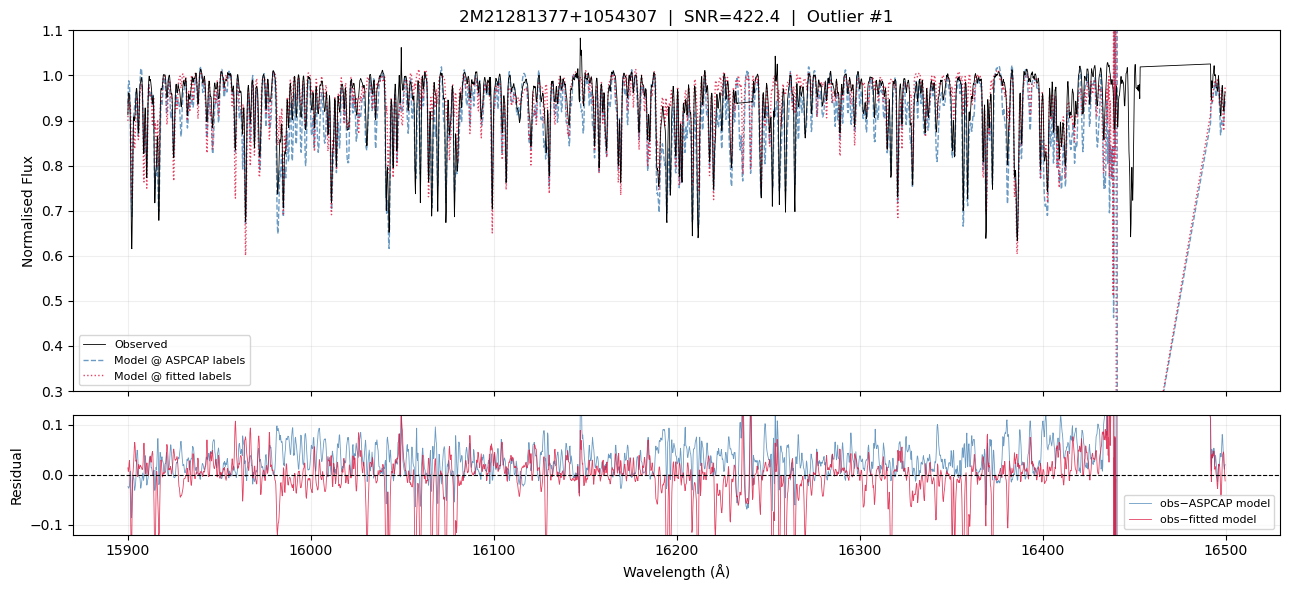

  chi^2 @ original fit  : 15869164.5
  chi^2 @ ASPCAP labels : 30220708.3
  chi^2 @ best re-fit   : 10784991.6
  chi^2 spread (20 starts): 10993691.52
  Label spread across starts: teff:278.415  logg:0.417  fe_h:0.178  mg_fe:0.177  si_fe:0.107
  Flags  : STARFLAG=['NONE']  ASPCAPFLAG=['VMICRO_WARN']
  VERDICT: CATALOG FLAG: ASPCAP itself flagged this star as unreliable. | LOCAL MINIMUM: large spread across re-fits suggests the optimizer got stuck; best re-fit may be more reliable.

Outlier #2: 2M19294176+3747402  (SNR=72.7)
  ASPCAP : Teff=4749  logg=3.37  [Fe/H]=-0.806  [Mg/Fe]=0.098  [Si/Fe]=-0.480
  Fitted : Teff=4937  logg=3.41  [Fe/H]=-0.975  [Mg/Fe]=0.398  [Si/Fe]=0.202
  Residuals: teff:+187.657  logg:+0.045  fe_h:-0.169  mg_fe:+0.299  si_fe:+0.682


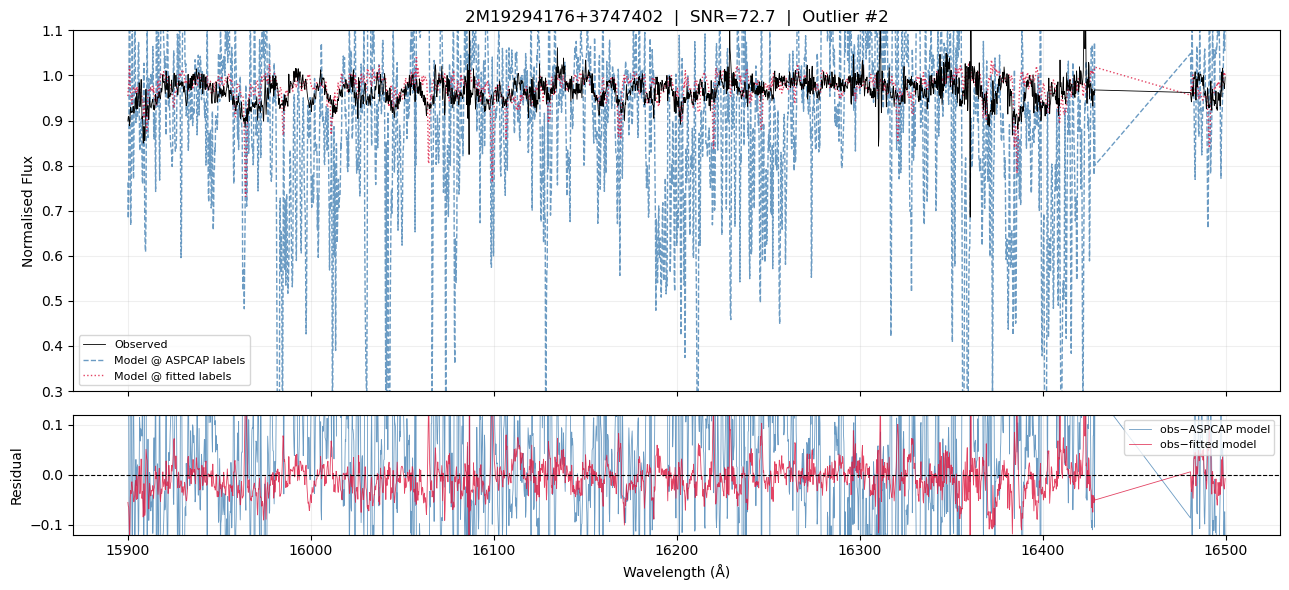

  chi^2 @ original fit  : 40953.2
  chi^2 @ ASPCAP labels : 1351566.6
  chi^2 @ best re-fit   : 40951.5
  chi^2 spread (20 starts): 1149.13
  Label spread across starts: teff:56.482  logg:0.035  fe_h:0.085  mg_fe:0.036  si_fe:0.038
  Flags  : STARFLAG=['BRIGHT_NEIGHBOR']  ASPCAPFLAG=['N_M_WARN', 'STAR_WARN']
  VERDICT: CATALOG FLAG: ASPCAP itself flagged this star as unreliable. | LOCAL MINIMUM: large spread across re-fits suggests the optimizer got stuck; best re-fit may be more reliable. | NORMALISATION ISSUE: model fits the observed spectrum poorly even at ASPCAP labels, suggesting a bad continuum normalisation rather than a label error.

Outlier #3: 2M19403522+2411380  (SNR=1232.0)
  ASPCAP : Teff=3177  logg=-0.19  [Fe/H]=-0.264  [Mg/Fe]=-0.018  [Si/Fe]=-0.069
  Fitted : Teff=3500  logg=1.19  [Fe/H]=0.258  [Mg/Fe]=0.218  [Si/Fe]=0.166
  Residuals: teff:+323.061  logg:+1.380  fe_h:+0.523  mg_fe:+0.236  si_fe:+0.235


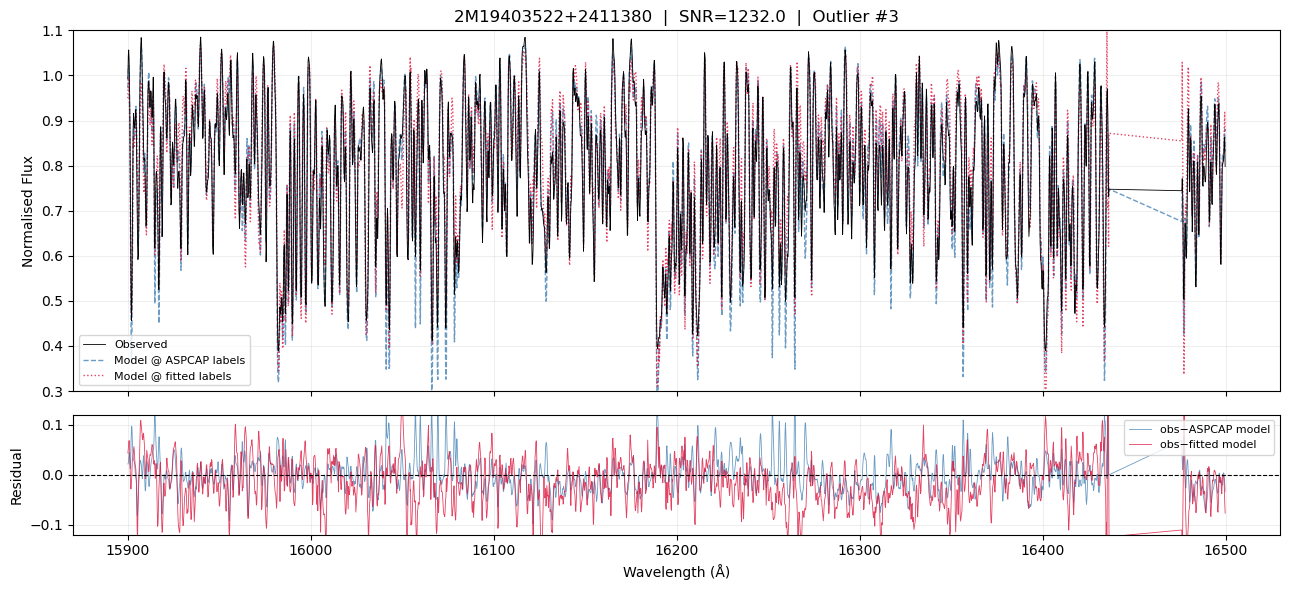

  chi^2 @ original fit  : 36144727.4
  chi^2 @ ASPCAP labels : 19692454.8
  chi^2 @ best re-fit   : 34830251.8
  chi^2 spread (20 starts): 1897082.40
  Label spread across starts: teff:0.015  logg:0.783  fe_h:0.420  mg_fe:0.131  si_fe:0.125
  Flags  : STARFLAG=['NONE']  ASPCAPFLAG=['TEFF_WARN', 'LOGG_WARN', 'STAR_WARN']
  VERDICT: CATALOG FLAG: ASPCAP itself flagged this star as unreliable. | LOCAL MINIMUM: large spread across re-fits suggests the optimizer got stuck; best re-fit may be more reliable.

Outlier #4: 2M19465902+2506418  (SNR=810.9)
  ASPCAP : Teff=3240  logg=-0.01  [Fe/H]=-0.286  [Mg/Fe]=-0.045  [Si/Fe]=-0.077
  Fitted : Teff=3500  logg=1.02  [Fe/H]=0.150  [Mg/Fe]=0.193  [Si/Fe]=0.152
  Residuals: teff:+259.850  logg:+1.030  fe_h:+0.436  mg_fe:+0.238  si_fe:+0.229


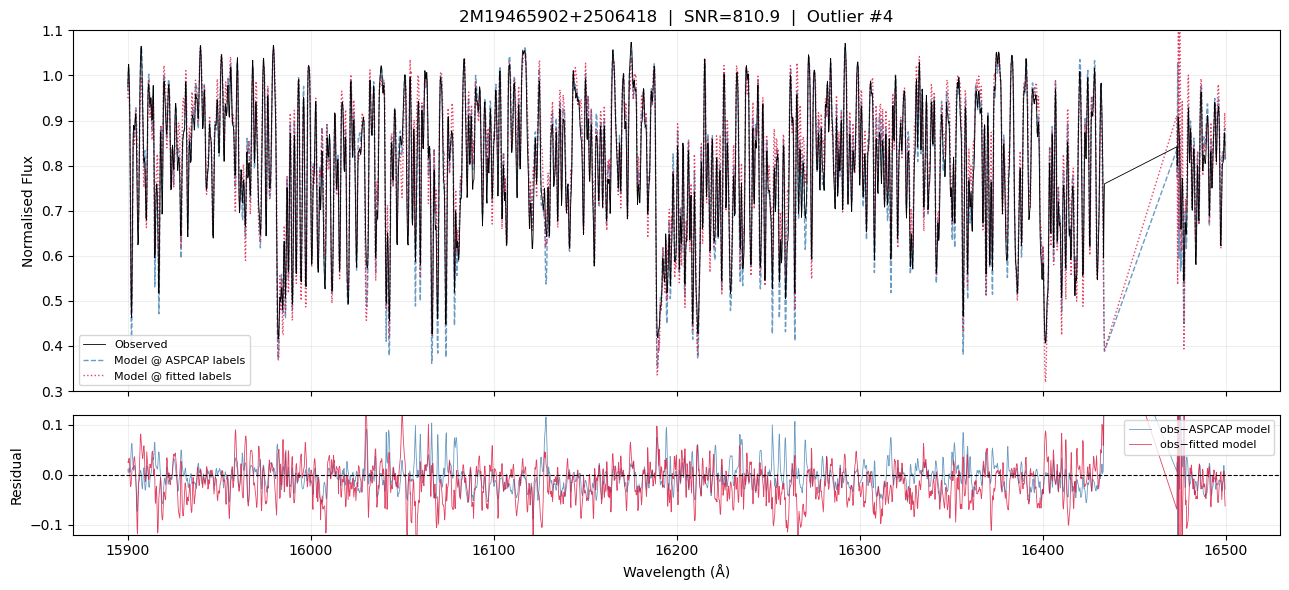

  chi^2 @ original fit  : 10120271.3
  chi^2 @ ASPCAP labels : 4601387.1
  chi^2 @ best re-fit   : 7885309.6
  chi^2 spread (20 starts): 1101545.78
  Label spread across starts: teff:0.004  logg:0.591  fe_h:0.377  mg_fe:0.101  si_fe:0.110
  Flags  : STARFLAG=['NONE']  ASPCAPFLAG=['NONE']
  VERDICT: LOCAL MINIMUM: large spread across re-fits suggests the optimizer got stuck; best re-fit may be more reliable.

Outlier #5: 2M21262950+1144460  (SNR=70.7)
  ASPCAP : Teff=5658  logg=3.29  [Fe/H]=-0.226  [Mg/Fe]=0.281  [Si/Fe]=0.264
  Fitted : Teff=5018  logg=2.75  [Fe/H]=-0.503  [Mg/Fe]=0.296  [Si/Fe]=0.120
  Residuals: teff:-640.849  logg:-0.538  fe_h:-0.277  mg_fe:+0.014  si_fe:-0.145


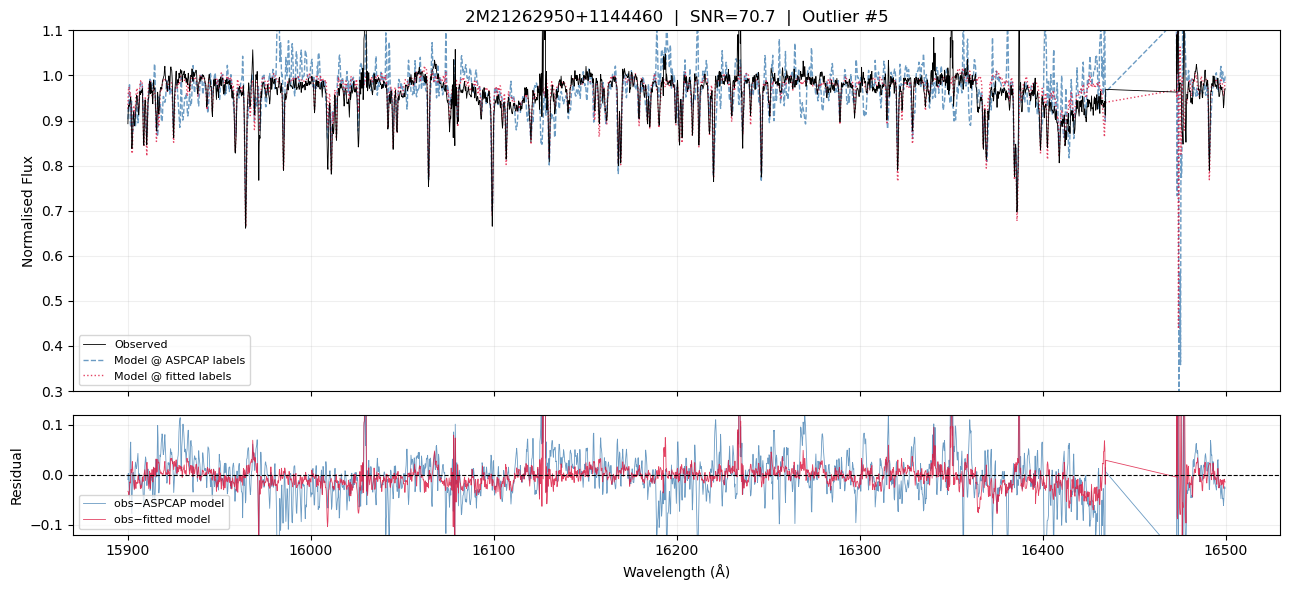

  chi^2 @ original fit  : 18292.4
  chi^2 @ ASPCAP labels : 67163.5
  chi^2 @ best re-fit   : 18017.2
  chi^2 spread (20 starts): 461.63
  Label spread across starts: teff:50.079  logg:0.338  fe_h:0.081  mg_fe:0.158  si_fe:0.077
  Flags  : STARFLAG=['PERSIST_HIGH']  ASPCAPFLAG=['TEFF_WARN', 'STAR_WARN']
  VERDICT: CATALOG FLAG: ASPCAP itself flagged this star as unreliable. | LOCAL MINIMUM: large spread across re-fits suggests the optimizer got stuck; best re-fit may be more reliable. | NORMALISATION ISSUE: model fits the observed spectrum poorly even at ASPCAP labels, suggesting a bad continuum normalisation rather than a label error.

Outlier #6: 2M19292252+3904095  (SNR=125.2)
  ASPCAP : Teff=5669  logg=3.56  [Fe/H]=-0.106  [Mg/Fe]=-0.214  [Si/Fe]=-0.089
  Fitted : Teff=5135  logg=3.39  [Fe/H]=-0.381  [Mg/Fe]=0.104  [Si/Fe]=0.029
  Residuals: teff:-533.735  logg:-0.171  fe_h:-0.275  mg_fe:+0.318  si_fe:+0.118


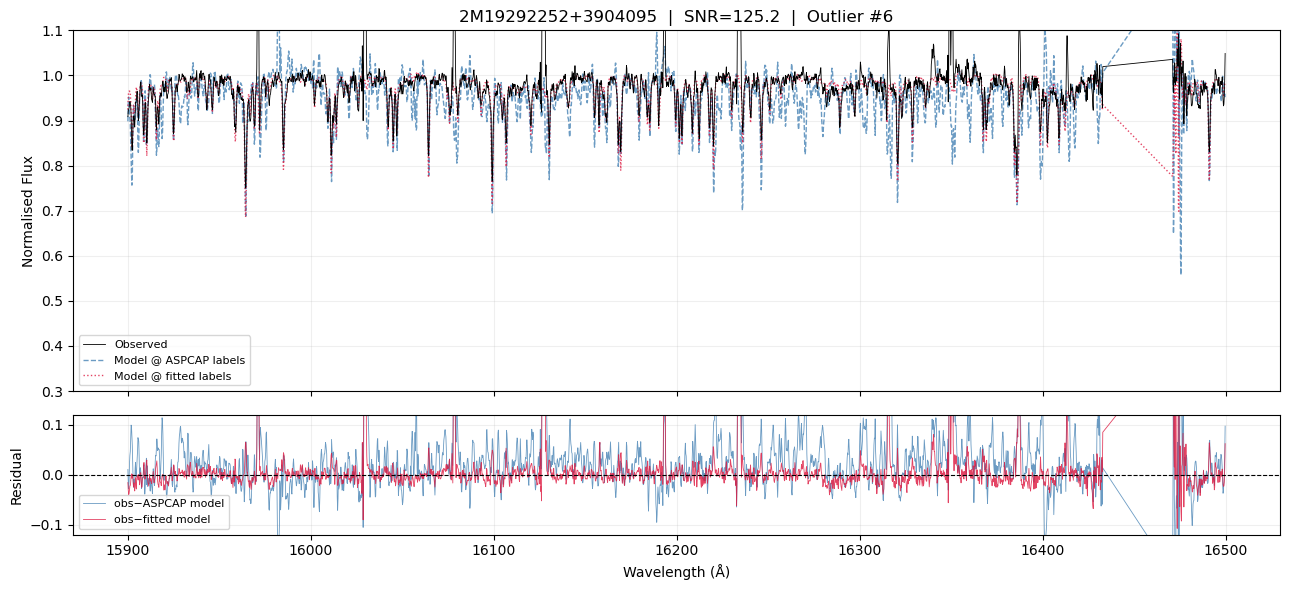

  chi^2 @ original fit  : 21486.0
  chi^2 @ ASPCAP labels : 186384.5
  chi^2 @ best re-fit   : 21485.7
  chi^2 spread (20 starts): 0.09
  Label spread across starts: teff:0.104  logg:0.002  fe_h:0.000  mg_fe:0.000  si_fe:0.000
  Flags  : STARFLAG=['NONE']  ASPCAPFLAG=['VMICRO_WARN', 'C_M_WARN']
  VERDICT: CATALOG FLAG: ASPCAP itself flagged this star as unreliable. | NORMALISATION ISSUE: model fits the observed spectrum poorly even at ASPCAP labels, suggesting a bad continuum normalisation rather than a label error.


SUMMARY OF OUTLIER DIAGNOSES

2M21281377+1054307:
  → CATALOG FLAG: ASPCAP itself flagged this star as unreliable.
  → LOCAL MINIMUM: large spread across re-fits suggests the optimizer got stuck; best re-fit may be more reliable.

2M19294176+3747402:
  → CATALOG FLAG: ASPCAP itself flagged this star as unreliable.
  → LOCAL MINIMUM: large spread across re-fits suggests the optimizer got stuck; best re-fit may be more reliable.
  → NORMALISATION ISSUE: model fits the obser

In [20]:
# Now I need to identify the outliers
#
# For each outlier I run three diagnostics:
#
#  -Spectrum quality check
#      Plot the normalised spectrum vs. the model at both the
#      ASPCAP labels and the fitted labels.  A large visual
#      difference between data and the ASPCAP-model suggests a
#      normalization problem.  A large difference between the two
#      model curves suggests a local-minimum problem.
#
#  -Local-minimum check
#      Re-fit the star from 20 randomly scattered starting points
#      and record the chi^2 and best-fit labels for each.  If
#      multiple starts converge to different solutions the
#      optimizer was stuck in a local minimum.
#
#  and then a summary
from scipy.optimize import curve_fit as sp_curve_fit

rng = np.random.default_rng(42)

# Label ranges used for random starts (physical limits)
LABEL_LO = np.array(BOUNDS_LO)
LABEL_HI = np.array(BOUNDS_HI)

def chi2_for_labels(label_vector, norm_flux, norm_error,
                    thetas, s2_all):
    #Compute chi^2 for a label vector given an observed spectru,m
    good = (np.isfinite(norm_flux) & np.isfinite(norm_error)
            & (norm_error > 0) & (norm_error < 1e9))
    f_obs = norm_flux[good]
    tot_var = norm_error[good]**2 + np.clip(s2_all[good], 0, None)
    tot_var = np.clip(tot_var, 1e-12, None)
    f_mod = predict_spectrum(label_vector, thetas, label_means, label_scales)[good]
    return float(np.sum((f_obs - f_mod)**2 / tot_var))


def multistart_fit(norm_flux, norm_error, thetas, s2_all,
                   label_means, label_scales, n_starts=20):
    """
    Re-fit a spectrum from n_starts random starting points plus the
    training-set mean.  Returns a list of (chi2, labels) tuples,
    sorted by chi2 (best first).
    """
    results = []
    starts = [label_means.copy()]   # always try the mean first

    # Random starts drawn uniformly from physical label range
    for _ in range(n_starts - 1):
        p = rng.uniform(LABEL_LO, LABEL_HI)
        starts.append(p)

    good = (np.isfinite(norm_flux) & np.isfinite(norm_error)
            & (norm_error > 0) & (norm_error < 1e9))
    f_obs = norm_flux[good]
    tot_sig = np.sqrt(norm_error[good]**2 + np.clip(s2_all[good], 0, None))
    tot_sig = np.clip(tot_sig, 1e-6, None)
    thetas_good = thetas[good]
    dummy_x = np.zeros(good.sum())

    def model_func(dummy, teff, logg, feh, mgfe, sife):
        l_arr = np.array([[teff, logg, feh, mgfe, sife]])
        l_vec = make_design_matrix(l_arr, label_means, label_scales)[0]
        return thetas_good @ l_vec

    for p0 in starts:
        try:
            popt, _ = sp_curve_fit(
                model_func, dummy_x, f_obs,
                p0=p0, sigma=tot_sig, absolute_sigma=True,
                method='trf', bounds=(BOUNDS_LO, BOUNDS_HI),
                ftol=1e-4, xtol=1e-4, max_nfev=5000
            )
            c2 = chi2_for_labels(popt, norm_flux, norm_error, thetas, s2_all)
            results.append((c2, popt))
        except Exception:
            pass

    results.sort(key=lambda x: x[0])
    return results


# Limit to the worst N_SHOW outliers to keep runtime manageable
# Rank by the maximum absolute normalised residual across all labels
norm_resid = np.max(
    np.abs(residuals_all[outlier_idx]) /
    np.array([scatter_thresholds[l] for l in LABEL_NAMES]),
    axis=1
)
rank_order  = np.argsort(norm_resid)[::-1]
N_SHOW      = min(6, len(outlier_idx))   # inspect up to 6 outliers
top_outliers = outlier_idx[rank_order[:N_SHOW]]

print(f"Diagnosing {N_SHOW} worst outliers (20 random re-fits each)...\n")

verdicts = []

for rank, idx in enumerate(top_outliers):
    aid     = decode_id(val_labels.iloc[idx]['apogee_id'])
    snr     = val_labels.iloc[idx]['snr']
    lab_asp = aspcap_all[idx]
    lab_fit = fitted_all[idx]
    obs_f   = val_flux[idx].astype(float)
    obs_e   = val_error[idx].astype(float)

    print(f"{'='*70}")
    print(f"Outlier #{rank+1}: {aid}  (SNR={snr:.1f})")
    print(f"  ASPCAP : Teff={lab_asp[0]:.0f}  logg={lab_asp[1]:.2f}  "
          f"[Fe/H]={lab_asp[2]:.3f}  [Mg/Fe]={lab_asp[3]:.3f}  "
          f"[Si/Fe]={lab_asp[4]:.3f}")
    print(f"  Fitted : Teff={lab_fit[0]:.0f}  logg={lab_fit[1]:.2f}  "
          f"[Fe/H]={lab_fit[2]:.3f}  [Mg/Fe]={lab_fit[3]:.3f}  "
          f"[Si/Fe]={lab_fit[4]:.3f}")
    resid_str = "  ".join(
        f"{LABEL_NAMES[j]}:{residuals_all[idx,j]:+.3f}" for j in range(5)
    )
    print(f"  Residuals: {resid_str}")

    # ---- (A) Spectrum diagnostic plot ----
    wave_plot  = (wavelengths >= 15900) & (wavelengths <= 16500)
    w= wavelengths[wave_plot]
    f_obs_plot = obs_f[wave_plot]
    f_asp_plot = predict_spectrum(lab_asp, thetas, label_means, label_scales)[wave_plot]
    f_fit_plot = predict_spectrum(lab_fit, thetas, label_means, label_scales)[wave_plot]
    finite = np.isfinite(f_obs_plot)

    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1]})

    axes[0].plot(w[finite], f_obs_plot[finite],
                 color='black', lw=0.6, label='Observed', zorder=3)
    axes[0].plot(w[finite], f_asp_plot[finite],
                 color='steelblue', lw=1.0, ls='--', alpha=0.8,
                 label='Model @ ASPCAP labels', zorder=2)
    axes[0].plot(w[finite], f_fit_plot[finite],
                 color='crimson', lw=1.0, ls=':', alpha=0.8,
                 label='Model @ fitted labels', zorder=2)
    axes[0].set_ylabel('Normalised Flux')
    axes[0].set_title(f'{aid}  |  SNR={snr:.1f}  |  Outlier #{rank+1}')
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0.3, 1.1)
    axes[0].grid(True, alpha=0.2)

    # Residual panels: obs - model@ASPCAP and obs - model@fitted
    axes[1].plot(w[finite], (f_obs_plot - f_asp_plot)[finite],
                 color='steelblue', lw=0.6, alpha=0.8, label='obs−ASPCAP model')
    axes[1].plot(w[finite], (f_obs_plot - f_fit_plot)[finite],
                 color='crimson',   lw=0.6, alpha=0.8, label='obs−fitted model')
    axes[1].axhline(0, color='black', lw=0.8, ls='--')
    axes[1].set_ylim(-0.12, 0.12)
    axes[1].set_ylabel('Residual')
    axes[1].set_xlabel('Wavelength (Å)')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(f"outlier_{rank+1}_{aid}_spectrum.png", dpi=150)
    plt.show()

    # Multi-start re-fit 
    results = multistart_fit(obs_f, obs_e, thetas, s2_all,
                             label_means, label_scales, n_starts=20)

    chi2_original = chi2_for_labels(lab_fit, obs_f, obs_e, thetas, s2_all)
    chi2_aspcap   = chi2_for_labels(lab_asp, obs_f, obs_e, thetas, s2_all)

    if results:
        best_chi2, best_labels = results[0]
        chi2_spread = np.std([r[0] for r in results])
        label_spread = np.std([r[1] for r in results], axis=0)
    else:
        best_chi2, best_labels = chi2_original, lab_fit
        chi2_spread, label_spread = 0.0, np.zeros(5)

    print(f"  chi^2 @ original fit  : {chi2_original:.1f}")
    print(f"  chi^2 @ ASPCAP labels : {chi2_aspcap:.1f}")
    print(f"  chi^2 @ best re-fit   : {best_chi2:.1f}")
    print(f"  chi^2 spread (20 starts): {chi2_spread:.2f}")
    spread_str = "  ".join(
        f"{LABEL_NAMES[j]}:{label_spread[j]:.3f}" for j in range(5)
    )
    print(f"  Label spread across starts: {spread_str}")

    # The final verdict!
    # Flags for this star if the query succeeded    
    flag_note = ""
    if flag_df is not None and aid in flag_df['apogee_id'].values:
        frow = flag_df[flag_df['apogee_id'] == aid].iloc[0]
        sf = decode_flags(frow['starflag'],   STARFLAG_BITS)
        acf = decode_flags(frow['aspcapflag'], ASPCAPFLAG_BITS)
        has_bad_flag = any('BAD' in f or 'WARN' in f for f in acf + sf)
        flag_note = f"STARFLAG={sf}  ASPCAPFLAG={acf}"
    else:
        has_bad_flag = False

    local_min = chi2_spread > 50 or label_spread.max() > 0.3 * (LABEL_HI - LABEL_LO).max()
    norm_problem  = chi2_aspcap > 2.0 * chi2_original   # ASPCAP labels fit poorly too
    low_snr = snr < 70

    verdict = []
    if has_bad_flag:
        verdict.append("CATALOG FLAG: ASPCAP itself flagged this star as unreliable.")
    if local_min:
        verdict.append("LOCAL MINIMUM: large spread across re-fits suggests the "
                       "optimizer got stuck; best re-fit may be more reliable.")
    if norm_problem:
        verdict.append("NORMALISATION ISSUE: model fits the observed spectrum "
                       "poorly even at ASPCAP labels, suggesting a bad continuum "
                       "normalisation rather than a label error.")
    if low_snr:
        verdict.append(f"LOW SNR ({snr:.1f}): noisy spectrum makes label recovery harder.")
    if not verdict:
        verdict.append("No obvious single cause; likely edge of training label space "
                       "or mild label degeneracy.")

    print(f"  Flags  : {flag_note if flag_note else 'not retrieved'}")
    print(f"  VERDICT: {' | '.join(verdict)}")
    verdicts.append((aid, verdict))
    print()

# ---- Final summary ----
print("\n" + "="*70)
print("SUMMARY OF OUTLIER DIAGNOSES")
print("="*70)
for aid, v in verdicts:
    print(f"\n{aid}:")
    for line in v:
        print(f"  → {line}")

In [21]:
#Defines the directory path as a variable
MIST_DIR = '/Users/hjugan/Desktop/School/2026/Spring/ASTRON 128/astro_128_labs/lab2/mist_isochrones'

# Maps specific file names to their corresponding metallicity values
FILE_MAP = {
     0.0: "MIST_iso_69d6fa0a1066e.iso",
    -1.0: "MIST_iso_69d6fa33a5e2d.iso"
}

# age for isochrone extraction
AGE_GYR = 6.0
isochrones = {}

def load_mist_fast(filepath):
    
    #parse MIST file into pandas df
    #  Extract the exact column names from the file header
    cols = None
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('# EEP'):
                cols = line.lstrip('#').strip().split()
                break
                
    if cols is None:
        raise ValueError(f"No '# EEP' header found in {filepath}")
        

    df = pd.read_csv(filepath, delim_whitespace=True, comment='#', names=cols)
    
    # convert log t_eff to linear temperature.
    df['Teff'] = 10.0 ** df['log_Teff']
    return df

# Iterates over the mapped files to load and filter the exact 6 Gyr age slice.
for feh, fname in FILE_MAP.items():
    fpath = os.path.join(MIST_DIR, fname)
    print(f"Loading [Fe/H] = {feh:+.2f} from {fname}...")
    
    try:
        df_full = load_mist_fast(fpath) #Execute the fast-loading function on the current file path.
        log_target = np.log10(AGE_GYR * 1e9)# convert time to log space
        unique_ages = np.unique(df_full['log10_isochrone_age_yr'].values)
        closest = unique_ages[np.argmin(np.abs(unique_ages - log_target))]
        
        mask = np.abs(df_full['log10_isochrone_age_yr'] - closest) < 1e-6
        isochrones[feh] = df_full[mask].copy()   # Filter the dataset to isolate rows matching the target age.

        
        print(f"  -> Success: Extracted {len(isochrones[feh])} points for 6 Gyr.")
    except Exception as e:
        print(f"  -> ERROR processing {fname}: {e}")

Loading [Fe/H] = +0.00 from MIST_iso_69d6fa0a1066e.iso...
  -> Success: Extracted 1415 points for 6 Gyr.
Loading [Fe/H] = -1.00 from MIST_iso_69d6fa33a5e2d.iso...
  -> Success: Extracted 1397 points for 6 Gyr.


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_21829/2549767502.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, comment='#', names=cols)
/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_21829/2549767502.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, delim_whitespace=True, comment='#', names=cols)


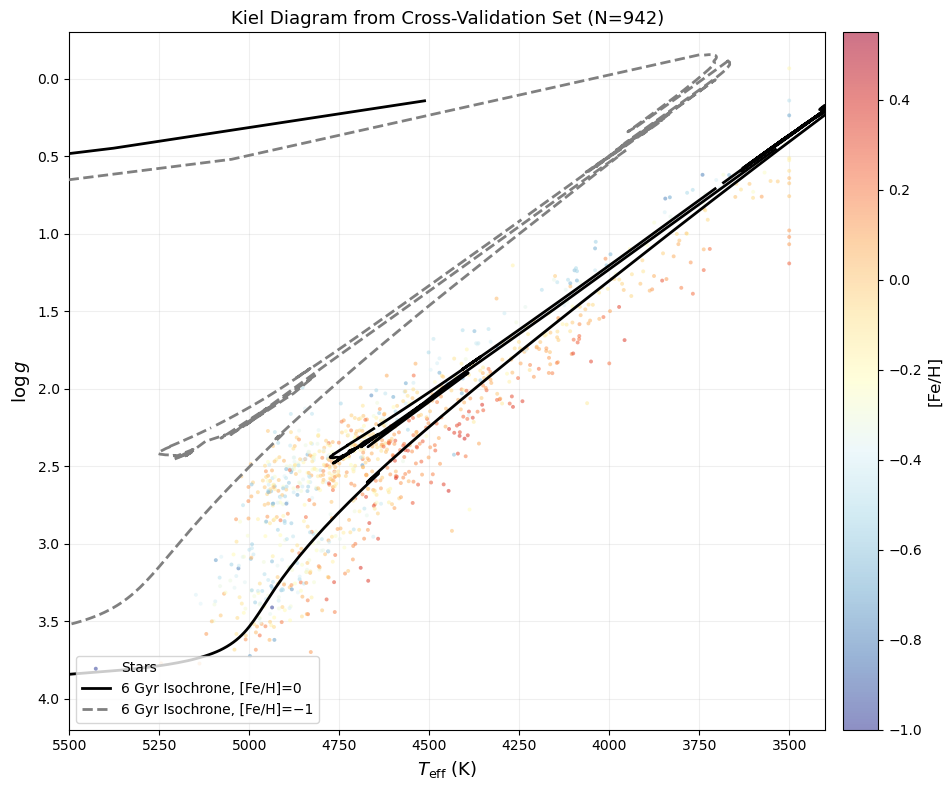

Summary:
N stars plotted : 942
Teff range      : 3500 – 5246 K
log g range     : -0.07 – 3.77
[Fe/H] range    : -0.97 – 0.40

At red clump log g (2.0–2.8):
  Metal-rich ([Fe/H]>-0.3) median Teff : 4678 K (N=393)
  Metal-poor ([Fe/H]<-0.5) median Teff : 4881 K (N=35)


In [22]:
# Extract the fitted stellar parameters from the master array
teff_fit = fitted_all[:, 0]
logg_fit = fitted_all[:, 1]
feh_fit  = fitted_all[:, 2]

feh_min, feh_max = -1.0, 0.55
cmap = plt.cm.RdYlBu_r #color map
norm = plt.Normalize(vmin=feh_min, vmax=feh_max)
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the fitted stellar data.
sc = ax.scatter(
    teff_fit, logg_fit,
    c=feh_fit, cmap=cmap, norm=norm,
    s=8, alpha=0.55, linewidths=0,
    rasterized=True, zorder=2,
    label=f'Stars'
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('[Fe/H]', fontsize=12)

iso_styles = {
     0.0: dict(color='black', ls='-',  lw=2.0, label=r'6 Gyr Isochrone, [Fe/H]=0'),
    -1.0: dict(color='gray',  ls='--', lw=2.0, label=r'6 Gyr Isochrone, [Fe/H]=−1'),
}


for feh, style in iso_styles.items():# Iterates through the loaded isochrone data to overlay the tracks
    df_iso = isochrones.get(feh)
    if df_iso is None:
        continue

    mask = (df_iso['log_g'] < 4.0) & (df_iso['Teff'] > 3400)
    df_plot = df_iso[mask]

    # Segments the plotting routine by evolutionary phase
    if 'phase' in df_plot.columns:
        for phase_val, grp in df_plot.groupby('phase', sort=False):
            ax.plot(grp['Teff'], grp['log_g'],
                    zorder=5, **{k: v for k, v in style.items() if k != 'label'})
        # Adds a single legend element per metallicity track.
        ax.plot([], [], **style)
    else:
        ax.plot(df_plot['Teff'], df_plot['log_g'], zorder=5, **style)

# formatting
ax.set_xlim(5500, 3400)           
ax.set_ylim(4.2, -0.3)            
ax.set_xlabel(r'$T_{\rm eff}$ (K)', fontsize=13)
ax.set_ylabel(r'$\log g$', fontsize=13)
ax.set_title(f'Kiel Diagram from Cross-Validation Set (N={len(teff_fit)})', fontsize=13)

"""feature_annotations = [
    (4700, 2.35, 'Red Clump', 'left'),
    (4000, 0.7,  'RGB Tip', 'left'),
    (4600, 2.9,  'Red Giant Branch', 'right'),
]

for xt, yg, txt, ha in feature_annotations:
    ax.annotate(
        txt, xy=(xt, yg),
        fontsize=10, ha=ha, color='dimgray',
        arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8),
        xytext=(xt + (200 if ha == 'left' else -200), yg + 0.15),
    )"""

# more formattiung
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("kiel_diagram.png", dpi=300)
plt.show()

# Statistical Validation & Summary

print("Summary:")
print(f"N stars plotted : {len(teff_fit)}")
print(f"Teff range      : {teff_fit.min():.0f} – {teff_fit.max():.0f} K")
print(f"log g range     : {logg_fit.min():.2f} – {logg_fit.max():.2f}")
print(f"[Fe/H] range    : {feh_fit.min():.2f} – {feh_fit.max():.2f}")

# Computes the median temperature offset between metal-rich and metal-poor stars at the Red Clump in order to numerically verify the theoretical prediction that lower metallicity decreases atmospheric opacity, resulting in higher surface temperatures at fixed surface gravity.
clump_mask = (logg_fit > 2.0) & (logg_fit < 2.8)
if clump_mask.sum() > 10:
    rich_mask = clump_mask & (feh_fit > -0.3)
    poor_mask = clump_mask & (feh_fit < -0.5)
    
    if rich_mask.sum() > 5 and poor_mask.sum() > 5:
        print(f"\nAt red clump log g (2.0–2.8):")
        print(f"  Metal-rich ([Fe/H]>-0.3) median Teff : {np.median(teff_fit[rich_mask]):.0f} K (N={rich_mask.sum()})")
        print(f"  Metal-poor ([Fe/H]<-0.5) median Teff : {np.median(teff_fit[poor_mask]):.0f} K (N={poor_mask.sum()})")

Found: ./mystery_spec_wiped.fits

FITS file structure:
  HDU 0: PRIMARY               shape=no data  dtype=N/A
  HDU 1:                       shape=(8575,)  dtype=>f4
  HDU 2:                       shape=(8575,)  dtype=>f4
  HDU 3:                       shape=(8575,)  dtype=>i2
  HDU 4:                       shape=(8575,)  dtype=>f4
  HDU 5:                       shape=(8575,)  dtype=>f4
  HDU 6:                       shape=(8575,)  dtype=>f4
  HDU 7:                       shape=(8575,)  dtype=>f4
  HDU 8:                       shape=(26,)  dtype=>f8
  HDU 9:                       shape=(1,)  dtype=(numpy.record, [('FILE', 'S30'), ('FIBER', '>i2'), ('PLATE', 'S4'), ('MJD', '>i4'), ('LOCID', '>i2'), ('JD', '>f8'), ('VREL', '>f4'), ('VRELERR', '>f4'), ('VHELIO', '>f4'), ('BC', '>f4'), ('BINARY', '>i2', (2,)), ('STABLERV_CHI2', '>f4', (2,)), ('STABLERV_RCHI2', '>f4', (2,)), ('CHI2_THRESHOLD', '>f4', (2,)), ('STABLERV_CHI2_PROB', '>f4', (2,)), ('TEFF', '>f4'), ('LOGG', '>f4'), ('FEH', '>f4

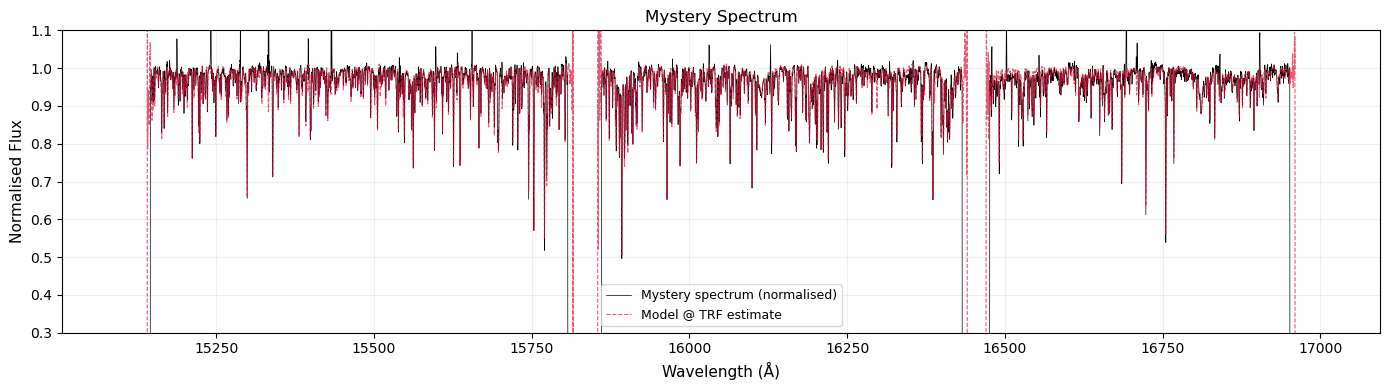

In [23]:
# Use a dedicated loader instead of clean_spectrum, because themystery FITS file may have a different HDU layout than apStar.
# The loader inspects whatever structure it finds and makes writeable copies of every array before modifying them.
import glob
from astropy.io import fits

CANDIDATE_NAMES = [
    "mystery_spectrum.fits",
    "mystery_spectrum.npy",
    "mystery_spectrum.npz",
    "mysterystar.fits",
    "mystery.fits",
]

SEARCH_DIRS = [".", SPECTRA_DIR]

mystery_path = None
for d in SEARCH_DIRS:
    for name in CANDIDATE_NAMES:
        p = os.path.join(d, name)
        if os.path.exists(p):
            mystery_path = p
            break
    if mystery_path:
        break

if mystery_path is None:
    candidates = (glob.glob("./*mystery*.fits") +
                  glob.glob("./*mystery*.npy")  +
                  glob.glob("./*mystery*.npz"))
    if candidates:
        mystery_path = candidates[0]

if mystery_path is None:
    raise FileNotFoundError(
        "Could not find the mystery spectrum.\n"
        "Place it in the working directory and set mystery_path manually:\n"
        "    mystery_path = '/path/to/mystery_spectrum.fits'"
    )

print(f"Found: {mystery_path}")
ext = os.path.splitext(mystery_path)[1].lower()


def load_mystery_fits(path):
    """
    load flux, error, and bitmask from a mystery FITS file

    My process is as follows:
      - Print a summary of every HDU to see what's inside
      - Try the standard apStar layout (HDU 1/2/3).
      - Fall back to searching all image HDUs by shape.
      - Always return writeable float64 copies — never views into memory-mapped arrays which were causing a float32 assignment error to get raised
    """
    with fits.open(path, memmap=False) as hdul:
        print("\nFITS file structure:")
        for i, hdu in enumerate(hdul):
            shape = hdu.data.shape if hdu.data is not None else "no data"
            print(f"  HDU {i}: {hdu.name:<20}  shape={shape}  "
                  f"dtype={hdu.data.dtype if hdu.data is not None else 'N/A'}")

        N_pix_expected = len(wavelengths)   # 8575

        flux_raw= None
        error_raw = None
        bitmask_raw = None

        # First attempt: standard apStar layout 
        try:
            d1 = hdul[1].data
            if d1 is not None:
                # apStar stores multiple visits as rows; row 0 is the coadd
                if d1.ndim == 2 and d1.shape[1] == N_pix_expected:
                    flux_raw = np.array(d1[0], dtype=float)   # writeable copy
                elif d1.ndim == 1 and d1.shape[0] == N_pix_expected:
                    flux_raw = np.array(d1,    dtype=float)

            d2 = hdul[2].data
            if d2 is not None:
                if d2.ndim == 2 and d2.shape[1] == N_pix_expected:
                    error_raw = np.array(d2[0], dtype=float)
                elif d2.ndim == 1 and d2.shape[0] == N_pix_expected:
                    error_raw = np.array(d2,    dtype=float)

            d3 = hdul[3].data
            if d3 is not None:
                if d3.ndim == 2 and d3.shape[1] == N_pix_expected:
                    bitmask_raw = np.array(d3[0], dtype=np.int32)
                elif d3.ndim == 1 and d3.shape[0] == N_pix_expected:
                    bitmask_raw = np.array(d3,    dtype=np.int32)

        except (IndexError, AttributeError):
            pass   # fewer than 3 HDUs — fall through to attempt 2

        # 2nd attempt: search all HDUs by shape 
        if flux_raw is None:
            print("\n  Standard apStar layout not found — scanning all HDUs...")
            candidates_found = []
            for i, hdu in enumerate(hdul):
                d = hdu.data
                if d is None:
                    continue
                # Flatten to 1-D if it's a single-row 2-D array
                if d.ndim == 2 and d.shape[0] == 1:
                    d = d[0]
                if d.ndim == 1 and d.shape[0] == N_pix_expected:
                    candidates_found.append((i, np.array(d, dtype=float)))

            if len(candidates_found) == 0:
                raise ValueError(
                    f"No HDU with {N_pix_expected} pixels found in {path}.\n"
                    "Check the FITS structure printout above."
                )

            # Assign in order: first -> flux, second -> error (if available)
            flux_raw  = candidates_found[0][1]
            if len(candidates_found) >= 2:
                error_raw = candidates_found[1][1]
                print(f"  Assigned HDU {candidates_found[0][0]} → flux")
                print(f"  Assigned HDU {candidates_found[1][0]} → error")
            else:
                print(f"  Assigned HDU {candidates_found[0][0]} → flux")
                print("  No separate error HDU found — using flat 1% error")

        # apply bitmask to writeable copies
        flux_out  = np.array(flux_raw,  dtype=float)   # guaranteed writeable
        if error_raw is not None:
            error_out = np.array(error_raw, dtype=float)
        else:
            error_out = np.full(N_pix_expected, 0.01, dtype=float)

        if bitmask_raw is not None:
            bits_0_to_7  = 255
            bit_12       = 1 << 12
            critical_flags = bits_0_to_7 | bit_12
            bad = (bitmask_raw & critical_flags) != 0
            error_out[bad] = 1e10
            print(f"\n  Bad pixels flagged via bitmask: {bad.sum()}")
        else:
            # No bitmask available — flag NaN / negative / zero flux pixels
            bad = ~np.isfinite(flux_out) | (flux_out <= 0)
            error_out[bad] = 1e10
            print(f"\n  No bitmask found — flagged {bad.sum()} "
                  "non-finite/non-positive pixels")

        # quality report
        n_bad   = (error_out >= 1e9).sum()
        n_good  = N_pix_expected - n_bad
        print(f"  Total pixels : {N_pix_expected}")
        print(f"  Good pixels  : {n_good}")
        print(f"  Bad / flagged: {n_bad}")

        return flux_out, error_out


#load depending on file type
if ext == '.fits':
    mystery_flux_raw, mystery_error_raw = load_mystery_fits(mystery_path)
    mystery_norm_flux, mystery_norm_error, mystery_continuum = normalize_spectrum(
        wavelengths, mystery_flux_raw, mystery_error_raw, continuum_mask_formatted
    )
    print("\nNormalization complete.")

elif ext == '.npy':
    arr = np.load(mystery_path)
    arr = np.array(arr, dtype=float)   # writeable copy
    if arr.ndim == 1:
        mystery_norm_flux  = arr
        mystery_norm_error = np.full_like(arr, 0.01)
    else:
        mystery_norm_flux  = arr[0]
        mystery_norm_error = arr[1]

elif ext == '.npz':
    arc  = np.load(mystery_path)
    keys = list(arc.files)
    print(f"Keys: {keys}")
    mystery_norm_flux  = np.array(arc[keys[0]], dtype=float)
    mystery_norm_error = (np.array(arc[keys[1]], dtype=float)
                          if len(keys) > 1
                          else np.full_like(mystery_norm_flux, 0.01))
else:
    raise ValueError(f"Unrecognised extension: {ext}")

# TRF estimate to seed MCMC chains 
print("\nGetting TRF starting-point for MCMC initialisation...")
p0_mystery, perr_mystery = fit_labels_trf(
    mystery_norm_flux, mystery_norm_error,
    thetas, s2_all, label_means, label_scales
)

if p0_mystery is not None:
    print("TRF estimate:")
    for lname, val, err in zip(LABEL_NAMES, p0_mystery, perr_mystery):
        print(f"  {lname:<8} = {val:+.3f}  ± {err:.3f}")
else:
    p0_mystery = label_means.copy()
    perr_mystery = np.zeros(5)
    print("TRF did not converge — initialising MCMC at label means.")

# plot
fig, ax = plt.subplots(figsize=(14, 4))
finite = np.isfinite(mystery_norm_flux)
ax.plot(wavelengths[finite], mystery_norm_flux[finite],
        color='black', lw=0.5, label='Mystery spectrum (normalised)')
if p0_mystery is not None:
    f_trf = predict_spectrum(p0_mystery, thetas, label_means, label_scales)
    ax.plot(wavelengths[finite], f_trf[finite],
            color='crimson', lw=0.8, ls='--', alpha=0.7,
            label='Model @ TRF estimate')
ax.set_xlabel('Wavelength (Å)', fontsize=11)
ax.set_ylabel('Normalised Flux',  fontsize=11)
ax.set_title('Mystery Spectrum', fontsize=12)
ax.set_ylim(0.3, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("mystery_spectrum.png", dpi=200)
plt.show()

In [24]:
# MCMC with properly scaled proposals
#
#  I was struggling with low acceptance rates so I asked gemini why that might be and it gave me a really helpful explanation which is as follows:
#   The posterior is very narrow because thousands of spectral pixels constrain the labels tightly. The initial proposal scale (5% of prior width) was 5-10x too large, causing almost every proposal to land in a near-zero probabilit region. The fix is to seed the scale from the TRF covariance estimates, which directly approximate the posterior width, then adapt aggressively from there.
N_TUNE    = 3000    # burn-in / adaptation (discarded)
N_SAMPLES = 15000    # posterior draws to keep per chain
N_CHAINS  = 3

PRIOR_LO = np.array(BOUNDS_LO, dtype=float)
PRIOR_HI = np.array(BOUNDS_HI, dtype=float)

# Initial proposal scale
# For a d-dimensional Gaussian target the optimal MH step size is
#   sigma_proposal = (2.38 / √d) × sigma_posterior
# I used the TRF uncertainty estimates as a best guess for sigma_posterior.  This was if TRF failed we fall back to 0.5% of prior width, which is ~10× smaller than the previous default.
d = 5  # number of labels
OPTIMAL_FACTOR = 2.38 / np.sqrt(d)   # ≈ 1.06 for d=5

if perr_mystery is not None and np.all(np.isfinite(perr_mystery)) \
        and np.all(perr_mystery > 0):
    INIT_SCALE = OPTIMAL_FACTOR * perr_mystery
    print("Proposal scale initialised from TRF uncertainty estimates:")
else:
    INIT_SCALE = 0.005 * (PRIOR_HI - PRIOR_LO)
    print("TRF uncertainties unavailable — using 0.5% of prior width:")

for lname, s in zip(LABEL_NAMES, INIT_SCALE):
    print(f"  {lname:<8}  proposal σ = {s:.5f}")


# Precompute likelihood ingredients 
myst_good = (
    np.isfinite(mystery_norm_flux)
    & np.isfinite(mystery_norm_error)
    & (mystery_norm_error > 0)
    & (mystery_norm_error < 1e9)
)

f_myst_good = mystery_norm_flux[myst_good]
thetas_myst = thetas[myst_good]
total_var_myst = (mystery_norm_error[myst_good]**2
                  + np.clip(s2_all[myst_good], 0, None))
total_var_myst = np.clip(total_var_myst, 1e-12, None)
log_norm       = -0.5 * np.sum(np.log(2 * np.pi * total_var_myst))

print(f"\nPixels used in likelihood: {myst_good.sum()} / {len(mystery_norm_flux)}")


def log_prior(labels):
    if np.any(labels < PRIOR_LO) or np.any(labels > PRIOR_HI):
        return -np.inf
    return 0.0


def log_likelihood(labels):
    l_vec   = make_design_matrix(
                  np.asarray(labels).reshape(1, -1),
                  label_means, label_scales
              )[0]
    f_model = thetas_myst @ l_vec
    chi2    = np.sum((f_myst_good - f_model)**2 / total_var_myst)
    return float(log_norm - 0.5 * chi2)


def log_posterior(labels):
    lp = log_prior(labels)
    return -np.inf if not np.isfinite(lp) else lp + log_likelihood(labels)


def run_chain(p0, n_tune, n_samples, init_scale, chain_id=0, seed=0):
    """
    Adaptive Metropolis-Hastings chain.

    Adaptation strategy:
      - Check acceptance every ADAPT_INTERVAL steps during tuning
      - Scale multiplied / divided by ADAPT_FACTOR aggressively
      - Target acceptance window: 20–35%
      - After tuning, freeze scale and collect posterior samples
    """
    ADAPT_INTERVAL = 50      # check acceptance rate frequently
    TARGET_LO      = 0.20
    TARGET_HI      = 0.35

    rng   = np.random.default_rng(seed)
    scale = init_scale.copy()

    # Clip starting point strictly inside prior
    current = np.clip(p0, PRIOR_LO + 1e-6, PRIOR_HI - 1e-6)
    current_logp = log_posterior(current)

    if not np.isfinite(current_logp):
        current      = np.clip(label_means, PRIOR_LO + 1e-6, PRIOR_HI - 1e-6)
        current_logp = log_posterior(current)

    # Burn-in
    n_accept_window = 0

    for t in range(n_tune):
        proposal  = current + rng.normal(0, scale)
        prop_logp = log_posterior(proposal)

        if np.log(rng.uniform() + 1e-300) < (prop_logp - current_logp):
            current      = proposal
            current_logp = prop_logp
            n_accept_window += 1

        if (t + 1) % ADAPT_INTERVAL == 0:
            rate = n_accept_window / ADAPT_INTERVAL
            n_accept_window = 0   # reset window counter

            if rate < 0.10:
                scale *= 0.5      # very low — halve the scale
            elif rate < TARGET_LO:
                scale *= 0.80
            elif rate > 0.50:
                scale *= 2.0      # very high — double the scale
            elif rate > TARGET_HI:
                scale *= 1.25

            # Never let scale shrink below 1/1000 of init or grow
            # beyond 10× init — prevents numerical degeneracy
            scale = np.clip(scale, init_scale * 1e-3, init_scale * 10)

    # Acceptance rate over the last tuning window
    print(f"  Chain {chain_id}  |  final proposal σ: "
          f"{np.round(scale, 5)}")

    # Sampling phase 
    chain    = np.empty((n_samples, len(p0)))
    n_accept = 0

    for s in range(n_samples):
        proposal  = current + rng.normal(0, scale)
        prop_logp = log_posterior(proposal)

        if np.log(rng.uniform() + 1e-300) < (prop_logp - current_logp):
            current      = proposal
            current_logp = prop_logp
            n_accept     += 1

        chain[s] = current

    return chain, n_accept / n_samples


#  Run all chains 
print(f"\nRunning {N_CHAINS} chains  "
      f"({N_TUNE} tune + {N_SAMPLES} sample steps each)...")
print("Expected runtime: ~5–12 minutes\n")

rng_seeds  = [42 + i * 100 for i in range(N_CHAINS)]
all_chains = []
accept_rates = []

for c in range(N_CHAINS):
    jitter   = np.random.default_rng(rng_seeds[c]).normal(
                    0, INIT_SCALE * 0.1)
    p0_chain = np.clip(p0_mystery + jitter,
                       PRIOR_LO + 1e-6, PRIOR_HI - 1e-6)

    chain, rate = run_chain(
        p0_chain, N_TUNE, N_SAMPLES, INIT_SCALE,
        chain_id=c, seed=rng_seeds[c]
    )
    all_chains.append(chain)
    accept_rates.append(rate)
    print(f"  Chain {c}  |  sampling acceptance: {rate:.3f}")

samples_arr = np.vstack(all_chains)
print(f"\nTotal posterior samples: {len(samples_arr)}")


# Diagnostics 
def gelman_rubin(chains_list):
    chains = np.stack(chains_list, axis=0)
    M, n, K = chains.shape
    rhat = np.zeros(K)
    for k in range(K):
        c_k = chains[:, :, k]
        W   = c_k.var(axis=1, ddof=1).mean()
        B   = n * c_k.mean(axis=1).var(ddof=1)
        V   = (n - 1) / n * W + B / n
        rhat[k] = np.sqrt(V / W) if W > 0 else np.nan
    return rhat


def ess_1d(chain_1d):
    n   = len(chain_1d)
    x   = chain_1d - chain_1d.mean()
    acf = np.correlate(x, x, mode='full')[n-1:]
    if acf[0] == 0:
        return float(n)
    acf = acf / acf[0]
    rho = 0.0
    for t in range(0, min(n // 2, 500), 2):
        pair = acf[t] + acf[t + 1]
        if pair <= 0:
            break
        rho += pair
    return n / max(1.0, 1 + 2 * rho)


rhats = gelman_rubin(all_chains)

print("\nConvergence diagnostics:")
print(f"{'Label':<8}  {'Mean':>9}  {'SD':>8}  {'R-hat':>7}  "
      + "  ".join(f"{'ESS ch'+str(c):>10}" for c in range(N_CHAINS)))
print("-" * (40 + 12 * N_CHAINS))

for i, lname in enumerate(LABEL_NAMES):
    mean_val = float(samples_arr[:, i].mean())
    sd_val = float(samples_arr[:, i].std())
    rhat = float(rhats[i])
    ess_vals = [ess_1d(all_chains[c][:, i]) for c in range(N_CHAINS)]
    flag = "  ✓" if rhat < 1.05 else "  ← increase N_SAMPLES"
    ess_str  = "  ".join(f"{e:>10.0f}" for e in ess_vals)
    print(f"{lname:<8}  {mean_val:>9.3f}  {sd_val:>8.4f}  "
          f"{rhat:>7.4f}{flag}  {ess_str}")

print(f"\nAcceptance rates: "
      + "  ".join(f"chain {c}: {r:.3f}" for c, r in enumerate(accept_rates)))
print("Target: 0.20–0.35")
print("\nIf R-hat is still > 1.05, increase N_TUNE to 5000 and re-run.")

Proposal scale initialised from TRF uncertainty estimates:
  teff      proposal σ = 0.88851
  logg      proposal σ = 0.00343
  fe_h      proposal σ = 0.00101
  mg_fe     proposal σ = 0.00118
  si_fe     proposal σ = 0.00103

Pixels used in likelihood: 8575 / 8575

Running 3 chains  (3000 tune + 15000 sample steps each)...
Expected runtime: ~5–12 minutes

  Chain 0  |  final proposal σ: [0.56865 0.00219 0.00064 0.00076 0.00066]
  Chain 0  |  sampling acceptance: 0.199
  Chain 1  |  final proposal σ: [0.55532 0.00214 0.00063 0.00074 0.00064]
  Chain 1  |  sampling acceptance: 0.200
  Chain 2  |  final proposal σ: [0.5823  0.00225 0.00066 0.00078 0.00067]
  Chain 2  |  sampling acceptance: 0.192

Total posterior samples: 45000

Convergence diagnostics:
Label          Mean        SD    R-hat     ESS ch0     ESS ch1     ESS ch2
----------------------------------------------------------------------------
teff       4602.686    0.9198   1.0147  ✓          89         104         113
logg      

=== MCMC posterior summary ===
Label        Median     16th%     84th%    2.5th%    97.5th%     σ_MCMC
------------------------------------------------------------------------
teff       4602.681  4601.766  4603.618  4600.920   4604.492     0.9264
logg          2.058     2.054     2.062     2.051      2.065     0.0036
fe_h         -0.583    -0.584    -0.582    -0.585     -0.581     0.0010
mg_fe         0.222     0.221     0.223     0.220      0.224     0.0009
si_fe         0.113     0.112     0.114     0.111      0.115     0.0009

=== Uncertainty comparison ===
Label        MCMC σ      TRF σ   CV scatter  Verdict
-----------------------------------------------------------------
teff         0.9264     0.8348      64.6070  formal σ underestimates true error
logg         0.0036     0.0032       0.1537  formal σ underestimates true error
fe_h         0.0010     0.0009       0.0439  formal σ underestimates true error
mg_fe        0.0009     0.0011       0.0448  formal σ underestimates true

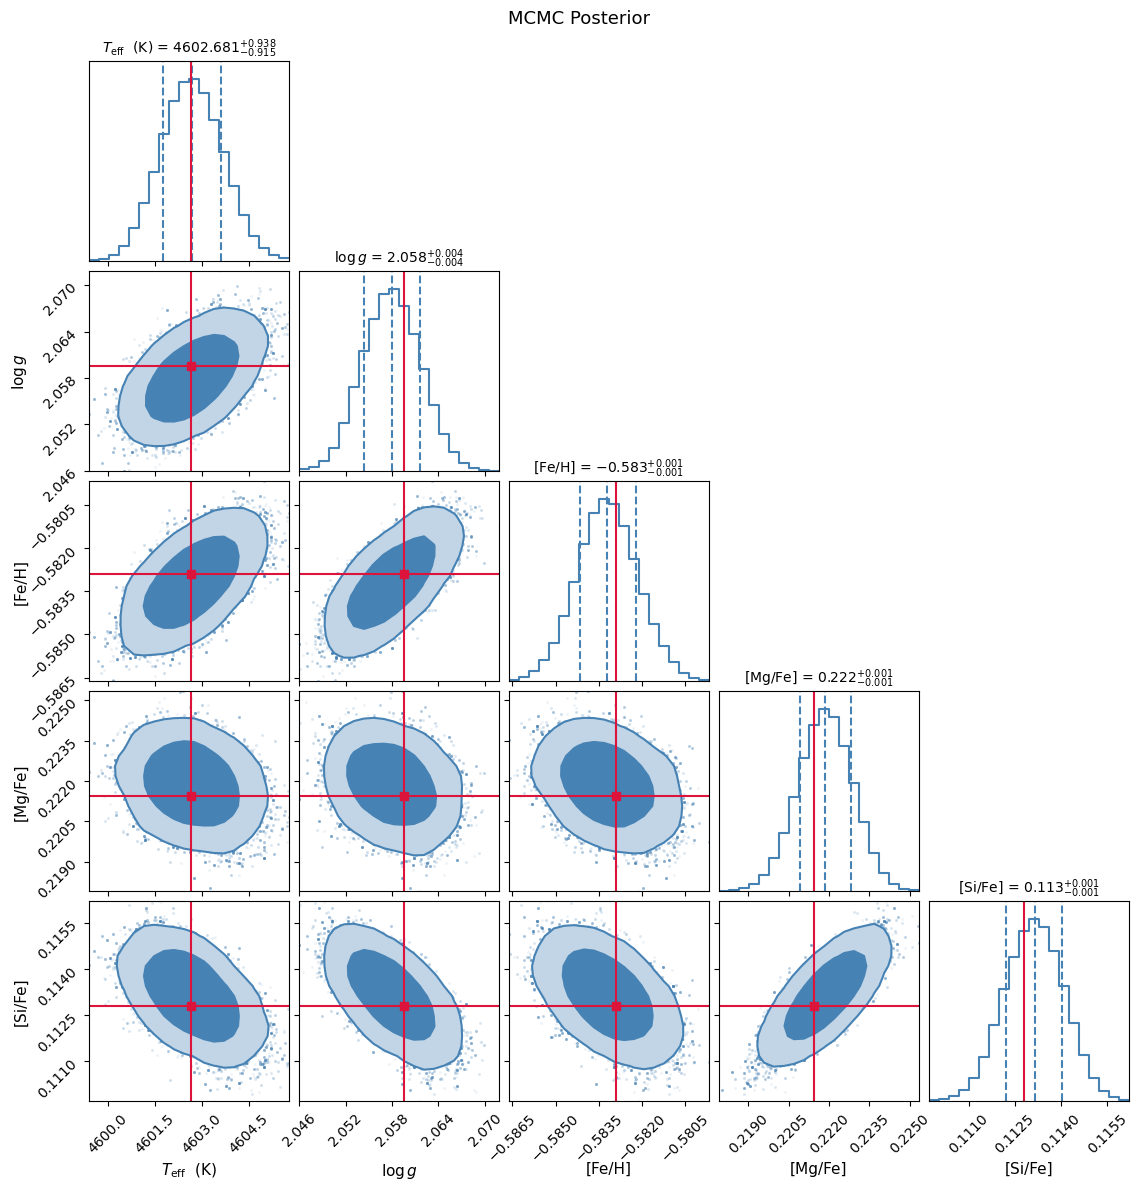

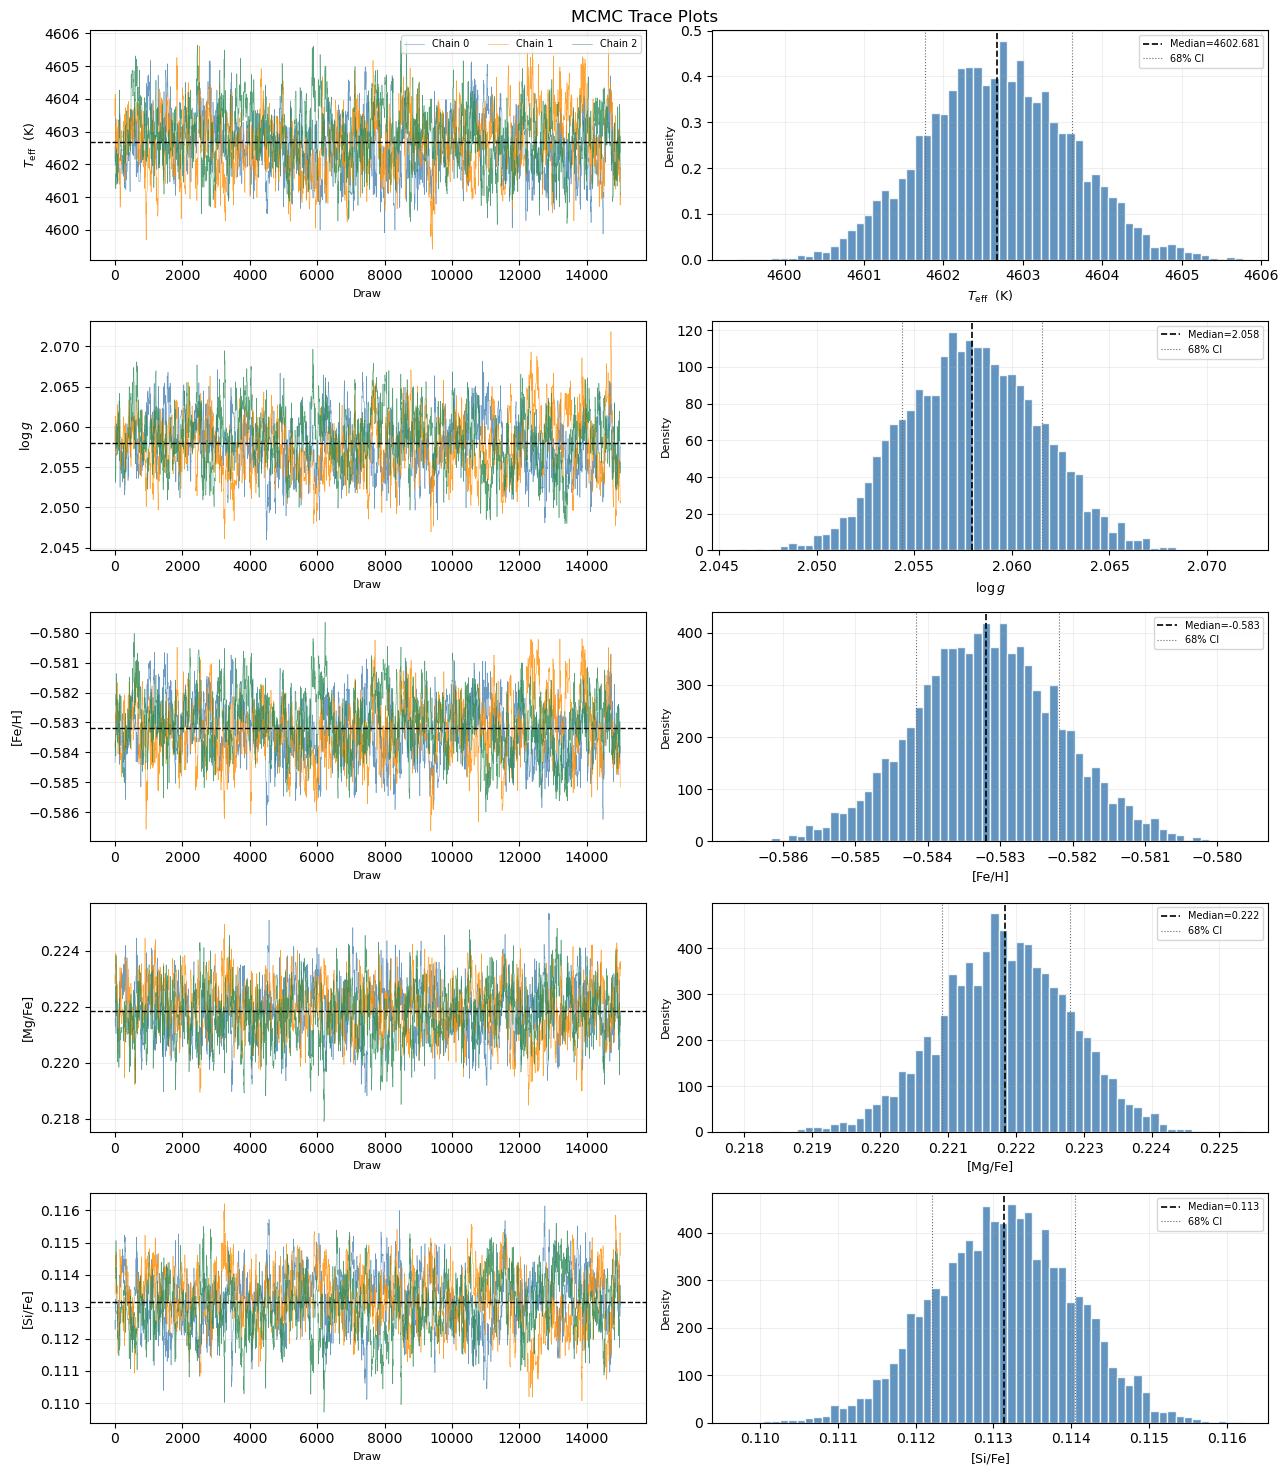

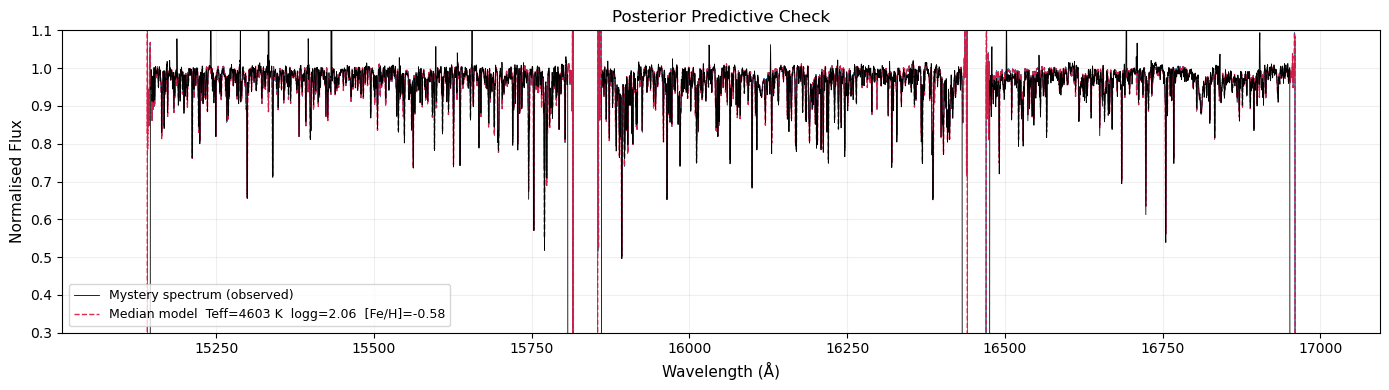

In [25]:
import corner as corner_pkg

#  get MCMC summary stats
medians    = np.median(samples_arr, axis=0)
lo_68      = np.percentile(samples_arr, 16,  axis=0)
hi_68      = np.percentile(samples_arr, 84,  axis=0)
lo_95      = np.percentile(samples_arr,  2.5, axis=0)
hi_95      = np.percentile(samples_arr, 97.5, axis=0)
mcmc_sigma = (hi_68 - lo_68) / 2.0

LABEL_LATEX = [
    r'$T_{\rm eff}$  (K)',
    r'$\log g$',
    r'[Fe/H]',
    r'[Mg/Fe]',
    r'[Si/Fe]',
]

print("=== MCMC posterior summary ===")
print(f"{'Label':<8}  {'Median':>9}  {'16th%':>8}  {'84th%':>8}  "
      f"{'2.5th%':>8}  {'97.5th%':>9}  {'σ_MCMC':>9}")
print("-" * 72)
for i, lname in enumerate(LABEL_NAMES):
    print(f"{lname:<8}  {medians[i]:>9.3f}  {lo_68[i]:>8.3f}  "
          f"{hi_68[i]:>8.3f}  {lo_95[i]:>8.3f}  {hi_95[i]:>9.3f}  "
          f"{mcmc_sigma[i]:>9.4f}")

# ---- 2. Uncertainty comparison ----
cv_scatter = {lname: scatter for lname, _, scatter, _ in stats_rows}

print("\n=== Uncertainty comparison ===")
print(f"{'Label':<8}  {'MCMC σ':>9}  {'TRF σ':>9}  "
      f"{'CV scatter':>11}  Verdict")
print("-" * 65)
for i, lname in enumerate(LABEL_NAMES):
    trf_err = float(perr_mystery[i]) if perr_mystery is not None else np.nan
    cv_err  = cv_scatter.get(lname, np.nan)
    m_sig   = mcmc_sigma[i]
    if m_sig < 0.5 * cv_err:
        verdict = "formal σ underestimates true error"
    elif m_sig > 2.0 * cv_err:
        verdict = "label poorly constrained by this spectrum"
    else:
        verdict = "consistent with CV scatter"
    print(f"{lname:<8}  {m_sig:>9.4f}  {trf_err:>9.4f}  "
          f"{cv_err:>11.4f}  {verdict}")

print("""
  MCMC sigma << CV scatter is the most common finding and is physically
  meaningful. The formal posterior width only accounts for photon
  noise and model scatter at the MAP. It ignores errors in the
  training labels, continuum normalization artifacts, and
  approximations in the quadratic model. These errors inflate
  the CV scatter but do not broaden the posterior. The CV scatter
  is therefore a more honest estimate of the true label uncertainty.
""")

# corner plot
truths = p0_mystery.tolist() if p0_mystery is not None else None

fig = corner_pkg.corner(
    samples_arr,
    labels=LABEL_LATEX,
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt='.3f',
    title_kwargs={'fontsize': 10},
    label_kwargs={'fontsize': 11},
    truths=truths,
    truth_color='crimson',
    color='steelblue',
    hist_kwargs={'linewidth': 1.5},
    plot_contours=True,
    fill_contours=True,
    levels=(0.68, 0.95),
    smooth=1.0,
    smooth1d=1.0,
)
fig.suptitle('MCMC Posterior',fontsize=13, y=1.01)
plt.savefig("mystery_mcmc_corner.png", dpi=200, bbox_inches='tight')
plt.show()

# Trace plot 
fig, axes = plt.subplots(len(LABEL_NAMES), 2,
                          figsize=(13, 3 * len(LABEL_NAMES)))
fig.suptitle('MCMC Trace Plots', fontsize=12)
chain_colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for i, (lname, latex) in enumerate(zip(LABEL_NAMES, LABEL_LATEX)):
    ax_trace = axes[i, 0]
    ax_hist  = axes[i, 1]

    for c, chain in enumerate(all_chains):
        ax_trace.plot(chain[:, i], lw=0.4,
                      color=chain_colors[c % len(chain_colors)],
                      alpha=0.8, label=f'Chain {c}')

    ax_trace.axhline(medians[i], color='black', lw=1.0, ls='--')
    ax_trace.set_ylabel(latex, fontsize=9)
    ax_trace.set_xlabel('Draw', fontsize=8)
    ax_trace.grid(True, alpha=0.2)
    if i == 0:
        ax_trace.legend(fontsize=7, loc='upper right', ncol=N_CHAINS)

    ax_hist.hist(samples_arr[:, i], bins=60,
                 color='steelblue', edgecolor='white',
                 lw=0.3, alpha=0.85, density=True)
    ax_hist.axvline(medians[i], color='black',  lw=1.2, ls='--',
                    label=f'Median={medians[i]:.3f}')
    ax_hist.axvline(lo_68[i],   color='dimgray', lw=0.8, ls=':')
    ax_hist.axvline(hi_68[i],   color='dimgray', lw=0.8, ls=':',
                    label='68% CI')
    ax_hist.set_xlabel(latex,     fontsize=9)
    ax_hist.set_ylabel('Density', fontsize=8)
    ax_hist.legend(fontsize=7)
    ax_hist.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("mystery_mcmc_trace.png", dpi=150, bbox_inches='tight')
plt.show()

#  Posterior predictive check 
fig, ax = plt.subplots(figsize=(14, 4))
finite = np.isfinite(mystery_norm_flux)

ax.plot(wavelengths[finite], mystery_norm_flux[finite],
        color='black', lw=0.6, zorder=5,
        label='Mystery spectrum (observed)')

rng_ppc  = np.random.default_rng(7)
idx_draw = rng_ppc.integers(0, len(samples_arr), size=100)
for idx in idx_draw:
    f_draw = predict_spectrum(samples_arr[idx],
                              thetas, label_means, label_scales)
    ax.plot(wavelengths[finite], f_draw[finite],
            color='steelblue', lw=0.3, alpha=0.08)

f_median = predict_spectrum(medians, thetas, label_means, label_scales)
ax.plot(wavelengths[finite], f_median[finite],
        color='crimson', lw=1.0, ls='--', alpha=0.9,
        label=(f'Median model  Teff={medians[0]:.0f} K  '
               f'logg={medians[1]:.2f}  [Fe/H]={medians[2]:.2f}'))

ax.set_xlabel('Wavelength (Å)', fontsize=11)
ax.set_ylabel('Normalised Flux',  fontsize=11)
ax.set_title('Posterior Predictive Check',
             fontsize=12)
ax.set_ylim(0.3, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("mystery_ppc.png", dpi=200)
plt.show()

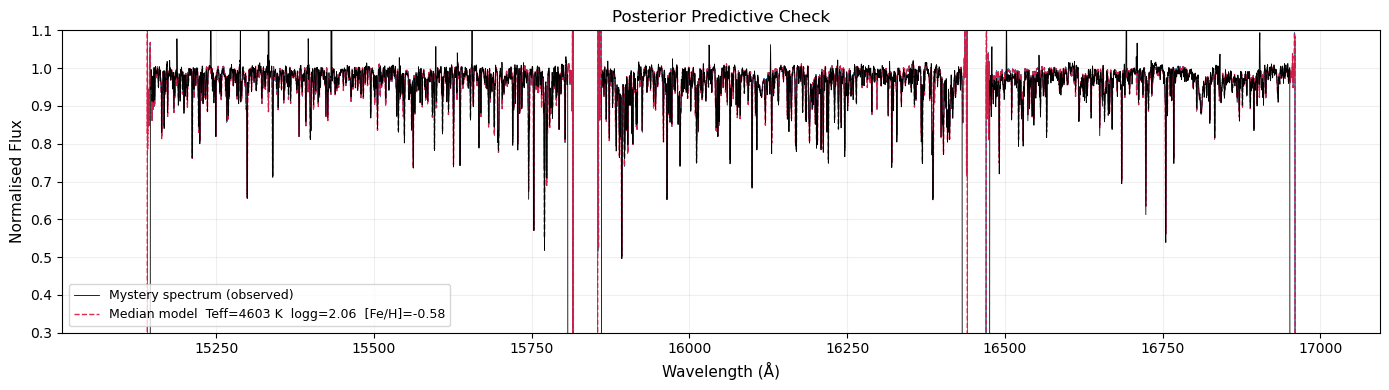

In [26]:
fig, ax = plt.subplots(figsize=(14, 4))
finite = np.isfinite(mystery_norm_flux)

ax.plot(wavelengths[finite], mystery_norm_flux[finite],
        color='black', lw=0.6, zorder=5,
        label='Mystery spectrum (observed)')

rng_ppc  = np.random.default_rng(7)
idx_draw = rng_ppc.integers(0, len(samples_arr), size=100)
for idx in idx_draw:
    f_draw = predict_spectrum(samples_arr[idx],
                              thetas, label_means, label_scales)
    ax.plot(wavelengths[finite], f_draw[finite],
            color='steelblue', lw=0.3, alpha=0.08)

f_median = predict_spectrum(medians, thetas, label_means, label_scales)
ax.plot(wavelengths[finite], f_median[finite],
        color='crimson', lw=1.0, ls='--', alpha=0.9,
        label=(f'Median model  Teff={medians[0]:.0f} K  '
               f'logg={medians[1]:.2f}  [Fe/H]={medians[2]:.2f}'))

ax.set_xlabel('Wavelength (Å)', fontsize=11)
ax.set_ylabel('Normalised Flux',  fontsize=11)
ax.set_title('Posterior Predictive Check',
             fontsize=12)
ax.set_ylim(0.3, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("mystery_ppc.png", dpi=200)
plt.show()

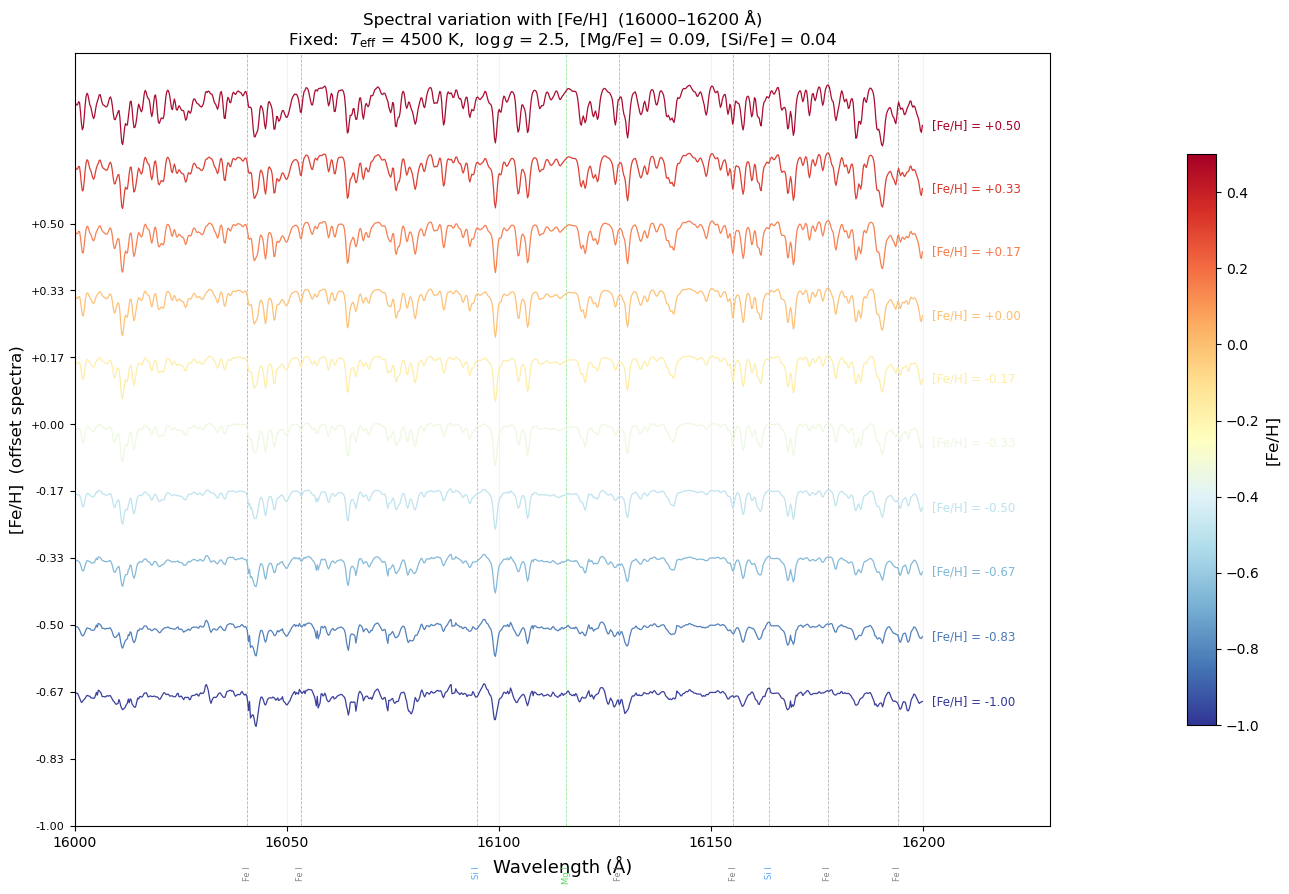

Most metallicity-sensitive pixels in 16000–16200 Angstroms
    Wavelength (Å)    Flux RMS  Nearest line
--------------------------------------------------
          16190.19      0.1041  Fe I @ 16194.02 Å
          16190.42      0.0996  Fe I @ 16194.02 Å
          16190.64      0.0966  Fe I @ 16194.02 Å
          16189.97      0.0925  Fe I @ 16194.02 Å
          16011.35      0.0889  Fe I @ 16040.66 Å

Mean flux RMS across window : 0.0289
Max  flux RMS across window : 0.1041  at 16190.19 Å


In [27]:
# Evaluating my spectral model at fixed Teff and log g while varying [Fe/H] from -1 to +0.5.
# The alpha abundances are fixed at their training-set means throughout.


# atmospheric parameters
# a typical red giant on the RGB.
TEFF_FIXED = 4500.0    # K   — mid-RGB temperature
LOGG_FIXED = 2.5       # dex — mid-RGB surface gravity
MGFE_FIXED = label_means[3]   # training-set mean [Mg/Fe]
SIFE_FIXED = label_means[4]   # training-set mean [Si/Fe]

#[Fe/H] grid 
N_FEH = 10
feh_grid = np.linspace(-1.0, 0.5, N_FEH)

# Wavelength window 
WAVE_LO, WAVE_HI = 16000, 16200
wave_mask = (wavelengths >= WAVE_LO) & (wavelengths <= WAVE_HI)
wave_window = wavelengths[wave_mask]

# Predict one spectrum per [Fe/H] value 
spectra = []
for feh in feh_grid:
    label_vec = np.array([TEFF_FIXED, LOGG_FIXED, feh,
                          MGFE_FIXED, SIFE_FIXED])
    flux_full = predict_spectrum(label_vec, thetas, label_means, label_scales)
    spectra.append(flux_full[wave_mask])

spectra = np.array(spectra)   # (N_FEH, N_window_pix)

# Vertical offset between spectra 
# Set offset so adjacent spectra just don't overlap.
# According to google the typical depth of absorption features is ~0.3 flux units, so I used an offset of 0.5 to get comfortable separation.
OFFSET = 0.5

#  Color map: blue (metal-poor) -> red (metal-rich) 
cmap_feh = plt.cm.RdYlBu_r
norm_feh  = plt.Normalize(vmin=feh_grid.min(), vmax=feh_grid.max())

# Plot 
fig, ax = plt.subplots(figsize=(13, 9))

for j, feh in enumerate(feh_grid):
    flux    = spectra[j]
    offset  = j * OFFSET
    color   = cmap_feh(norm_feh(feh))
    finite  = np.isfinite(flux)

    ax.plot(wave_window[finite], flux[finite] + offset,
            color=color, linewidth=0.9, alpha=0.95)

    # Label each spectrum on the right-hand side
    ax.text(WAVE_HI + 2, flux[finite][-1] + offset,
            f'[Fe/H] = {feh:+.2f}',
            color=color, fontsize=8.5, va='center')

# color bar
sm  = plt.cm.ScalarMappable(cmap=cmap_feh, norm=norm_feh)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.12, fraction=0.025)
cbar.set_label('[Fe/H]', fontsize=12)

# Marking known strong absorption lines 
# Fe I, Mg I, Si I, and CO lines prominent in 16000-16200 Å
# Source: APOGEE DR17 line list / Smith et al. 2013
LINE_LIST = [
    (16040.66, 'Fe I',  'dimgray'),
    (16053.27, 'Fe I',  'dimgray'),
    (16094.79, 'Si I',  'dodgerblue'),
    (16115.92, 'Mg I',  'limegreen'),
    (16128.30, 'Fe I',  'dimgray'),
    (16155.24, 'Fe I',  'dimgray'),
    (16163.67, 'Si I',  'dodgerblue'),
    (16177.54, 'Fe I',  'dimgray'),
    (16194.02, 'Fe I',  'dimgray'),
]

# Draw lines at the bottom of the plot and add species labels
y_line_top = -0.3
for wl, species, lcolor in LINE_LIST:
    if WAVE_LO <= wl <= WAVE_HI:
        ax.axvline(wl, color=lcolor, linewidth=0.6,
                   linestyle='--', alpha=0.5, zorder=0)
        ax.text(wl, y_line_top, species,
                color=lcolor, fontsize=6, ha='center',
                rotation=90, va='top', alpha=0.8)

# Axis labels and formatting 
ax.set_xlim(WAVE_LO, WAVE_HI + 30)   # extra right margin for labels
ax.set_xlabel('Wavelength (Å)', fontsize=13)
ax.set_ylabel('Normalised Flux  +  offset', fontsize=13)

ax.set_title(
    f'Spectral variation with [Fe/H]  ({WAVE_LO}–{WAVE_HI} Å)\n'
    f'Fixed:  $T_{{\\rm eff}}$ = {TEFF_FIXED:.0f} K,  '
    f'$\\log g$ = {LOGG_FIXED:.1f},  '
    f'[Mg/Fe] = {MGFE_FIXED:.2f},  [Si/Fe] = {SIFE_FIXED:.2f}',
    fontsize=12
)

# Remove y-tick labels because the offsets make them meaningless
ax.set_yticks([j * OFFSET for j in range(N_FEH)])
ax.set_yticklabels([f'{feh:+.2f}' for feh in feh_grid], fontsize=8)
ax.set_ylabel('[Fe/H]  (offset spectra)', fontsize=12)

ax.grid(True, alpha=0.15, axis='x')
plt.tight_layout()
plt.savefig("metallicity_sequence.png", dpi=300, bbox_inches='tight')
plt.show()

# Quantify the metallicity effect 
# Compute the RMS variation in flux across the [Fe/H] grid at each pixel.
# Pixels with large RMS are the most metallicity-sensitive.
flux_rms = np.std(spectra, axis=0)   # (N_window_pix,)
top5_idx = np.argsort(flux_rms)[-5:][::-1]

print("Most metallicity-sensitive pixels in 16000–16200 Angstroms")
print(f"{'Wavelength (Å)':>18}  {'Flux RMS':>10}  Nearest line")
print("-" * 50)
for idx in top5_idx:
    wl   = wave_window[idx]
    rms  = flux_rms[idx]
    # Find nearest known line
    if LINE_LIST:
        nearest = min(LINE_LIST, key=lambda x: abs(x[0] - wl))
        nearest_str = f"{nearest[1]} @ {nearest[0]:.2f} Å"
    else:
        nearest_str = "—"
    print(f"{wl:>18.2f}  {rms:>10.4f}  {nearest_str}")

print(f"\nMean flux RMS across window : {flux_rms.mean():.4f}")
print(f"Max  flux RMS across window : {flux_rms.max():.4f}  "
      f"at {wave_window[flux_rms.argmax()]:.2f} Å")

RGB locus used for part 14:
   log g     Teff (K)
  --------------------
    3.50       4989.1
    3.17       4890.6
    2.83       4766.1
    2.50       4624.9
    2.17       4594.2
    1.83       4382.5
    1.50       4138.1
    1.17       3977.5
    0.83       3757.6
    0.50       3580.0


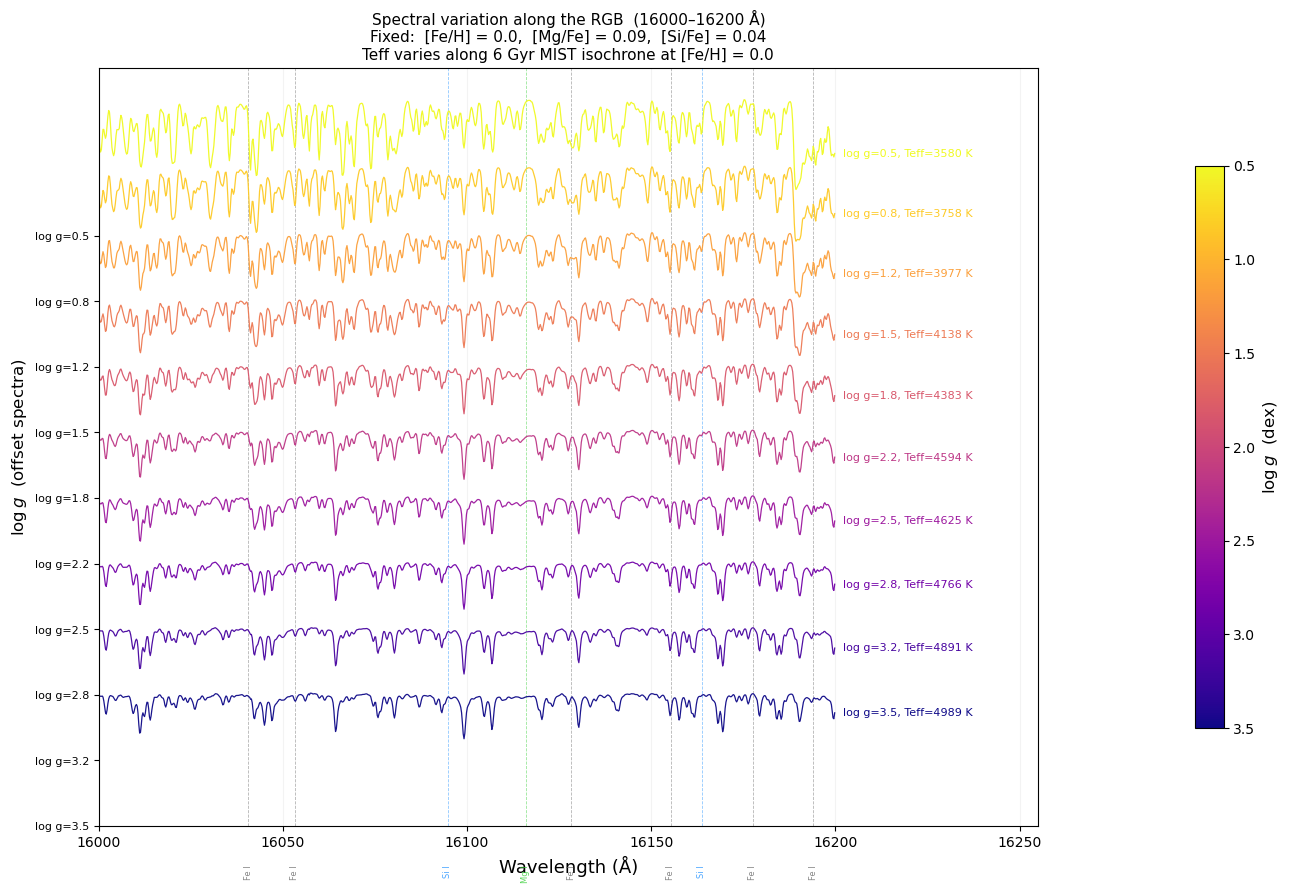

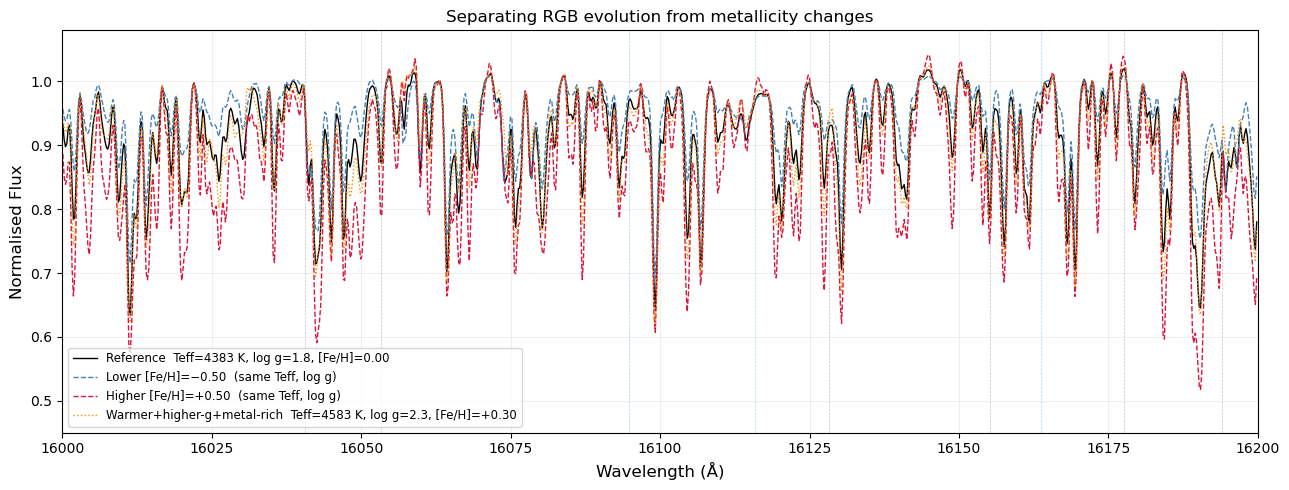

Flux variation in 16000–16200 Angstroms
  Mean RMS from [Fe/H] variation: 0.0303
  Mean RMS from RGB ascent: 0.0417
  Ratio (FeH / RGB): 0.73


In [28]:
# I varied log g from 3.5 (lower RGB) to 0.5 (RGB tip) at fixed [Fe/H]=0, simultaneously varying Teff so that the star moves along the solar-metallicity MIST isochrone.

# Extract T_eff
ISO_FEH = 0.0
LOGG_LO = 0.5    # RGB tip
LOGG_HI = 3.5    # lower RGB / subgiant boundary
N_STEPS = 10     # number of spectra to show

df_iso = isochrones.get(ISO_FEH)

if df_iso is None:
    # Falls back to a simple linear approximation if the isochrone fails to load (incorporated before I got the isochrones to work)
    # The RGB in the H-band follows roughly Teff ≈ 4900 - 430*(3.5-logg)
    print("MIST isochrone not available — using analytic RGB approximation.")
    logg_grid = np.linspace(LOGG_HI, LOGG_LO, N_STEPS)
    teff_grid = 4900.0 - 430.0 * (LOGG_HI - logg_grid)
else:
    # Filter isochrone to the giant branch in our log g range
    giant_mask = (
        (df_iso['log_g'] >= LOGG_LO - 0.1) &
        (df_iso['log_g'] <= LOGG_HI + 0.1) &
        (df_iso['Teff'] >= 3500) &
        (df_iso['Teff'] <= 5500)
    )
    df_rgb = df_iso[giant_mask].copy()

    # Sort by log g descending
    df_rgb = df_rgb.sort_values('log_g', ascending=False).reset_index(drop=True)

    if len(df_rgb) < 3:
        raise ValueError(
            "Too few isochrone points in the requested log g range. "
            "Check that the isochrone loaded correctly in part 11."
        )

    # Interpolate to get a uniform grid of N_STEPS log g values
    from scipy.interpolate import interp1d
    logg_grid = np.linspace(LOGG_HI, LOGG_LO, N_STEPS)

    # Build interpolator: log g → Teff along the RGB
    # Use the isochrone's own (log_g, Teff) relationship
    interp_teff = interp1d(
        df_rgb['log_g'].values,
        df_rgb['Teff'].values,
        kind='linear',
        bounds_error=False,
        fill_value=(df_rgb['Teff'].values[-1], df_rgb['Teff'].values[0])
    )
    teff_grid = interp_teff(logg_grid)

print("RGB locus used for part 14:")
print(f"  {'log g':>6}   {'Teff (K)':>10}")
print("  " + "-" * 20)
for lg, teff in zip(logg_grid, teff_grid):
    print(f"  {lg:>6.2f}   {teff:>10.1f}")


# Predict spectra along the RGB 
MGFE_FIXED = label_means[3]
SIFE_FIXED = label_means[4]
FEH_FIXED = 0.0

WAVE_LO, WAVE_HI = 16000, 16200
wave_mask = (wavelengths >= WAVE_LO) & (wavelengths <= WAVE_HI)
wave_window = wavelengths[wave_mask]

rgb_spectra = []
for logg, teff in zip(logg_grid, teff_grid):
    label_vec = np.array([teff, logg, FEH_FIXED, MGFE_FIXED, SIFE_FIXED])
    flux_full = predict_spectrum(label_vec, thetas, label_means, label_scales)
    rgb_spectra.append(flux_full[wave_mask])

rgb_spectra = np.array(rgb_spectra)   # (N_STEPS, N_window_pix)


# Stacked RGB Plot
OFFSET    = 0.5
cmap_rgb  = plt.cm.plasma_r
norm_logg = plt.Normalize(vmin=LOGG_LO, vmax=LOGG_HI)

fig, ax = plt.subplots(figsize=(13, 9))

for j, (logg, teff) in enumerate(zip(logg_grid, teff_grid)):
    flux   = rgb_spectra[j]
    offset = j * OFFSET
    color  = cmap_rgb(norm_logg(logg))
    finite = np.isfinite(flux)

    ax.plot(wave_window[finite], flux[finite] + offset,
            color=color, linewidth=0.9, alpha=0.95)

    ax.text(WAVE_HI + 2, flux[finite][-1] + offset,
            f'log g={logg:.1f}, Teff={teff:.0f} K',
            color=color, fontsize=8, va='center')

# Colorbar
sm   = plt.cm.ScalarMappable(cmap=cmap_rgb, norm=norm_logg)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.14, fraction=0.025)
cbar.set_label(r'$\log g$  (dex)', fontsize=12)
cbar.ax.invert_yaxis()   # low log g (tip) at top

# Absorption lines
LINE_LIST = [
    (16040.66, 'Fe I',  'dimgray'),
    (16053.27, 'Fe I',  'dimgray'),
    (16094.79, 'Si I',  'dodgerblue'),
    (16115.92, 'Mg I',  'limegreen'),
    (16128.30, 'Fe I',  'dimgray'),
    (16155.24, 'Fe I',  'dimgray'),
    (16163.67, 'Si I',  'dodgerblue'),
    (16177.54, 'Fe I',  'dimgray'),
    (16194.02, 'Fe I',  'dimgray'),
]

y_line_top = -0.3
for wl, species, lcolor in LINE_LIST:
    if WAVE_LO <= wl <= WAVE_HI:
        ax.axvline(wl, color=lcolor, linewidth=0.6,
                   linestyle='--', alpha=0.5, zorder=0)
        ax.text(wl, y_line_top, species,
                color=lcolor, fontsize=6, ha='center',
                rotation=90, va='top', alpha=0.8)

ax.set_xlim(WAVE_LO, WAVE_HI + 55)
ax.set_xlabel('Wavelength (Å)', fontsize=13)

ax.set_yticks([j * OFFSET for j in range(N_STEPS)])
ax.set_yticklabels([f'log g={lg:.1f}' for lg in logg_grid], fontsize=8)
ax.set_ylabel(r'$\log g$  (offset spectra)', fontsize=12)

ax.set_title(
    f'Spectral variation along the RGB  ({WAVE_LO}–{WAVE_HI} Å)\n'
    f'Fixed:  [Fe/H] = {FEH_FIXED:.1f},  '
    f'[Mg/Fe] = {MGFE_FIXED:.2f},  [Si/Fe] = {SIFE_FIXED:.2f}\n'
    f'Teff varies along 6 Gyr MIST isochrone at [Fe/H] = {ISO_FEH:.1f}',
    fontsize=11
)
ax.grid(True, alpha=0.15, axis='x')
plt.tight_layout()
plt.savefig("rgb_sequence.png", dpi=300, bbox_inches='tight')
plt.show()



# I picked a mid-sequence RGB spectrum (log g ~ 2.0)
mid_rgb_idx = N_STEPS // 2
logg_mid = logg_grid[mid_rgb_idx]
teff_mid = teff_grid[mid_rgb_idx]
flux_rgb_mid = rgb_spectra[mid_rgb_idx]

# For the metallicity comparison I use the same Teff/logg but vary [Fe/H]
feh_lo_vec = np.array([teff_mid, logg_mid, -0.5, MGFE_FIXED, SIFE_FIXED])
feh_hi_vec = np.array([teff_mid, logg_mid,  0.5, MGFE_FIXED, SIFE_FIXED])
flux_feh_lo = predict_spectrum(feh_lo_vec, thetas, label_means, label_scales)[wave_mask]
flux_feh_hi = predict_spectrum(feh_hi_vec, thetas, label_means, label_scales)[wave_mask]

# adding a star with different Teff/logg that is more metal-rich to illustrate degeneracy between the two effects
degen_vec = np.array([teff_mid + 200, logg_mid + 0.5,
                       0.3, MGFE_FIXED, SIFE_FIXED])
flux_degen = predict_spectrum(degen_vec, thetas, label_means, label_scales)[wave_mask]

finite = np.isfinite(flux_rgb_mid)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(wave_window[finite], flux_rgb_mid[finite],
        color='black', lw=1.0,
        label=f'Reference  Teff={teff_mid:.0f} K, log g={logg_mid:.1f}, [Fe/H]=0.00')

ax.plot(wave_window[finite], flux_feh_lo[finite],
        color='steelblue', lw=1.0, ls='--',
        label=f'Lower [Fe/H]=−0.50  (same Teff, log g)')

ax.plot(wave_window[finite], flux_feh_hi[finite],
        color='crimson', lw=1.0, ls='--',
        label=f'Higher [Fe/H]=+0.50  (same Teff, log g)')

ax.plot(wave_window[finite], flux_degen[finite],
        color='darkorange', lw=1.0, ls=':',
        label=(f'Warmer+higher-g+metal-rich  '
               f'Teff={teff_mid+200:.0f} K, '
               f'log g={logg_mid+0.5:.1f}, [Fe/H]=+0.30'))

for wl, species, lcolor in LINE_LIST:
    if WAVE_LO <= wl <= WAVE_HI:
        ax.axvline(wl, color=lcolor, lw=0.5, ls='--', alpha=0.4)

ax.set_xlim(WAVE_LO, WAVE_HI)
ax.set_ylim(0.45, 1.08)
ax.set_xlabel('Wavelength (Å)', fontsize=12)
ax.set_ylabel('Normalised Flux',  fontsize=12)
ax.set_title('Separating RGB evolution from metallicity changes',
             fontsize=12)
ax.legend(fontsize=8.5, loc='lower left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("rgb_vs_metallicity_comparison.png", dpi=300)
plt.show()


# comparison
feh_rms  = np.std(
    np.array([
        predict_spectrum(
            np.array([teff_mid, logg_mid, feh, MGFE_FIXED, SIFE_FIXED]),
            thetas, label_means, label_scales
        )[wave_mask]
        for feh in np.linspace(-1.0, 0.5, 10)
    ]),
    axis=0
)

rgb_rms = np.std(rgb_spectra, axis=0)

print("Flux variation in 16000–16200 Angstroms")
print(f"  Mean RMS from [Fe/H] variation: {feh_rms.mean():.4f}")
print(f"  Mean RMS from RGB ascent: {rgb_rms.mean():.4f}")
print(f"  Ratio (FeH / RGB): "
      f"{feh_rms.mean() / rgb_rms.mean():.2f}")


### Binary Star Discussion

For binary systems with small angular separation, the observed flux of the star is greater than what is really the case. This is because flux is an additive quantity, so what you are really seeing is the flux from two stars that appears to originate from the same point. This can affect the label generation and association of the model. For example, a greater flux implies a greater T_eff. This is an issue because this now implies that the star is of lower metallicity, changing the expected magnitude of the absorption lines. This throws off the models label generation, associating greater Brightness temperatures with false absorption lines. 

A fix for this would be to filter out stars that have a binary system flag in APOGEE. I could also add a check that compares expected/theoretical flux -> absorption lines to the ones in my data set. 

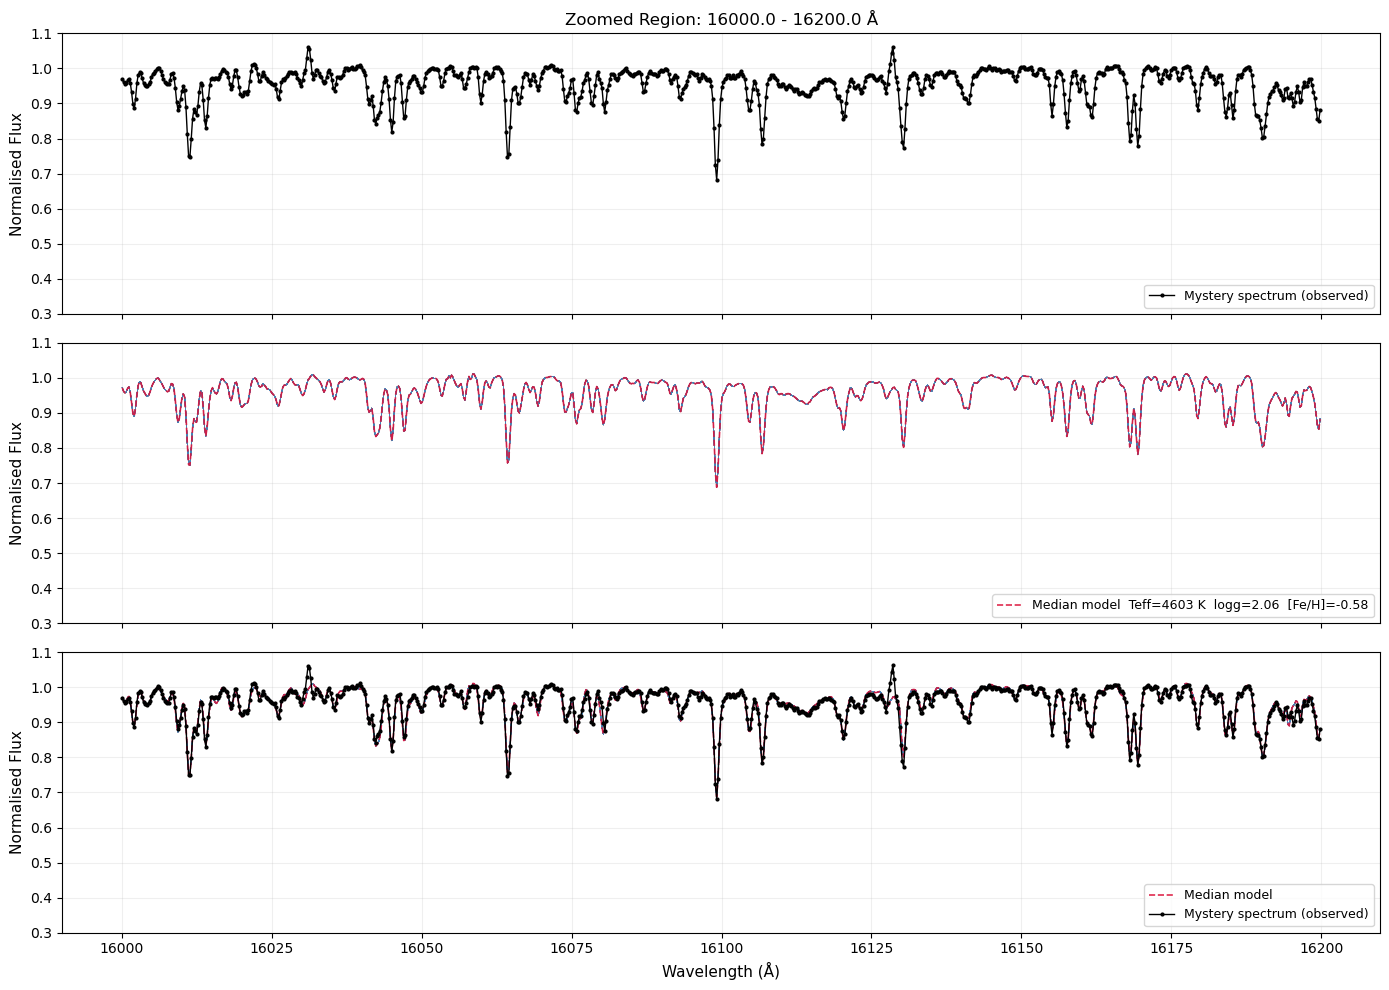

In [29]:
# Set bounds for the focused wavelength region
zoom_wave_min = 16000.0
zoom_wave_max = 16200.0

# Generate a boolean mask to filter for valid pixels within the specified bounds
zoom_mask = (wavelengths >= zoom_wave_min) & (wavelengths <= zoom_wave_max) & np.isfinite(mystery_norm_flux)

# Instantiate a 3-row figure with shared x-axes and increased height for visual clarity
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

# Extract the filtered wavelength and flux data
wave_zoomed = wavelengths[zoom_mask]
flux_zoomed = mystery_norm_flux[zoom_mask]

axes[0].plot(wave_zoomed, flux_zoomed,
             color='black', lw=1.0, marker='.', ms=4,
             label='Mystery spectrum (observed)')

axes[0].set_title(f'Zoomed Region: {zoom_wave_min} - {zoom_wave_max} Å', fontsize=12)
axes[0].set_ylabel('Normalised Flux', fontsize=11)
axes[0].set_ylim(0.3, 1.1)
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.2)


# Initialize a random number generator and select 100 sample indices
rng_ppc = np.random.default_rng(7)
idx_draw = rng_ppc.integers(0, len(samples_arr), size=100)

# Calculate the model prediction for the median MCMC parameters
f_median = predict_spectrum(medians, thetas, label_means, label_scales)


for idx in idx_draw:
    f_draw = predict_spectrum(samples_arr[idx], thetas, label_means, label_scales)
    
    # Plot on middle panel (Model Only)
    axes[1].plot(wave_zoomed, f_draw[zoom_mask], color='steelblue', lw=0.5, alpha=0.15)
    
    # Plot on bottom panel (Overlay)
    axes[2].plot(wave_zoomed, f_draw[zoom_mask], color='steelblue', lw=0.5, alpha=0.15)

# Plot the median model to the middle panel
axes[1].plot(wave_zoomed, f_median[zoom_mask],
             color='crimson', lw=1.2, ls='--', alpha=0.9,
             label=(f'Median model  Teff={medians[0]:.0f} K  '
                    f'logg={medians[1]:.2f}  [Fe/H]={medians[2]:.2f}'))

# Plot the median model to the bottom panel
axes[2].plot(wave_zoomed, f_median[zoom_mask],
             color='crimson', lw=1.2, ls='--', alpha=0.9,
             label='Median model')

axes[1].set_ylabel('Normalised Flux', fontsize=11)
axes[1].set_ylim(0.3, 1.1)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.2)


# Plot the original observed data on top of the generated models
axes[2].plot(wave_zoomed, flux_zoomed,
             color='black', lw=1.0, marker='.', ms=4, zorder=5,
             label='Mystery spectrum (observed)')

axes[2].set_xlabel('Wavelength (Å)', fontsize=11)
axes[2].set_ylabel('Normalised Flux', fontsize=11)
axes[2].set_ylim(0.3, 1.1)
axes[2].legend(fontsize=9, loc='lower right')
axes[2].grid(True, alpha=0.2)

# Adjust layout to prevent overlapping labels and save the output
plt.tight_layout()
plt.savefig("mystery_zoomed_comparison_3panel.png", dpi=200)
plt.show()